In [14]:
# =============================================================================
# CELL 1 — FINAL MULTIMODAL SIAMESE MODEL CONFIGURATION
# =============================================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------------------------------------------------------
# Project paths
# -------------------------------------------------------------------------

PROJECT_ROOT = r"D:\ISRO"

# -------------------------------------------------------------------------
# Frozen preprocessing / embedding outputs
# -------------------------------------------------------------------------

IIRS_DIR = os.path.join(
    PROJECT_ROOT,
    "IIRS_tiles"
)

OHRC_DIR = os.path.join(
    PROJECT_ROOT,
    "OHRC_tiles"
)

TMC2_DIR = os.path.join(
    PROJECT_ROOT,
    "TMC_tiles"
)

# -------------------------------------------------------------------------
# Correspondence model outputs
# -------------------------------------------------------------------------

IIRS_CORRESPONDENCE_DIR = os.path.join(
    PROJECT_ROOT,
    "IIRS_TMC2_correspondence"
)

OHRC_CORRESPONDENCE_DIR = os.path.join(
    PROJECT_ROOT,
    "OHRC_TMC2_correspondence"
)

# -------------------------------------------------------------------------
# Final model output directories
# -------------------------------------------------------------------------

FINAL_ROOT = os.path.join(
    PROJECT_ROOT,
    "Integrated_Multimodal_Siamese"
)

MODELS_DIR = os.path.join(
    FINAL_ROOT,
    "models"
)

EVALUATION_DIR = os.path.join(
    FINAL_ROOT,
    "evaluation"
)

PAIRS_DIR = os.path.join(
    FINAL_ROOT,
    "pairs"
)

EMBEDDINGS_DIR = os.path.join(
    FINAL_ROOT,
    "embeddings"
)

PREDICTIONS_DIR = os.path.join(
    FINAL_ROOT,
    "predictions"
)

for directory in [
    FINAL_ROOT,
    MODELS_DIR,
    EVALUATION_DIR,
    PAIRS_DIR,
    EMBEDDINGS_DIR,
    PREDICTIONS_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )

# -------------------------------------------------------------------------
# Existing real embedding files
# -------------------------------------------------------------------------

IIRS_EMBEDDINGS_PATH = os.path.join(
    IIRS_CORRESPONDENCE_DIR,
    "iirs_embeddings_256.npy"
)

IIRS_METADATA_PATH = os.path.join(
    IIRS_CORRESPONDENCE_DIR,
    "iirs_embeddings_metadata.csv"
)

OHRC_EMBEDDINGS_PATH = os.path.join(
    OHRC_CORRESPONDENCE_DIR,
    "ohrc_embeddings_256.npy"
)

OHRC_METADATA_PATH = os.path.join(
    OHRC_DIR,
    "ohrc_manifest.csv"
)

TMC2_EMBEDDINGS_PATH = os.path.join(
    TMC2_DIR,
    "mvp_embeddings.npz"
)

TMC2_METADATA_PATH = os.path.join(
    TMC2_DIR,
    "mvp_embeddings_manifest.csv"
)

# -------------------------------------------------------------------------
# Trained correspondence mapper checkpoints
# -------------------------------------------------------------------------

IIRS_MAPPER_PATH = os.path.join(
    IIRS_CORRESPONDENCE_DIR,
    "models",
    "iirs_tmc2_fixed_transform_mapper_best.pt"
)

OHRC_MAPPER_PATH = os.path.join(
    OHRC_CORRESPONDENCE_DIR,
    "models",
    "ohrc_tmc2_fixed_transform_mapper_best.pt"
)

# -------------------------------------------------------------------------
# Embedding configuration
# -------------------------------------------------------------------------

EMBED_DIM = 256

IIRS_MODALITY = "IIRS"
OHRC_MODALITY = "OHRC"
TMC2_MODALITY = "TMC-2"

MODALITIES = [
    IIRS_MODALITY,
    OHRC_MODALITY,
    TMC2_MODALITY
]

# -------------------------------------------------------------------------
# Final Siamese / shared-space configuration
# -------------------------------------------------------------------------

SHARED_DIM = 256

TEMPERATURE = 0.07

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-5

MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 15

# -------------------------------------------------------------------------
# Device
# -------------------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# -------------------------------------------------------------------------
# Display configuration
# -------------------------------------------------------------------------

print("=" * 80)
print("FINAL MULTIMODAL SIAMESE MODEL")
print("=" * 80)

print()
print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {DEVICE}")

print()
print("Modalities:")
print(
    f"  1. {IIRS_MODALITY}"
)

print(
    f"  2. {OHRC_MODALITY}"
)

print(
    f"  3. {TMC2_MODALITY}"
)

print()
print("Embedding dimension:")
print(
    f"  Input embedding : {EMBED_DIM}"
)

print(
    f"  Shared space    : {SHARED_DIM}"
)

print()
print("Training:")
print(
    f"  Batch size      : {BATCH_SIZE}"
)

print(
    f"  Learning rate   : {LEARNING_RATE}"
)

print(
    f"  Max epochs      : {MAX_EPOCHS}"
)

print(
    f"  Temperature     : {TEMPERATURE}"
)

print()
print("Frozen components:")
print(
    "  IIRS preprocessing + encoder"
)

print(
    "  OHRC preprocessing + encoder"
)

print(
    "  TMC-2 preprocessing + encoder"
)

print(
    "  IIRS → TMC-2 mapper"
)

print(
    "  OHRC → TMC-2 mapper"
)

print()
print("Trainable component:")
print(
    "  Final multimodal shared-space / Siamese network"
)

# -------------------------------------------------------------------------
# Verify required artifacts
# -------------------------------------------------------------------------

required_files = {

    "IIRS embeddings":
        IIRS_EMBEDDINGS_PATH,

    "IIRS metadata":
        IIRS_METADATA_PATH,

    "OHRC embeddings":
        OHRC_EMBEDDINGS_PATH,

    "OHRC metadata":
        OHRC_METADATA_PATH,

    "TMC-2 embeddings":
        TMC2_EMBEDDINGS_PATH,

    "TMC-2 metadata":
        TMC2_METADATA_PATH,

    "IIRS mapper":
        IIRS_MAPPER_PATH,

    "OHRC mapper":
        OHRC_MAPPER_PATH
}

print()
print("=" * 80)
print("ARTIFACT CHECK")
print("=" * 80)

for name, path in required_files.items():

    exists = os.path.exists(path)

    status = "[OK]" if exists else "[MISSING]"

    print(
        f"{status} {name}: {path}"
    )

    assert exists, (
        f"Required artifact missing: {path}"
    )

print()
print("=" * 80)
print("CELL 1 COMPLETE")
print("=" * 80)

FINAL MULTIMODAL SIAMESE MODEL

Project root : D:\ISRO
Device       : cpu

Modalities:
  1. IIRS
  2. OHRC
  3. TMC-2

Embedding dimension:
  Input embedding : 256
  Shared space    : 256

Training:
  Batch size      : 32
  Learning rate   : 0.0001
  Max epochs      : 100
  Temperature     : 0.07

Frozen components:
  IIRS preprocessing + encoder
  OHRC preprocessing + encoder
  TMC-2 preprocessing + encoder
  IIRS → TMC-2 mapper
  OHRC → TMC-2 mapper

Trainable component:
  Final multimodal shared-space / Siamese network

ARTIFACT CHECK
[OK] IIRS embeddings: D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_256.npy
[OK] IIRS metadata: D:\ISRO\IIRS_TMC2_correspondence\iirs_embeddings_metadata.csv
[OK] OHRC embeddings: D:\ISRO\OHRC_TMC2_correspondence\ohrc_embeddings_256.npy
[OK] OHRC metadata: D:\ISRO\OHRC_tiles\ohrc_manifest.csv
[OK] TMC-2 embeddings: D:\ISRO\TMC_tiles\mvp_embeddings.npz
[OK] TMC-2 metadata: D:\ISRO\TMC_tiles\mvp_embeddings_manifest.csv
[OK] IIRS mapper: D:\ISRO\IIRS_T

In [15]:
# =============================================================================
# CELL 2 — LOAD AND VALIDATE ALL THREE MODALITY EMBEDDINGS
# =============================================================================

print("=" * 80)
print("LOADING REAL MULTIMODAL EMBEDDINGS")
print("=" * 80)

# -------------------------------------------------------------------------
# IIRS
# -------------------------------------------------------------------------

IIRS_EMBEDDINGS = np.load(
    IIRS_EMBEDDINGS_PATH
).astype(np.float32)

IIRS_METADATA = pd.read_csv(
    IIRS_METADATA_PATH
)

# -------------------------------------------------------------------------
# OHRC
# -------------------------------------------------------------------------

OHRC_EMBEDDINGS = np.load(
    OHRC_EMBEDDINGS_PATH
).astype(np.float32)

OHRC_METADATA = pd.read_csv(
    OHRC_METADATA_PATH
)

# -------------------------------------------------------------------------
# TMC-2
# -------------------------------------------------------------------------
# The TMC-2 NPZ contains string/object patch IDs, so allow_pickle=True
# is required when reading this locally generated artifact.
# -------------------------------------------------------------------------

TMC2_DATA = np.load(
    TMC2_EMBEDDINGS_PATH,
    allow_pickle=True
)

TMC2_EMBEDDINGS = TMC2_DATA[
    "embeddings"
].astype(np.float32)

TMC2_PATCH_IDS = TMC2_DATA[
    "patch_id"
]

TMC2_METADATA = pd.read_csv(
    TMC2_METADATA_PATH
)

# -------------------------------------------------------------------------
# Shape checks
# -------------------------------------------------------------------------

print()
print("Embedding shapes:")

print(
    f"  IIRS  : {IIRS_EMBEDDINGS.shape}"
)

print(
    f"  OHRC  : {OHRC_EMBEDDINGS.shape}"
)

print(
    f"  TMC-2 : {TMC2_EMBEDDINGS.shape}"
)

assert IIRS_EMBEDDINGS.ndim == 2
assert OHRC_EMBEDDINGS.ndim == 2
assert TMC2_EMBEDDINGS.ndim == 2

assert IIRS_EMBEDDINGS.shape[1] == EMBED_DIM
assert OHRC_EMBEDDINGS.shape[1] == EMBED_DIM
assert TMC2_EMBEDDINGS.shape[1] == EMBED_DIM

assert len(IIRS_EMBEDDINGS) == len(IIRS_METADATA)
assert len(OHRC_EMBEDDINGS) == len(OHRC_METADATA)
assert len(TMC2_EMBEDDINGS) == len(TMC2_METADATA)

print()
print("[OK] All embedding dimensions are 256-D.")
print("[OK] Embedding/metadata row counts agree.")

# -------------------------------------------------------------------------
# Finite-value checks
# -------------------------------------------------------------------------

assert np.isfinite(
    IIRS_EMBEDDINGS
).all()

assert np.isfinite(
    OHRC_EMBEDDINGS
).all()

assert np.isfinite(
    TMC2_EMBEDDINGS
).all()

print(
    "[OK] All embeddings contain finite values."
)

# -------------------------------------------------------------------------
# Basic statistics
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("EMBEDDING STATISTICS")
print("=" * 80)

for name, embeddings in [
    ("IIRS", IIRS_EMBEDDINGS),
    ("OHRC", OHRC_EMBEDDINGS),
    ("TMC-2", TMC2_EMBEDDINGS)
]:

    norms = np.linalg.norm(
        embeddings,
        axis=1
    )

    print()
    print(name)

    print(
        f"  Samples   : {len(embeddings)}"
    )

    print(
        f"  Mean      : {embeddings.mean():.6f}"
    )

    print(
        f"  Std       : {embeddings.std():.6f}"
    )

    print(
        f"  Min       : {embeddings.min():.6f}"
    )

    print(
        f"  Max       : {embeddings.max():.6f}"
    )

    print(
        f"  Norm mean : {norms.mean():.6f}"
    )

    print(
        f"  Norm std  : {norms.std():.6f}"
    )

# -------------------------------------------------------------------------
# Metadata checks
# -------------------------------------------------------------------------

print()
print("=" * 80)
print("METADATA CHECK")
print("=" * 80)

print()
print(
    f"IIRS metadata columns : "
    f"{len(IIRS_METADATA.columns)}"
)

print(
    f"OHRC metadata columns : "
    f"{len(OHRC_METADATA.columns)}"
)

print(
    f"TMC-2 metadata columns: "
    f"{len(TMC2_METADATA.columns)}"
)

# -------------------------------------------------------------------------
# TMC-2 patch ID checks
# -------------------------------------------------------------------------

assert len(TMC2_PATCH_IDS) == len(
    TMC2_METADATA
)

assert TMC2_METADATA[
    "patch_id"
].is_unique

print()
print(
    "[OK] TMC-2 patch IDs are unique."
)

# -------------------------------------------------------------------------
# Dataset summary
# -------------------------------------------------------------------------

summary_df = pd.DataFrame({

    "Modality": [
        "IIRS",
        "OHRC",
        "TMC-2"
    ],

    "Samples": [
        len(IIRS_EMBEDDINGS),
        len(OHRC_EMBEDDINGS),
        len(TMC2_EMBEDDINGS)
    ],

    "Embedding_Dim": [
        IIRS_EMBEDDINGS.shape[1],
        OHRC_EMBEDDINGS.shape[1],
        TMC2_EMBEDDINGS.shape[1]
    ],

    "Metadata_Rows": [
        len(IIRS_METADATA),
        len(OHRC_METADATA),
        len(TMC2_METADATA)
    ]
})

print()
display(
    summary_df
)

print()
print("=" * 80)
print("CELL 2 COMPLETE")
print("=" * 80)

LOADING REAL MULTIMODAL EMBEDDINGS

Embedding shapes:
  IIRS  : (47, 256)
  OHRC  : (900, 256)
  TMC-2 : (400, 256)

[OK] All embedding dimensions are 256-D.
[OK] Embedding/metadata row counts agree.
[OK] All embeddings contain finite values.

EMBEDDING STATISTICS

IIRS
  Samples   : 47
  Mean      : 0.016185
  Std       : 0.446737
  Min       : -1.553186
  Max       : 1.505009
  Norm mean : 7.137317
  Norm std  : 0.465416

OHRC
  Samples   : 900
  Mean      : -0.020756
  Std       : 0.499188
  Min       : -2.122902
  Max       : 1.872703
  Norm mean : 7.945365
  Norm std  : 0.879572

TMC-2
  Samples   : 400
  Mean      : 0.013383
  Std       : 0.881346
  Min       : -3.340472
  Max       : 3.755360
  Norm mean : 14.012197
  Norm std  : 1.599223

METADATA CHECK

IIRS metadata columns : 18
OHRC metadata columns : 23
TMC-2 metadata columns: 49

[OK] TMC-2 patch IDs are unique.



,Modality,Samples,Embedding_Dim,Metadata_Rows
0,IIRS,47,256,47
1,OHRC,900,256,900
2,TMC-2,400,256,400



CELL 2 COMPLETE


In [16]:
# =============================================================================
# CELL 3 — LOAD AND VALIDATE CORRESPONDENCE MAPPERS
# =============================================================================

print("=" * 80)
print("LOADING CORRESPONDENCE MAPPERS")
print("=" * 80)


# -----------------------------------------------------------------------------
# Mapper architecture
# -----------------------------------------------------------------------------

class CorrespondenceMapper(nn.Module):

    def __init__(self, embed_dim=256):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                embed_dim,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                512
            ),

            nn.LayerNorm(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.05
            ),

            nn.Linear(
                512,
                embed_dim
            )
        )

    def forward(self, x):

        return self.network(x)


# -----------------------------------------------------------------------------
# Load IIRS checkpoint
# -----------------------------------------------------------------------------

IIRS_CHECKPOINT = torch.load(
    IIRS_MAPPER_PATH,
    map_location=DEVICE,
    weights_only=False
)

assert isinstance(
    IIRS_CHECKPOINT,
    dict
)

assert "model_state_dict" in IIRS_CHECKPOINT

IIRS_MAPPER = CorrespondenceMapper(
    EMBED_DIM
).to(DEVICE)

IIRS_MAPPER.load_state_dict(
    IIRS_CHECKPOINT["model_state_dict"]
)

IIRS_MAPPER.eval()


# -----------------------------------------------------------------------------
# Load OHRC checkpoint
# -----------------------------------------------------------------------------

OHRC_CHECKPOINT = torch.load(
    OHRC_MAPPER_PATH,
    map_location=DEVICE,
    weights_only=False
)

assert isinstance(
    OHRC_CHECKPOINT,
    dict
)

assert "model_state_dict" in OHRC_CHECKPOINT

OHRC_MAPPER = CorrespondenceMapper(
    EMBED_DIM
).to(DEVICE)

OHRC_MAPPER.load_state_dict(
    OHRC_CHECKPOINT["model_state_dict"]
)

OHRC_MAPPER.eval()


# -----------------------------------------------------------------------------
# Load the ACTUAL normalization statistics saved by each mapper
# -----------------------------------------------------------------------------

# IIRS checkpoint uses input_mean / input_std
assert "input_mean" in IIRS_CHECKPOINT
assert "input_std" in IIRS_CHECKPOINT

IIRS_INPUT_MEAN = np.asarray(
    IIRS_CHECKPOINT["input_mean"],
    dtype=np.float32
).reshape(1, EMBED_DIM)

IIRS_INPUT_STD = np.asarray(
    IIRS_CHECKPOINT["input_std"],
    dtype=np.float32
).reshape(1, EMBED_DIM)

# OHRC checkpoint uses x_mean / x_std
assert "x_mean" in OHRC_CHECKPOINT
assert "x_std" in OHRC_CHECKPOINT

OHRC_INPUT_MEAN = np.asarray(
    OHRC_CHECKPOINT["x_mean"],
    dtype=np.float32
).reshape(1, EMBED_DIM)

OHRC_INPUT_STD = np.asarray(
    OHRC_CHECKPOINT["x_std"],
    dtype=np.float32
).reshape(1, EMBED_DIM)

# Avoid division by zero
IIRS_INPUT_STD = np.maximum(
    IIRS_INPUT_STD,
    1e-6
)

OHRC_INPUT_STD = np.maximum(
    OHRC_INPUT_STD,
    1e-6
)


# -----------------------------------------------------------------------------
# Validate normalization shapes
# -----------------------------------------------------------------------------

assert IIRS_INPUT_MEAN.shape == (1, EMBED_DIM)
assert IIRS_INPUT_STD.shape == (1, EMBED_DIM)

assert OHRC_INPUT_MEAN.shape == (1, EMBED_DIM)
assert OHRC_INPUT_STD.shape == (1, EMBED_DIM)


# -----------------------------------------------------------------------------
# Parameter counts
# -----------------------------------------------------------------------------

IIRS_PARAMS = sum(
    p.numel()
    for p in IIRS_MAPPER.parameters()
)

OHRC_PARAMS = sum(
    p.numel()
    for p in OHRC_MAPPER.parameters()
)

assert IIRS_PARAMS == 527616
assert OHRC_PARAMS == 527616


# -----------------------------------------------------------------------------
# Quick inference sanity check
# -----------------------------------------------------------------------------

with torch.no_grad():

    iirs_test_input = torch.from_numpy(
        (
            IIRS_EMBEDDINGS[:2]
            - IIRS_INPUT_MEAN
        )
        / IIRS_INPUT_STD
    ).float().to(DEVICE)

    ohrc_test_input = torch.from_numpy(
        (
            OHRC_EMBEDDINGS[:2]
            - OHRC_INPUT_MEAN
        )
        / OHRC_INPUT_STD
    ).float().to(DEVICE)

    iirs_test_output = IIRS_MAPPER(
        iirs_test_input
    ).cpu().numpy()

    ohrc_test_output = OHRC_MAPPER(
        ohrc_test_input
    ).cpu().numpy()


# -----------------------------------------------------------------------------
# Output validation
# -----------------------------------------------------------------------------

assert iirs_test_output.shape == (
    2,
    EMBED_DIM
)

assert ohrc_test_output.shape == (
    2,
    EMBED_DIM
)

assert np.isfinite(
    iirs_test_output
).all()

assert np.isfinite(
    ohrc_test_output
).all()


# -----------------------------------------------------------------------------
# Report
# -----------------------------------------------------------------------------

print()
print("[OK] IIRS → TMC-2 mapper loaded.")
print("[OK] OHRC → TMC-2 mapper loaded.")

print()
print("IIRS → TMC-2")
print(
    f"  Epoch            : {IIRS_CHECKPOINT['epoch']}"
)
print(
    f"  Validation loss  : {IIRS_CHECKPOINT['val_loss']:.6f}"
)
print(
    f"  Architecture     : {IIRS_CHECKPOINT['embed_dim']}"
    f"-{IIRS_CHECKPOINT['hidden_dim']}"
    f"-{IIRS_CHECKPOINT['hidden_dim']}"
    f"-{IIRS_CHECKPOINT['embed_dim']}"
)
print(
    "  Normalization    : input_mean / input_std"
)

print()
print("OHRC → TMC-2")
print(
    f"  Epoch            : {OHRC_CHECKPOINT['epoch']}"
)
print(
    f"  Validation loss  : {OHRC_CHECKPOINT['val_loss']:.6f}"
)
print(
    f"  Architecture     : "
    f"{OHRC_CHECKPOINT['input_dim']}"
    f"-512-512-"
    f"{OHRC_CHECKPOINT['output_dim']}"
)
print(
    "  Normalization    : x_mean / x_std"
)

print()
print(
    f"IIRS mapper parameters : {IIRS_PARAMS:,}"
)

print(
    f"OHRC mapper parameters : {OHRC_PARAMS:,}"
)

print()
print(
    "[OK] Both mappers contain 527,616 parameters."
)

print(
    "[OK] IIRS mapper normalization loaded."
)

print(
    "[OK] OHRC mapper normalization loaded."
)

print(
    "[OK] IIRS mapper inference produces finite 256-D output."
)

print(
    "[OK] OHRC mapper inference produces finite 256-D output."
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "IIRS encoder + preprocessing       : FROZEN"
)

print(
    "OHRC encoder + preprocessing       : FROZEN"
)

print(
    "TMC-2 encoder + preprocessing      : FROZEN"
)

print(
    "IIRS → TMC-2 correspondence mapper : FROZEN"
)

print(
    "OHRC → TMC-2 correspondence mapper : FROZEN"
)

print(
    "Final multimodal shared-space model: NOT TRAINED"
)

print()
print("=" * 80)
print("CELL 3 COMPLETE")
print("=" * 80)

LOADING CORRESPONDENCE MAPPERS

[OK] IIRS → TMC-2 mapper loaded.
[OK] OHRC → TMC-2 mapper loaded.

IIRS → TMC-2
  Epoch            : 99
  Validation loss  : 0.323925
  Architecture     : 256-512-512-256
  Normalization    : input_mean / input_std

OHRC → TMC-2
  Epoch            : 96
  Validation loss  : 0.273775
  Architecture     : 256-512-512-256
  Normalization    : x_mean / x_std

IIRS mapper parameters : 527,616
OHRC mapper parameters : 527,616

[OK] Both mappers contain 527,616 parameters.
[OK] IIRS mapper normalization loaded.
[OK] OHRC mapper normalization loaded.
[OK] IIRS mapper inference produces finite 256-D output.
[OK] OHRC mapper inference produces finite 256-D output.

METHODOLOGICAL STATUS
IIRS encoder + preprocessing       : FROZEN
OHRC encoder + preprocessing       : FROZEN
TMC-2 encoder + preprocessing      : FROZEN
IIRS → TMC-2 correspondence mapper : FROZEN
OHRC → TMC-2 correspondence mapper : FROZEN
Final multimodal shared-space model: NOT TRAINED

CELL 3 COMPLE

In [17]:
# =============================================================================
# CELL 4 — GENERATE COMMON-SPACE EMBEDDINGS
# =============================================================================

print("=" * 80)
print("GENERATING COMMON-SPACE EMBEDDINGS")
print("=" * 80)


# -----------------------------------------------------------------------------
# Helper: apply a frozen correspondence mapper
# -----------------------------------------------------------------------------

def map_to_tmc2_space(
    embeddings,
    mapper,
    input_mean,
    input_std
):
    
    normalized = (
        embeddings
        - input_mean
    ) / input_std

    tensor = torch.from_numpy(
        normalized.astype(np.float32)
    ).to(DEVICE)

    with torch.no_grad():

        mapped = mapper(
            tensor
        ).cpu().numpy()

    return mapped.astype(np.float32)


# -----------------------------------------------------------------------------
# IIRS → TMC-2 common space
# -----------------------------------------------------------------------------

IIRS_COMMON = map_to_tmc2_space(
    IIRS_EMBEDDINGS,
    IIRS_MAPPER,
    IIRS_INPUT_MEAN,
    IIRS_INPUT_STD
)


# -----------------------------------------------------------------------------
# OHRC → TMC-2 common space
# -----------------------------------------------------------------------------

OHRC_COMMON = map_to_tmc2_space(
    OHRC_EMBEDDINGS,
    OHRC_MAPPER,
    OHRC_INPUT_MEAN,
    OHRC_INPUT_STD
)


# -----------------------------------------------------------------------------
# TMC-2 is already the reference space
# -----------------------------------------------------------------------------

TMC2_COMMON = TMC2_EMBEDDINGS.copy()


# -----------------------------------------------------------------------------
# Validate shapes
# -----------------------------------------------------------------------------

assert IIRS_COMMON.shape == (
    len(IIRS_EMBEDDINGS),
    EMBED_DIM
)

assert OHRC_COMMON.shape == (
    len(OHRC_EMBEDDINGS),
    EMBED_DIM
)

assert TMC2_COMMON.shape == (
    len(TMC2_EMBEDDINGS),
    EMBED_DIM
)


# -----------------------------------------------------------------------------
# Validate finite values
# -----------------------------------------------------------------------------

assert np.isfinite(
    IIRS_COMMON
).all()

assert np.isfinite(
    OHRC_COMMON
).all()

assert np.isfinite(
    TMC2_COMMON
).all()


# -----------------------------------------------------------------------------
# Statistics
# -----------------------------------------------------------------------------

print()
print("Common-space embedding shapes:")

print(
    f"  IIRS  → TMC-2 space : {IIRS_COMMON.shape}"
)

print(
    f"  OHRC  → TMC-2 space : {OHRC_COMMON.shape}"
)

print(
    f"  TMC-2 reference     : {TMC2_COMMON.shape}"
)


print()
print("=" * 80)
print("COMMON-SPACE STATISTICS")
print("=" * 80)


for name, embeddings in [
    ("IIRS → TMC-2", IIRS_COMMON),
    ("OHRC → TMC-2", OHRC_COMMON),
    ("TMC-2", TMC2_COMMON)
]:

    norms = np.linalg.norm(
        embeddings,
        axis=1
    )

    print()
    print(name)

    print(
        f"  Samples   : {len(embeddings)}"
    )

    print(
        f"  Mean      : {embeddings.mean():.6f}"
    )

    print(
        f"  Std       : {embeddings.std():.6f}"
    )

    print(
        f"  Min       : {embeddings.min():.6f}"
    )

    print(
        f"  Max       : {embeddings.max():.6f}"
    )

    print(
        f"  Norm mean : {norms.mean():.6f}"
    )

    print(
        f"  Norm std  : {norms.std():.6f}"
    )


# -----------------------------------------------------------------------------
# Save common-space embeddings
# -----------------------------------------------------------------------------

IIRS_COMMON_PATH = os.path.join(
    EMBEDDINGS_DIR,
    "iirs_common_space_256.npy"
)

OHRC_COMMON_PATH = os.path.join(
    EMBEDDINGS_DIR,
    "ohrc_common_space_256.npy"
)

TMC2_COMMON_PATH = os.path.join(
    EMBEDDINGS_DIR,
    "tmc2_common_space_256.npy"
)


np.save(
    IIRS_COMMON_PATH,
    IIRS_COMMON
)

np.save(
    OHRC_COMMON_PATH,
    OHRC_COMMON
)

np.save(
    TMC2_COMMON_PATH,
    TMC2_COMMON
)


# -----------------------------------------------------------------------------
# Check saved artifacts
# -----------------------------------------------------------------------------

assert os.path.exists(
    IIRS_COMMON_PATH
)

assert os.path.exists(
    OHRC_COMMON_PATH
)

assert os.path.exists(
    TMC2_COMMON_PATH
)


print()
print("[OK] IIRS common-space embeddings saved.")
print("[OK] OHRC common-space embeddings saved.")
print("[OK] TMC-2 reference embeddings saved.")


# -----------------------------------------------------------------------------
# Important methodological warning
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("IMPORTANT")
print("=" * 80)

print(
    "These are common-space representations, not verified real"
)

print(
    "geographic cross-modal correspondences."
)

print()
print(
    "Current real-data geographic overlap is absent."
)

print(
    "Final Siamese training will therefore use the controlled"
)

print(
    "synthetic correspondence benchmark for architecture validation."
)


print()
print("=" * 80)
print("CELL 4 COMPLETE")
print("=" * 80)

GENERATING COMMON-SPACE EMBEDDINGS

Common-space embedding shapes:
  IIRS  → TMC-2 space : (47, 256)
  OHRC  → TMC-2 space : (900, 256)
  TMC-2 reference     : (400, 256)

COMMON-SPACE STATISTICS

IIRS → TMC-2
  Samples   : 47
  Mean      : 0.048185
  Std       : 0.778014
  Min       : -1.944342
  Max       : 2.542497
  Norm mean : 12.471614
  Norm std  : 0.107725

OHRC → TMC-2
  Samples   : 900
  Mean      : 0.012249
  Std       : 0.496160
  Min       : -1.648720
  Max       : 1.477797
  Norm mean : 7.935284
  Norm std  : 0.300545

TMC-2
  Samples   : 400
  Mean      : 0.013383
  Std       : 0.881346
  Min       : -3.340472
  Max       : 3.755360
  Norm mean : 14.012197
  Norm std  : 1.599223

[OK] IIRS common-space embeddings saved.
[OK] OHRC common-space embeddings saved.
[OK] TMC-2 reference embeddings saved.

IMPORTANT
These are common-space representations, not verified real
geographic cross-modal correspondences.

Current real-data geographic overlap is absent.
Final Siamese tra

In [18]:
# =============================================================================
# CELL 5 — EXPANDED THREE-MODAL SYNTHETIC ROBUSTNESS BENCHMARK
# =============================================================================

import os
import json
import math
import numpy as np
import pandas as pd

from pathlib import Path

print("=" * 80)
print("BUILDING EXPANDED THREE-MODAL SYNTHETIC ROBUSTNESS BENCHMARK")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Reproducibility
# -----------------------------------------------------------------------------

RNG = np.random.default_rng(20260906)

# -----------------------------------------------------------------------------
# 2. Verify required real embeddings exist
# -----------------------------------------------------------------------------

required_names = [
    "TMC2_EMBEDDINGS",
    "IIRS_EMBEDDINGS",
    "OHRC_EMBEDDINGS",
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise RuntimeError(
        "The following variables are missing from the notebook: "
        + ", ".join(missing)
        + ".\n"
        "Please run Cells 1–4 first, then run Cell 5."
    )

# -----------------------------------------------------------------------------
# 3. Real TMC-2 embeddings become empirical latent anchors
#
# IMPORTANT:
# These are REAL TMC-2 encoder embeddings.
# IIRS/OHRC synthetic views are generated from these anchors.
# This does NOT claim real geographic correspondence.
# -----------------------------------------------------------------------------

ANCHORS = np.asarray(
    TMC2_EMBEDDINGS,
    dtype=np.float32
)

if ANCHORS.ndim != 2:
    raise ValueError(f"TMC2_EMBEDDINGS must be 2-D, got {ANCHORS.shape}")

N_ANCHORS = ANCHORS.shape[0]
EMBED_DIM_REAL = ANCHORS.shape[1]

if EMBED_DIM_REAL != 256:
    raise ValueError(
        f"Expected 256-D TMC-2 embeddings, got {EMBED_DIM_REAL}-D"
    )

print(f"Real TMC-2 anchors : {ANCHORS.shape}")

# -----------------------------------------------------------------------------
# 4. Utility functions
# -----------------------------------------------------------------------------

def row_normalize(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)


def random_orthogonal(dim, rng):
    """
    Generate a deterministic random orthogonal matrix.
    """
    a = rng.normal(size=(dim, dim)).astype(np.float64)
    q, r = np.linalg.qr(a)

    signs = np.sign(np.diag(r))
    signs[signs == 0] = 1.0

    q = q @ np.diag(signs)

    return q.astype(np.float32)


def rotate_embedding_rows(x, angle_degrees, rng):
    """
    Apply many small pairwise rotations across embedding dimensions.

    This is an embedding-domain analogue of viewpoint/orientation change.
    It is NOT a physical camera model.
    """
    x = np.asarray(x, dtype=np.float32).copy()

    if angle_degrees == 0:
        return x

    dim = x.shape[1]

    # Rotate approximately half of the dimensions in 2-D planes.
    pairs = []

    for i in range(0, dim - 1, 2):
        pairs.append((i, i + 1))

    angle_rad = math.radians(float(angle_degrees))

    c = math.cos(angle_rad)
    s = math.sin(angle_rad)

    for i, j in pairs:
        xi = x[:, i].copy()
        xj = x[:, j].copy()

        x[:, i] = c * xi - s * xj
        x[:, j] = s * xi + c * xj

    return x


def apply_feature_dropout(x, fraction, rng):
    """
    Random feature corruption/dropout.

    This represents missing/degraded latent information.
    """
    x = np.asarray(x, dtype=np.float32).copy()

    if fraction <= 0:
        return x

    mask = rng.random(x.shape) < float(fraction)
    x[mask] = 0.0

    return x


def apply_additive_noise(x, noise_std, rng):
    """
    Gaussian embedding noise.
    """
    if noise_std <= 0:
        return x.astype(np.float32)

    noise = rng.normal(
        loc=0.0,
        scale=float(noise_std),
        size=x.shape
    ).astype(np.float32)

    return (x + noise).astype(np.float32)


def apply_blur_like_effect(x, strength):
    """
    Latent-space smoothing analogue.

    We mix each vector with its global mean. This does not claim
    to reproduce optical blur exactly; it models information smoothing.
    """
    if strength <= 0:
        return x.astype(np.float32)

    mean_vec = np.mean(x, axis=1, keepdims=True)

    alpha = float(np.clip(strength, 0.0, 1.0))

    return (
        (1.0 - alpha) * x +
        alpha * mean_vec
    ).astype(np.float32)


def apply_contrast(x, factor):
    """
    Latent contrast/amplitude modification.
    """
    mean_vec = np.mean(x, axis=1, keepdims=True)

    return (
        mean_vec +
        float(factor) * (x - mean_vec)
    ).astype(np.float32)


def apply_illumination(x, strength, rng):
    """
    Illumination simulation:
      - global gain
      - per-anchor gain variation
      - additive illumination bias
    """
    x = np.asarray(x, dtype=np.float32)

    n = x.shape[0]

    gain_center = 1.0 + float(strength) * 0.20
    gain_sigma = float(strength) * 0.08

    gains = rng.normal(
        loc=gain_center,
        scale=max(gain_sigma, 1e-6),
        size=(n, 1)
    ).astype(np.float32)

    bias_scale = float(strength) * 0.08
    biases = rng.normal(
        loc=0.0,
        scale=bias_scale,
        size=(n, 1)
    ).astype(np.float32)

    return (
        x * gains + biases
    ).astype(np.float32)


def apply_scale(x, scale_factor):
    """
    Embedding-domain scale analogue.

    This models feature amplitude changes induced by scale/resolution
    differences. It is not a literal image resize.
    """
    return (
        x * float(scale_factor)
    ).astype(np.float32)


def apply_partial_overlap(x, fraction, rng):
    """
    Simulated partial-overlap degradation.

    A fraction of latent dimensions is suppressed to represent
    information unavailable because only part of the scene overlaps.

    IMPORTANT:
    This is an embedding-domain approximation, not image-space masking.
    """
    return apply_feature_dropout(
        x,
        fraction=fraction,
        rng=rng
    )


def apply_outlier_contamination(x, fraction, rng):
    """
    Inject feature outliers into a fraction of dimensions.
    """
    x = np.asarray(x, dtype=np.float32).copy()

    if fraction <= 0:
        return x

    mask = rng.random(x.shape) < float(fraction)

    scale = np.std(x, axis=1, keepdims=True) + 1e-6

    outliers = rng.normal(
        0.0,
        3.0,
        size=x.shape
    ).astype(np.float32) * scale

    x[mask] = outliers[mask]

    return x


def apply_quantization(x, levels):
    """
    Simulated finite-precision representation.
    """
    if levels <= 0:
        return x.astype(np.float32)

    xmin = np.min(x, axis=1, keepdims=True)
    xmax = np.max(x, axis=1, keepdims=True)

    denom = np.maximum(xmax - xmin, 1e-6)

    scaled = (x - xmin) / denom
    quantized = np.round(scaled * levels) / levels

    return (
        quantized * denom + xmin
    ).astype(np.float32)


# -----------------------------------------------------------------------------
# 5. Base cross-modal latent transforms
# -----------------------------------------------------------------------------

IIRS_ROTATION = random_orthogonal(
    EMBED_DIM_REAL,
    RNG
)

OHRC_ROTATION = random_orthogonal(
    EMBED_DIM_REAL,
    RNG
)

IIRS_SCALE_VECTOR = RNG.uniform(
    0.70,
    1.30,
    size=(1, EMBED_DIM_REAL)
).astype(np.float32)

OHRC_SCALE_VECTOR = RNG.uniform(
    0.85,
    1.15,
    size=(1, EMBED_DIM_REAL)
).astype(np.float32)

IIRS_BIAS = (
    0.15 *
    np.std(ANCHORS)
)

OHRC_BIAS = (
    0.05 *
    np.std(ANCHORS)
)


def base_iirs_transform(x):
    z = x @ IIRS_ROTATION

    z = z * IIRS_SCALE_VECTOR

    z = z + IIRS_BIAS

    z = z + 0.10 * np.tanh(z)

    return z.astype(np.float32)


def base_ohrc_transform(x):
    z = x @ OHRC_ROTATION

    z = z * OHRC_SCALE_VECTOR

    z = z + OHRC_BIAS

    z = z + 0.05 * np.tanh(z)

    return z.astype(np.float32)


# -----------------------------------------------------------------------------
# 6. Scenario definitions
#
# 4 severity levels:
#   0 = clean
#   1 = mild
#   2 = moderate
#   3 = severe
# -----------------------------------------------------------------------------

SCENARIOS = [
    # Baseline
    ("baseline", 0),

    # Illumination
    ("illumination", 1),
    ("illumination", 2),
    ("illumination", 3),

    # Scale
    ("scale", 1),
    ("scale", 2),
    ("scale", 3),

    # Viewpoint / rotation
    ("viewpoint", 1),
    ("viewpoint", 2),
    ("viewpoint", 3),

    # Noise
    ("noise", 1),
    ("noise", 2),
    ("noise", 3),

    # Blur
    ("blur", 1),
    ("blur", 2),
    ("blur", 3),

    # Contrast
    ("contrast", 1),
    ("contrast", 2),
    ("contrast", 3),

    # Partial overlap
    ("partial_overlap", 1),
    ("partial_overlap", 2),
    ("partial_overlap", 3),

    # Feature corruption
    ("feature_corruption", 1),
    ("feature_corruption", 2),
    ("feature_corruption", 3),

    # Outliers
    ("outlier_contamination", 1),
    ("outlier_contamination", 2),
    ("outlier_contamination", 3),

    # Quantization
    ("quantization", 1),
    ("quantization", 2),
    ("quantization", 3),

    # Combined stress
    ("combined_stress", 1),
    ("combined_stress", 2),
    ("combined_stress", 3),
]

print(f"Number of robustness scenarios : {len(SCENARIOS)}")

# -----------------------------------------------------------------------------
# 7. Scenario transformation
# -----------------------------------------------------------------------------

def apply_scenario(base, scenario_name, severity, rng):
    """
    Apply one controlled degradation scenario.

    Returns:
        transformed_embedding
        metadata dictionary
    """

    x = np.asarray(base, dtype=np.float32).copy()

    metadata = {
        "scenario": scenario_name,
        "severity": int(severity),
        "illumination_strength": 0.0,
        "scale_factor": 1.0,
        "rotation_degrees": 0.0,
        "noise_std": 0.0,
        "blur_strength": 0.0,
        "contrast_factor": 1.0,
        "partial_overlap_fraction": 0.0,
        "feature_corruption_fraction": 0.0,
        "outlier_fraction": 0.0,
        "quantization_levels": 0,
    }

    if scenario_name == "baseline":
        pass

    elif scenario_name == "illumination":

        strength_values = {
            1: 0.30,
            2: 0.60,
            3: 1.00,
        }

        strength = strength_values[severity]

        x = apply_illumination(
            x,
            strength,
            rng
        )

        metadata["illumination_strength"] = strength

    elif scenario_name == "scale":

        scale_values = {
            1: 0.85,
            2: 0.65,
            3: 0.45,
        }

        scale_factor = scale_values[severity]

        x = apply_scale(
            x,
            scale_factor
        )

        metadata["scale_factor"] = scale_factor

    elif scenario_name == "viewpoint":

        rotation_values = {
            1: 5.0,
            2: 15.0,
            3: 30.0,
        }

        degrees = rotation_values[severity]

        x = rotate_embedding_rows(
            x,
            degrees,
            rng
        )

        metadata["rotation_degrees"] = degrees

    elif scenario_name == "noise":

        noise_values = {
            1: 0.02,
            2: 0.05,
            3: 0.10,
        }

        noise_std = noise_values[severity]

        x = apply_additive_noise(
            x,
            noise_std,
            rng
        )

        metadata["noise_std"] = noise_std

    elif scenario_name == "blur":

        blur_values = {
            1: 0.05,
            2: 0.15,
            3: 0.30,
        }

        blur_strength = blur_values[severity]

        x = apply_blur_like_effect(
            x,
            blur_strength
        )

        metadata["blur_strength"] = blur_strength

    elif scenario_name == "contrast":

        contrast_values = {
            1: 0.85,
            2: 0.65,
            3: 0.45,
        }

        contrast_factor = contrast_values[severity]

        x = apply_contrast(
            x,
            contrast_factor
        )

        metadata["contrast_factor"] = contrast_factor

    elif scenario_name == "partial_overlap":

        overlap_values = {
            1: 0.10,
            2: 0.30,
            3: 0.50,
        }

        fraction = overlap_values[severity]

        x = apply_partial_overlap(
            x,
            fraction,
            rng
        )

        metadata["partial_overlap_fraction"] = fraction

    elif scenario_name == "feature_corruption":

        corruption_values = {
            1: 0.05,
            2: 0.15,
            3: 0.30,
        }

        fraction = corruption_values[severity]

        x = apply_feature_dropout(
            x,
            fraction,
            rng
        )

        metadata["feature_corruption_fraction"] = fraction

    elif scenario_name == "outlier_contamination":

        outlier_values = {
            1: 0.02,
            2: 0.05,
            3: 0.10,
        }

        fraction = outlier_values[severity]

        x = apply_outlier_contamination(
            x,
            fraction,
            rng
        )

        metadata["outlier_fraction"] = fraction

    elif scenario_name == "quantization":

        level_values = {
            1: 64,
            2: 16,
            3: 4,
        }

        levels = level_values[severity]

        x = apply_quantization(
            x,
            levels
        )

        metadata["quantization_levels"] = levels

    elif scenario_name == "combined_stress":

        # Illumination
        illumination_values = {
            1: 0.30,
            2: 0.60,
            3: 1.00,
        }

        illumination_strength = illumination_values[severity]

        x = apply_illumination(
            x,
            illumination_strength,
            rng
        )

        metadata["illumination_strength"] = illumination_strength

        # Viewpoint
        rotation_values = {
            1: 5.0,
            2: 15.0,
            3: 30.0,
        }

        degrees = rotation_values[severity]

        x = rotate_embedding_rows(
            x,
            degrees,
            rng
        )

        metadata["rotation_degrees"] = degrees

        # Noise
        noise_values = {
            1: 0.02,
            2: 0.05,
            3: 0.10,
        }

        noise_std = noise_values[severity]

        x = apply_additive_noise(
            x,
            noise_std,
            rng
        )

        metadata["noise_std"] = noise_std

        # Partial overlap
        overlap_values = {
            1: 0.10,
            2: 0.30,
            3: 0.50,
        }

        overlap_fraction = overlap_values[severity]

        x = apply_partial_overlap(
            x,
            overlap_fraction,
            rng
        )

        metadata["partial_overlap_fraction"] = overlap_fraction

        # Outliers
        outlier_values = {
            1: 0.02,
            2: 0.05,
            3: 0.10,
        }

        outlier_fraction = outlier_values[severity]

        x = apply_outlier_contamination(
            x,
            outlier_fraction,
            rng
        )

        metadata["outlier_fraction"] = outlier_fraction

    else:
        raise ValueError(
            f"Unknown scenario: {scenario_name}"
        )

    return x.astype(np.float32), metadata


# -----------------------------------------------------------------------------
# 8. Generate all three modalities
# -----------------------------------------------------------------------------

IIRS_SCENARIO_VIEWS = {}
OHRC_SCENARIO_VIEWS = {}
TMC2_SCENARIO_VIEWS = {}

scenario_records = []

scenario_id = 0

for scenario_name, severity in SCENARIOS:

    scenario_seed = int(
        RNG.integers(
            0,
            2**31 - 1
        )
    )

    scenario_rng = np.random.default_rng(
        scenario_seed
    )

    # -------------------------------------------------------------------------
    # IIRS synthetic view
    # -------------------------------------------------------------------------

    iirs_base = base_iirs_transform(
        ANCHORS
    )

    iirs_view, iirs_meta = apply_scenario(
        iirs_base,
        scenario_name,
        severity,
        scenario_rng
    )

    # -------------------------------------------------------------------------
    # OHRC synthetic view
    # -------------------------------------------------------------------------

    ohrc_base = base_ohrc_transform(
        ANCHORS
    )

    ohrc_view, ohrc_meta = apply_scenario(
        ohrc_base,
        scenario_name,
        severity,
        scenario_rng
    )

    # -------------------------------------------------------------------------
    # TMC-2 reference view
    #
    # For TMC-2 we retain the real anchor representation.
    # -------------------------------------------------------------------------

    tmc2_view = ANCHORS.copy()

    IIRS_SCENARIO_VIEWS[
        (scenario_name, severity)
    ] = iirs_view

    OHRC_SCENARIO_VIEWS[
        (scenario_name, severity)
    ] = ohrc_view

    TMC2_SCENARIO_VIEWS[
        (scenario_name, severity)
    ] = tmc2_view

    record = {
        "scenario_index": scenario_id,
        "scenario": scenario_name,
        "severity": int(severity),
        "seed": scenario_seed,
        "n_anchors": N_ANCHORS,
        "iirs_mean": float(np.mean(iirs_view)),
        "iirs_std": float(np.std(iirs_view)),
        "ohrc_mean": float(np.mean(ohrc_view)),
        "ohrc_std": float(np.std(ohrc_view)),
        "tmc2_mean": float(np.mean(tmc2_view)),
        "tmc2_std": float(np.std(tmc2_view)),
    }

    record.update(
        {
            "illumination_strength":
                iirs_meta["illumination_strength"],
            "scale_factor":
                iirs_meta["scale_factor"],
            "rotation_degrees":
                iirs_meta["rotation_degrees"],
            "noise_std":
                iirs_meta["noise_std"],
            "blur_strength":
                iirs_meta["blur_strength"],
            "contrast_factor":
                iirs_meta["contrast_factor"],
            "partial_overlap_fraction":
                iirs_meta["partial_overlap_fraction"],
            "feature_corruption_fraction":
                iirs_meta["feature_corruption_fraction"],
            "outlier_fraction":
                iirs_meta["outlier_fraction"],
            "quantization_levels":
                iirs_meta["quantization_levels"],
        }
    )

    scenario_records.append(record)

    scenario_id += 1


# -----------------------------------------------------------------------------
# 9. Flatten positive matched examples
# -----------------------------------------------------------------------------

IIRS_SYNTHETIC_LIST = []
OHRC_SYNTHETIC_LIST = []
TMC2_SYNTHETIC_LIST = []

ANCHOR_INDEX_FLAT = []
SCENARIO_INDEX_FLAT = []
MATCHED_LABEL_FLAT = []

for scenario_idx, (scenario_name, severity) in enumerate(
    SCENARIOS
):

    iirs_view = IIRS_SCENARIO_VIEWS[
        (scenario_name, severity)
    ]

    ohrc_view = OHRC_SCENARIO_VIEWS[
        (scenario_name, severity)
    ]

    tmc2_view = TMC2_SCENARIO_VIEWS[
        (scenario_name, severity)
    ]

    for anchor_idx in range(N_ANCHORS):

        IIRS_SYNTHETIC_LIST.append(
            iirs_view[anchor_idx]
        )

        OHRC_SYNTHETIC_LIST.append(
            ohrc_view[anchor_idx]
        )

        TMC2_SYNTHETIC_LIST.append(
            tmc2_view[anchor_idx]
        )

        ANCHOR_INDEX_FLAT.append(
            anchor_idx
        )

        SCENARIO_INDEX_FLAT.append(
            scenario_idx
        )

        MATCHED_LABEL_FLAT.append(
            1
        )


IIRS_SYNTHETIC = np.asarray(
    IIRS_SYNTHETIC_LIST,
    dtype=np.float32
)

OHRC_SYNTHETIC = np.asarray(
    OHRC_SYNTHETIC_LIST,
    dtype=np.float32
)

TMC2_SYNTHETIC = np.asarray(
    TMC2_SYNTHETIC_LIST,
    dtype=np.float32
)

ANCHOR_INDEX_FLAT = np.asarray(
    ANCHOR_INDEX_FLAT,
    dtype=np.int64
)

SCENARIO_INDEX_FLAT = np.asarray(
    SCENARIO_INDEX_FLAT,
    dtype=np.int64
)

MATCHED_LABEL_FLAT = np.asarray(
    MATCHED_LABEL_FLAT,
    dtype=np.int64
)


# -----------------------------------------------------------------------------
# 10. Construct wrong-anchor negatives
# -----------------------------------------------------------------------------

NEGATIVE_TMC2_LIST = []

for scenario_idx, (scenario_name, severity) in enumerate(
    SCENARIOS
):

    tmc2_view = TMC2_SCENARIO_VIEWS[
        (scenario_name, severity)
    ]

    # Cyclic shift guarantees a different anchor.
    shifted = np.roll(
        tmc2_view,
        shift=1,
        axis=0
    )

    NEGATIVE_TMC2_LIST.append(
        shifted
    )


NEGATIVE_TMC2 = np.concatenate(
    NEGATIVE_TMC2_LIST,
    axis=0
).astype(np.float32)


# -----------------------------------------------------------------------------
# 11. Construct hard negatives using real TMC-2 embedding similarity
# -----------------------------------------------------------------------------

ANCHOR_NORM = row_normalize(
    ANCHORS
)

similarity_matrix = (
    ANCHOR_NORM @ ANCHOR_NORM.T
)

np.fill_diagonal(
    similarity_matrix,
    -np.inf
)

HARD_NEGATIVE_INDEX = np.argmax(
    similarity_matrix,
    axis=1
)

HARD_NEGATIVE_TMC2_BASE = ANCHORS[
    HARD_NEGATIVE_INDEX
]

HARD_NEGATIVE_TMC2 = np.tile(
    HARD_NEGATIVE_TMC2_BASE,
    (len(SCENARIOS), 1)
).astype(np.float32)


# -----------------------------------------------------------------------------
# 12. Positive and negative similarity diagnostics
# -----------------------------------------------------------------------------

def cosine_rows(a, b, eps=1e-8):
    a = row_normalize(a, eps)
    b = row_normalize(b, eps)

    return np.sum(
        a * b,
        axis=1
    )


positive_iirs_cosine = cosine_rows(
    IIRS_SYNTHETIC,
    TMC2_SYNTHETIC
)

positive_ohrc_cosine = cosine_rows(
    OHRC_SYNTHETIC,
    TMC2_SYNTHETIC
)

wrong_iirs_cosine = cosine_rows(
    IIRS_SYNTHETIC,
    NEGATIVE_TMC2
)

wrong_ohrc_cosine = cosine_rows(
    OHRC_SYNTHETIC,
    NEGATIVE_TMC2
)

hard_iirs_cosine = cosine_rows(
    IIRS_SYNTHETIC,
    HARD_NEGATIVE_TMC2
)

hard_ohrc_cosine = cosine_rows(
    OHRC_SYNTHETIC,
    HARD_NEGATIVE_TMC2
)


# -----------------------------------------------------------------------------
# 13. Create detailed per-example metadata
# -----------------------------------------------------------------------------

metadata_rows = []

for scenario_idx, (scenario_name, severity) in enumerate(
    SCENARIOS
):

    scenario_meta = scenario_records[
        scenario_idx
    ]

    for anchor_idx in range(N_ANCHORS):

        flat_idx = (
            scenario_idx * N_ANCHORS +
            anchor_idx
        )

        metadata_rows.append(
            {
                "sample_index": flat_idx,
                "anchor_index": anchor_idx,
                "scenario_index": scenario_idx,
                "scenario": scenario_name,
                "severity": severity,
                "matched": 1,

                "illumination_strength":
                    scenario_meta["illumination_strength"],

                "scale_factor":
                    scenario_meta["scale_factor"],

                "rotation_degrees":
                    scenario_meta["rotation_degrees"],

                "noise_std":
                    scenario_meta["noise_std"],

                "blur_strength":
                    scenario_meta["blur_strength"],

                "contrast_factor":
                    scenario_meta["contrast_factor"],

                "partial_overlap_fraction":
                    scenario_meta["partial_overlap_fraction"],

                "feature_corruption_fraction":
                    scenario_meta["feature_corruption_fraction"],

                "outlier_fraction":
                    scenario_meta["outlier_fraction"],

                "quantization_levels":
                    scenario_meta["quantization_levels"],

                "positive_iirs_tmc2_cosine":
                    float(
                        positive_iirs_cosine[flat_idx]
                    ),

                "positive_ohrc_tmc2_cosine":
                    float(
                        positive_ohrc_cosine[flat_idx]
                    ),

                "wrong_iirs_tmc2_cosine":
                    float(
                        wrong_iirs_cosine[flat_idx]
                    ),

                "wrong_ohrc_tmc2_cosine":
                    float(
                        wrong_ohrc_cosine[flat_idx]
                    ),

                "hard_iirs_tmc2_cosine":
                    float(
                        hard_iirs_cosine[flat_idx]
                    ),

                "hard_ohrc_tmc2_cosine":
                    float(
                        hard_ohrc_cosine[flat_idx]
                    ),
            }
        )


scenario_metadata_df = pd.DataFrame(
    metadata_rows
)


# -----------------------------------------------------------------------------
# 14. Create output directory
# -----------------------------------------------------------------------------

if "PAIRS_DIR" not in globals():
    raise RuntimeError(
        "PAIRS_DIR is missing. Please run Cell 1 first."
    )

SYNTHETIC_BENCHMARK_DIR = os.path.join(
    PAIRS_DIR,
    "expanded_synthetic_benchmark"
)

os.makedirs(
    SYNTHETIC_BENCHMARK_DIR,
    exist_ok=True
)


# -----------------------------------------------------------------------------
# 15. Save complete benchmark
# -----------------------------------------------------------------------------

benchmark_npz_path = os.path.join(
    SYNTHETIC_BENCHMARK_DIR,
    "three_modal_expanded_robustness_benchmark.npz"
)

np.savez_compressed(
    benchmark_npz_path,

    # Positive matched examples
    iirs=IIRS_SYNTHETIC,
    ohrc=OHRC_SYNTHETIC,
    tmc2=TMC2_SYNTHETIC,

    # Negative examples
    wrong_tmc2=NEGATIVE_TMC2,
    hard_negative_tmc2=HARD_NEGATIVE_TMC2,

    # Labels / indexing
    anchor_index=ANCHOR_INDEX_FLAT,
    scenario_index=SCENARIO_INDEX_FLAT,
    matched_label=MATCHED_LABEL_FLAT,

    # Similarity diagnostics
    positive_iirs_cosine=positive_iirs_cosine,
    positive_ohrc_cosine=positive_ohrc_cosine,
    wrong_iirs_cosine=wrong_iirs_cosine,
    wrong_ohrc_cosine=wrong_ohrc_cosine,
    hard_iirs_cosine=hard_iirs_cosine,
    hard_ohrc_cosine=hard_ohrc_cosine,

    # Real empirical anchors
    real_tmc2_anchors=ANCHORS,
)


# -----------------------------------------------------------------------------
# 16. Save metadata
# -----------------------------------------------------------------------------

metadata_csv_path = os.path.join(
    SYNTHETIC_BENCHMARK_DIR,
    "expanded_benchmark_metadata.csv"
)

scenario_metadata_df.to_csv(
    metadata_csv_path,
    index=False
)


scenario_summary_path = os.path.join(
    SYNTHETIC_BENCHMARK_DIR,
    "scenario_summary.csv"
)

pd.DataFrame(
    scenario_records
).to_csv(
    scenario_summary_path,
    index=False
)


# -----------------------------------------------------------------------------
# 17. Save benchmark specification
# -----------------------------------------------------------------------------

specification = {
    "benchmark_type":
        "controlled_embedding_domain_synthetic",

    "real_empirical_component":
        "TMC-2 256-D encoder embeddings",

    "synthetic_component":
        "IIRS/OHRC transformed latent views",

    "geographic_correspondence_claim":
        False,

    "n_real_tmc2_anchors":
        int(N_ANCHORS),

    "embedding_dimension":
        int(EMBED_DIM_REAL),

    "n_scenarios":
        int(len(SCENARIOS)),

    "n_positive_examples":
        int(len(IIRS_SYNTHETIC)),

    "n_wrong_anchor_negatives":
        int(len(NEGATIVE_TMC2)),

    "n_hard_negatives":
        int(len(HARD_NEGATIVE_TMC2)),

    "scenario_families": [
        "baseline",
        "illumination",
        "scale",
        "viewpoint",
        "noise",
        "blur",
        "contrast",
        "partial_overlap",
        "feature_corruption",
        "outlier_contamination",
        "quantization",
        "combined_stress",
    ],

    "severity_levels": [
        "baseline",
        "mild",
        "moderate",
        "severe",
    ],

    "negative_types": [
        "wrong_anchor",
        "hard_negative",
    ],

    "note":
        "Illumination, scale, viewpoint, partial overlap and other "
        "effects are controlled embedding-domain simulations. "
        "They must not be interpreted as physically exact image-space "
        "or geographic simulations."
}

specification_path = os.path.join(
    SYNTHETIC_BENCHMARK_DIR,
    "benchmark_specification.json"
)

with open(
    specification_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        specification,
        f,
        indent=2
    )


# -----------------------------------------------------------------------------
# 18. Final validation
# -----------------------------------------------------------------------------

assert IIRS_SYNTHETIC.shape == (
    len(SCENARIOS) * N_ANCHORS,
    256
)

assert OHRC_SYNTHETIC.shape == (
    len(SCENARIOS) * N_ANCHORS,
    256
)

assert TMC2_SYNTHETIC.shape == (
    len(SCENARIOS) * N_ANCHORS,
    256
)

assert NEGATIVE_TMC2.shape == TMC2_SYNTHETIC.shape

assert HARD_NEGATIVE_TMC2.shape == TMC2_SYNTHETIC.shape

assert np.all(
    np.isfinite(IIRS_SYNTHETIC)
)

assert np.all(
    np.isfinite(OHRC_SYNTHETIC)
)

assert np.all(
    np.isfinite(TMC2_SYNTHETIC)
)

assert len(scenario_metadata_df) == (
    len(SCENARIOS) * N_ANCHORS
)


# -----------------------------------------------------------------------------
# 19. Print benchmark report
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("EXPANDED SYNTHETIC BENCHMARK COMPLETE")
print("=" * 80)

print(
    f"Real TMC-2 anchors                 : {N_ANCHORS}"
)

print(
    f"Embedding dimension                : {EMBED_DIM_REAL}"
)

print(
    f"Robustness scenarios               : {len(SCENARIOS)}"
)

print(
    f"Positive matched examples          : {len(IIRS_SYNTHETIC)}"
)

print(
    f"Wrong-anchor negatives              : {len(NEGATIVE_TMC2)}"
)

print(
    f"Hard negatives                      : {len(HARD_NEGATIVE_TMC2)}"
)

print()

print(
    "IIRS positive cosine:"
)

print(
    f"  mean = {np.mean(positive_iirs_cosine):.6f}"
)

print(
    f"  std  = {np.std(positive_iirs_cosine):.6f}"
)

print()

print(
    "OHRC positive cosine:"
)

print(
    f"  mean = {np.mean(positive_ohrc_cosine):.6f}"
)

print(
    f"  std  = {np.std(positive_ohrc_cosine):.6f}"
)

print()

print(
    "IIRS wrong-anchor cosine:"
)

print(
    f"  mean = {np.mean(wrong_iirs_cosine):.6f}"
)

print()

print(
    "OHRC wrong-anchor cosine:"
)

print(
    f"  mean = {np.mean(wrong_ohrc_cosine):.6f}"
)

print()

print(
    "IIRS hard-negative cosine:"
)

print(
    f"  mean = {np.mean(hard_iirs_cosine):.6f}"
)

print()

print(
    "OHRC hard-negative cosine:"
)

print(
    f"  mean = {np.mean(hard_ohrc_cosine):.6f}"
)

print()
print("Files written:")
print(f"  {benchmark_npz_path}")
print(f"  {metadata_csv_path}")
print(f"  {scenario_summary_path}")
print(f"  {specification_path}")

print()
print(
    "[OK] Benchmark arrays are finite."
)

print(
    "[OK] Positive, wrong-anchor, and hard-negative sets created."
)

print(
    "[OK] Per-example scenario metadata created."
)

print(
    "[OK] Benchmark specification saved."
)

print("=" * 80)

BUILDING EXPANDED THREE-MODAL SYNTHETIC ROBUSTNESS BENCHMARK
Real TMC-2 anchors : (400, 256)
Number of robustness scenarios : 34

EXPANDED SYNTHETIC BENCHMARK COMPLETE
Real TMC-2 anchors                 : 400
Embedding dimension                : 256
Robustness scenarios               : 34
Positive matched examples          : 13600
Wrong-anchor negatives              : 13600
Hard negatives                      : 13600

IIRS positive cosine:
  mean = 0.043478
  std  = 0.044490

OHRC positive cosine:
  mean = 0.013094
  std  = 0.050996

IIRS wrong-anchor cosine:
  mean = 0.032240

OHRC wrong-anchor cosine:
  mean = 0.011302

IIRS hard-negative cosine:
  mean = 0.043800

OHRC hard-negative cosine:
  mean = 0.012956

Files written:
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\three_modal_expanded_robustness_benchmark.npz
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\expanded_benchmark_metadata.csv
  D:\ISRO\Integrated_Multimodal_Sia

In [9]:
# =============================================================================
# CELL 6 — LEAKAGE-FREE ANCHOR-LEVEL TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

import os
import json
import numpy as np
import pandas as pd

print("=" * 80)
print("CREATING LEAKAGE-FREE ANCHOR-LEVEL DATA SPLIT")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Verify Cell 5 outputs
# -----------------------------------------------------------------------------

required_arrays = [
    "IIRS_SYNTHETIC",
    "OHRC_SYNTHETIC",
    "TMC2_SYNTHETIC",
    "NEGATIVE_TMC2",
    "HARD_NEGATIVE_TMC2",
    "ANCHOR_INDEX_FLAT",
    "SCENARIO_INDEX_FLAT",
    "MATCHED_LABEL_FLAT",
]

missing = [
    name
    for name in required_arrays
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing Cell 5 variables: "
        + ", ".join(missing)
        + ".\n"
        "Run Cell 5 successfully before running Cell 6."
    )

# -----------------------------------------------------------------------------
# 2. Basic shape validation
# -----------------------------------------------------------------------------

n_samples = len(
    ANCHOR_INDEX_FLAT
)

assert IIRS_SYNTHETIC.shape[0] == n_samples
assert OHRC_SYNTHETIC.shape[0] == n_samples
assert TMC2_SYNTHETIC.shape[0] == n_samples
assert NEGATIVE_TMC2.shape[0] == n_samples
assert HARD_NEGATIVE_TMC2.shape[0] == n_samples

print(
    f"Total synthetic matched examples : {n_samples}"
)

# -----------------------------------------------------------------------------
# 3. Determine anchor count
# -----------------------------------------------------------------------------

unique_anchors = np.unique(
    ANCHOR_INDEX_FLAT
)

N_ANCHORS_SPLIT = len(
    unique_anchors
)

print(
    f"Unique anchors                   : {N_ANCHORS_SPLIT}"
)

if N_ANCHORS_SPLIT != 400:
    raise ValueError(
        "Expected exactly 400 TMC-2 anchors, "
        f"found {N_ANCHORS_SPLIT}."
    )

# -----------------------------------------------------------------------------
# 4. Deterministic anchor-level split
#
# 280 anchors -> train
# 60 anchors  -> validation
# 60 anchors  -> test
#
# Every scenario for an anchor remains in the same split.
# -----------------------------------------------------------------------------

TRAIN_ANCHORS = np.arange(
    0,
    280,
    dtype=np.int64
)

VAL_ANCHORS = np.arange(
    280,
    340,
    dtype=np.int64
)

TEST_ANCHORS = np.arange(
    340,
    400,
    dtype=np.int64
)

assert len(TRAIN_ANCHORS) == 280
assert len(VAL_ANCHORS) == 60
assert len(TEST_ANCHORS) == 60

assert len(
    np.intersect1d(
        TRAIN_ANCHORS,
        VAL_ANCHORS
    )
) == 0

assert len(
    np.intersect1d(
        TRAIN_ANCHORS,
        TEST_ANCHORS
    )
) == 0

assert len(
    np.intersect1d(
        VAL_ANCHORS,
        TEST_ANCHORS
    )
) == 0

# -----------------------------------------------------------------------------
# 5. Build masks
# -----------------------------------------------------------------------------

train_mask = np.isin(
    ANCHOR_INDEX_FLAT,
    TRAIN_ANCHORS
)

val_mask = np.isin(
    ANCHOR_INDEX_FLAT,
    VAL_ANCHORS
)

test_mask = np.isin(
    ANCHOR_INDEX_FLAT,
    TEST_ANCHORS
)

assert np.all(
    train_mask | val_mask | test_mask
)

assert not np.any(
    train_mask & val_mask
)

assert not np.any(
    train_mask & test_mask
)

assert not np.any(
    val_mask & test_mask
)

# -----------------------------------------------------------------------------
# 6. Extract split arrays
# -----------------------------------------------------------------------------

TRAIN_DATA = {
    "iirs": IIRS_SYNTHETIC[train_mask],
    "ohrc": OHRC_SYNTHETIC[train_mask],
    "tmc2": TMC2_SYNTHETIC[train_mask],
    "wrong_tmc2": NEGATIVE_TMC2[train_mask],
    "hard_negative_tmc2": HARD_NEGATIVE_TMC2[train_mask],
    "anchor_index": ANCHOR_INDEX_FLAT[train_mask],
    "scenario_index": SCENARIO_INDEX_FLAT[train_mask],
    "matched_label": MATCHED_LABEL_FLAT[train_mask],
}

VAL_DATA = {
    "iirs": IIRS_SYNTHETIC[val_mask],
    "ohrc": OHRC_SYNTHETIC[val_mask],
    "tmc2": TMC2_SYNTHETIC[val_mask],
    "wrong_tmc2": NEGATIVE_TMC2[val_mask],
    "hard_negative_tmc2": HARD_NEGATIVE_TMC2[val_mask],
    "anchor_index": ANCHOR_INDEX_FLAT[val_mask],
    "scenario_index": SCENARIO_INDEX_FLAT[val_mask],
    "matched_label": MATCHED_LABEL_FLAT[val_mask],
}

TEST_DATA = {
    "iirs": IIRS_SYNTHETIC[test_mask],
    "ohrc": OHRC_SYNTHETIC[test_mask],
    "tmc2": TMC2_SYNTHETIC[test_mask],
    "wrong_tmc2": NEGATIVE_TMC2[test_mask],
    "hard_negative_tmc2": HARD_NEGATIVE_TMC2[test_mask],
    "anchor_index": ANCHOR_INDEX_FLAT[test_mask],
    "scenario_index": SCENARIO_INDEX_FLAT[test_mask],
    "matched_label": MATCHED_LABEL_FLAT[test_mask],
}

# -----------------------------------------------------------------------------
# 7. Validate expected sizes
#
# 34 scenarios ×:
#   train = 280 anchors
#   val   = 60 anchors
#   test  = 60 anchors
# -----------------------------------------------------------------------------

expected_train = 34 * 280
expected_val = 34 * 60
expected_test = 34 * 60

assert len(
    TRAIN_DATA["iirs"]
) == expected_train

assert len(
    VAL_DATA["iirs"]
) == expected_val

assert len(
    TEST_DATA["iirs"]
) == expected_test

# -----------------------------------------------------------------------------
# 8. Validate anchor separation
# -----------------------------------------------------------------------------

train_anchor_check = set(
    np.unique(
        TRAIN_DATA["anchor_index"]
    )
)

val_anchor_check = set(
    np.unique(
        VAL_DATA["anchor_index"]
    )
)

test_anchor_check = set(
    np.unique(
        TEST_DATA["anchor_index"]
    )
)

assert train_anchor_check == set(
    TRAIN_ANCHORS.tolist()
)

assert val_anchor_check == set(
    VAL_ANCHORS.tolist()
)

assert test_anchor_check == set(
    TEST_ANCHORS.tolist()
)

assert (
    train_anchor_check.isdisjoint(
        val_anchor_check
    )
)

assert (
    train_anchor_check.isdisjoint(
        test_anchor_check
    )
)

assert (
    val_anchor_check.isdisjoint(
        test_anchor_check
    )
)

# -----------------------------------------------------------------------------
# 9. Check scenario coverage in every split
# -----------------------------------------------------------------------------

train_scenarios = np.unique(
    TRAIN_DATA["scenario_index"]
)

val_scenarios = np.unique(
    VAL_DATA["scenario_index"]
)

test_scenarios = np.unique(
    TEST_DATA["scenario_index"]
)

assert len(train_scenarios) == 34
assert len(val_scenarios) == 34
assert len(test_scenarios) == 34

# -----------------------------------------------------------------------------
# 10. Check finite values
# -----------------------------------------------------------------------------

for split_name, split_data in [
    ("TRAIN", TRAIN_DATA),
    ("VALIDATION", VAL_DATA),
    ("TEST", TEST_DATA),
]:

    for key in [
        "iirs",
        "ohrc",
        "tmc2",
        "wrong_tmc2",
        "hard_negative_tmc2",
    ]:

        if not np.all(
            np.isfinite(
                split_data[key]
            )
        ):
            raise ValueError(
                f"{split_name} contains non-finite "
                f"values in {key}."
            )

# -----------------------------------------------------------------------------
# 11. Save split specification
# -----------------------------------------------------------------------------

split_dir = os.path.join(
    SYNTHETIC_BENCHMARK_DIR,
    "splits"
)

os.makedirs(
    split_dir,
    exist_ok=True
)

split_specification = {
    "split_strategy":
        "anchor_level",

    "total_anchors":
        400,

    "train_anchors":
        280,

    "validation_anchors":
        60,

    "test_anchors":
        60,

    "number_of_scenarios":
        34,

    "train_examples":
        int(expected_train),

    "validation_examples":
        int(expected_val),

    "test_examples":
        int(expected_test),

    "train_anchor_range":
        [0, 279],

    "validation_anchor_range":
        [280, 339],

    "test_anchor_range":
        [340, 399],

    "leakage_prevention":
        "All synthetic scenarios generated from the same "
        "anchor are kept inside exactly one split.",

    "scenario_coverage":
        "All 34 robustness scenarios occur in train, "
        "validation and test.",

    "negative_types":
        [
            "wrong_anchor",
            "hard_negative"
        ],
}

split_spec_path = os.path.join(
    split_dir,
    "anchor_level_split_specification.json"
)

with open(
    split_spec_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        split_specification,
        f,
        indent=2
    )

# -----------------------------------------------------------------------------
# 12. Save split index table
# -----------------------------------------------------------------------------

split_rows = []

for anchor in TRAIN_ANCHORS:

    split_rows.append(
        {
            "anchor_index": int(anchor),
            "split": "train",
        }
    )

for anchor in VAL_ANCHORS:

    split_rows.append(
        {
            "anchor_index": int(anchor),
            "split": "validation",
        }
    )

for anchor in TEST_ANCHORS:

    split_rows.append(
        {
            "anchor_index": int(anchor),
            "split": "test",
        }
    )

split_df = pd.DataFrame(
    split_rows
)

split_csv_path = os.path.join(
    split_dir,
    "anchor_level_split.csv"
)

split_df.to_csv(
    split_csv_path,
    index=False
)

# -----------------------------------------------------------------------------
# 13. Save actual split arrays
# -----------------------------------------------------------------------------

for split_name, split_data in [
    ("train", TRAIN_DATA),
    ("validation", VAL_DATA),
    ("test", TEST_DATA),
]:

    output_path = os.path.join(
        split_dir,
        f"{split_name}_synthetic_data.npz"
    )

    np.savez_compressed(
        output_path,
        **split_data
    )

# -----------------------------------------------------------------------------
# 14. Final report
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("LEAKAGE-FREE SPLIT COMPLETE")
print("=" * 80)

print(
    f"TRAIN      : {len(TRAIN_DATA['iirs']):6d} examples "
    f"| {len(TRAIN_ANCHORS):3d} anchors"
)

print(
    f"VALIDATION : {len(VAL_DATA['iirs']):6d} examples "
    f"| {len(VAL_ANCHORS):3d} anchors"
)

print(
    f"TEST       : {len(TEST_DATA['iirs']):6d} examples "
    f"| {len(TEST_ANCHORS):3d} anchors"
)

print()

print(
    "Scenario coverage:"
)

print(
    f"  Train      : {len(train_scenarios)}/34"
)

print(
    f"  Validation : {len(val_scenarios)}/34"
)

print(
    f"  Test       : {len(test_scenarios)}/34"
)

print()

print(
    "Anchor overlap:"
)

print(
    f"  Train ∩ Validation : "
    f"{len(train_anchor_check.intersection(val_anchor_check))}"
)

print(
    f"  Train ∩ Test       : "
    f"{len(train_anchor_check.intersection(test_anchor_check))}"
)

print(
    f"  Validation ∩ Test  : "
    f"{len(val_anchor_check.intersection(test_anchor_check))}"
)

print()

print("Saved:")
print(
    f"  {split_spec_path}"
)

print(
    f"  {split_csv_path}"
)

print(
    f"  {split_dir}"
    + "\\train_synthetic_data.npz"
)

print(
    f"  {split_dir}"
    + "\\validation_synthetic_data.npz"
)

print(
    f"  {split_dir}"
    + "\\test_synthetic_data.npz"
)

print()

print(
    "[OK] No anchor appears in more than one split."
)

print(
    "[OK] All 34 scenarios are represented in every split."
)

print(
    "[OK] Train/validation/test arrays contain only finite values."
)

print(
    "[OK] Split is deterministic and reproducible."
)

print("=" * 80)

CREATING LEAKAGE-FREE ANCHOR-LEVEL DATA SPLIT
Total synthetic matched examples : 13600
Unique anchors                   : 400

LEAKAGE-FREE SPLIT COMPLETE
TRAIN      :   9520 examples | 280 anchors
VALIDATION :   2040 examples |  60 anchors
TEST       :   2040 examples |  60 anchors

Scenario coverage:
  Train      : 34/34
  Validation : 34/34
  Test       : 34/34

Anchor overlap:
  Train ∩ Validation : 0
  Train ∩ Test       : 0
  Validation ∩ Test  : 0

Saved:
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\anchor_level_split_specification.json
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\anchor_level_split.csv
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\train_synthetic_data.npz
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\validation_synthetic_data.npz
  D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\test_sy

In [19]:
# =============================================================================
# CELL 7 — FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL
# =============================================================================

print("=" * 80)
print("DEFINING FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL")
print("=" * 80)

# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import copy
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------

SEED = 20260906

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print()
print(f"Device: {DEVICE}")


# =============================================================================
# FINAL SHARED SIAMESE HEAD
# =============================================================================

class SharedSiameseHead(nn.Module):

    def __init__(
        self,
        input_dim=256,
        hidden_dim=512,
        output_dim=256
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                p=0.10
            ),
            nn.Linear(
                hidden_dim,
                output_dim
            )
        )

    def forward(self, x):

        z = self.network(x)

        z = F.normalize(
            z,
            dim=-1
        )

        return z


# -----------------------------------------------------------------------------
# Instantiate final shared head
# -----------------------------------------------------------------------------

FINAL_MODEL = SharedSiameseHead(
    input_dim=EMBED_DIM,
    hidden_dim=512,
    output_dim=SHARED_DIM
).to(DEVICE)


# -----------------------------------------------------------------------------
# Parameter count
# -----------------------------------------------------------------------------

TRAINABLE_PARAMETERS = sum(
    parameter.numel()
    for parameter in FINAL_MODEL.parameters()
    if parameter.requires_grad
)

TOTAL_PARAMETERS = sum(
    parameter.numel()
    for parameter in FINAL_MODEL.parameters()
)


# -----------------------------------------------------------------------------
# Verify trainability
# -----------------------------------------------------------------------------

assert TRAINABLE_PARAMETERS == TOTAL_PARAMETERS
assert TRAINABLE_PARAMETERS > 0


# -----------------------------------------------------------------------------
# Temperature
# -----------------------------------------------------------------------------

SIAMESE_TEMPERATURE = float(TEMPERATURE)

assert SIAMESE_TEMPERATURE > 0.0


# =============================================================================
# SYMMETRIC INFO-NCE LOSS
# =============================================================================

def symmetric_info_nce(
    z_a,
    z_b,
    temperature
):

    assert z_a.ndim == 2
    assert z_b.ndim == 2
    assert z_a.shape == z_b.shape

    z_a = F.normalize(
        z_a,
        dim=-1
    )

    z_b = F.normalize(
        z_b,
        dim=-1
    )

    logits = (
        z_a @ z_b.T
    )

    logits = logits / temperature

    labels = torch.arange(
        z_a.shape[0],
        device=z_a.device
    )

    loss_a_to_b = F.cross_entropy(
        logits,
        labels
    )

    loss_b_to_a = F.cross_entropy(
        logits.T,
        labels
    )

    loss = (
        loss_a_to_b
        +
        loss_b_to_a
    ) / 2.0

    return loss


# =============================================================================
# THREE-MODAL LOSS
# =============================================================================

def multimodal_siamese_loss(
    z_iirs,
    z_ohrc,
    z_tmc2,
    temperature
):

    loss_iirs_tmc2 = symmetric_info_nce(
        z_iirs,
        z_tmc2,
        temperature
    )

    loss_ohrc_tmc2 = symmetric_info_nce(
        z_ohrc,
        z_tmc2,
        temperature
    )

    loss_iirs_ohrc = symmetric_info_nce(
        z_iirs,
        z_ohrc,
        temperature
    )

    total_loss = (
        loss_iirs_tmc2
        +
        loss_ohrc_tmc2
        +
        loss_iirs_ohrc
    ) / 3.0

    return (
        total_loss,
        loss_iirs_tmc2,
        loss_ohrc_tmc2,
        loss_iirs_ohrc
    )


# =============================================================================
# SANITY TEST
# =============================================================================

FINAL_MODEL.eval()

with torch.no_grad():

    dummy = torch.randn(
        8,
        EMBED_DIM,
        device=DEVICE
    )

    dummy_output = FINAL_MODEL(
        dummy
    )

    dummy_loss = symmetric_info_nce(
        dummy_output,
        dummy_output,
        SIAMESE_TEMPERATURE
    )


# -----------------------------------------------------------------------------
# Validate output
# -----------------------------------------------------------------------------

assert dummy_output.shape == (
    8,
    SHARED_DIM
)

assert torch.isfinite(
    dummy_output
).all()

assert torch.isfinite(
    dummy_loss
)

output_norms = torch.linalg.norm(
    dummy_output,
    dim=1
)

assert torch.allclose(
    output_norms,
    torch.ones(
        8,
        device=DEVICE
    ),
    atol=1e-5
)


# =============================================================================
# REPORT
# =============================================================================

print()
print("=" * 80)
print("FINAL SIAMESE ARCHITECTURE")
print("=" * 80)

print()
print(
    f"Input dimension       : {EMBED_DIM}"
)

print(
    "Hidden dimension      : 512"
)

print(
    f"Shared output         : {SHARED_DIM}"
)

print(
    "Normalization         : L2"
)

print(
    f"Temperature           : {SIAMESE_TEMPERATURE}"
)

print(
    "Loss relationships    : "
    "IIRS-TMC2 + OHRC-TMC2 + IIRS-OHRC"
)

print()
print(
    f"Trainable parameters  : {TRAINABLE_PARAMETERS:,}"
)

print(
    f"Total parameters      : {TOTAL_PARAMETERS:,}"
)

print()
print(
    "[OK] Shared Siamese head instantiated."
)

print(
    "[OK] Output dimension is 256-D."
)

print(
    "[OK] Outputs are L2-normalized."
)

print(
    "[OK] Symmetric InfoNCE loss is valid."
)

print(
    "[OK] Three pairwise modality relationships are included."
)

print(
    "[OK] Sanity forward pass succeeded."
)

print(
    "[OK] Sanity loss computation succeeded."
)

print()
print("=" * 80)
print("FROZEN COMPONENTS")
print("=" * 80)

print(
    "IIRS preprocessing + encoder : FROZEN"
)

print(
    "OHRC preprocessing + encoder : FROZEN"
)

print(
    "TMC-2 preprocessing + encoder: FROZEN"
)

print(
    "IIRS → TMC-2 mapper          : FROZEN"
)

print(
    "OHRC → TMC-2 mapper          : FROZEN"
)

print(
    "Final shared Siamese head    : TRAINABLE"
)

print()
print("=" * 80)
print("CELL 7 COMPLETE")
print("=" * 80)

DEFINING FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL

Device: cpu

FINAL SIAMESE ARCHITECTURE

Input dimension       : 256
Hidden dimension      : 512
Shared output         : 256
Normalization         : L2
Temperature           : 0.07
Loss relationships    : IIRS-TMC2 + OHRC-TMC2 + IIRS-OHRC

Trainable parameters  : 263,936
Total parameters      : 263,936

[OK] Shared Siamese head instantiated.
[OK] Output dimension is 256-D.
[OK] Outputs are L2-normalized.
[OK] Symmetric InfoNCE loss is valid.
[OK] Three pairwise modality relationships are included.
[OK] Sanity forward pass succeeded.
[OK] Sanity loss computation succeeded.

FROZEN COMPONENTS
IIRS preprocessing + encoder : FROZEN
OHRC preprocessing + encoder : FROZEN
TMC-2 preprocessing + encoder: FROZEN
IIRS → TMC-2 mapper          : FROZEN
OHRC → TMC-2 mapper          : FROZEN
Final shared Siamese head    : TRAINABLE

CELL 7 COMPLETE


In [23]:
# =============================================================================
# CELL 8 — TRAIN FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL
# =============================================================================

print("=" * 80)
print("TRAINING FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL")
print("=" * 80)


# -----------------------------------------------------------------------------
# Expanded benchmark paths
# -----------------------------------------------------------------------------

EXPANDED_ROOT = os.path.join(
    PAIRS_DIR,
    "expanded_synthetic_benchmark"
)

EXPANDED_SPLIT_ROOT = os.path.join(
    EXPANDED_ROOT,
    "splits"
)

TRAIN_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "train_synthetic_data.npz"
)

VAL_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "validation_synthetic_data.npz"
)

TEST_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "test_synthetic_data.npz"
)


# -----------------------------------------------------------------------------
# Verify files exist
# -----------------------------------------------------------------------------

assert os.path.exists(
    TRAIN_PATH
), f"Missing training file:\n{TRAIN_PATH}"

assert os.path.exists(
    VAL_PATH
), f"Missing validation file:\n{VAL_PATH}"

assert os.path.exists(
    TEST_PATH
), f"Missing test file:\n{TEST_PATH}"


print()
print("Expanded benchmark split files:")
print(f"  Train      : {TRAIN_PATH}")
print(f"  Validation : {VAL_PATH}")
print(f"  Test       : {TEST_PATH}")


# -----------------------------------------------------------------------------
# Helper: load modality array from split NPZ
# -----------------------------------------------------------------------------

def load_modality_array(npz_data, modality_name):
    
    target = modality_name.lower()
    
    for key in npz_data.files:
        
        normalized = key.lower().replace("-", "").replace("_", "")
        
        if normalized == target:
            return npz_data[key].astype(np.float32)
    
    raise KeyError(
        f"Could not find {modality_name} array. "
        f"Available keys: {npz_data.files}"
    )


# -----------------------------------------------------------------------------
# Load train / validation / test splits
# -----------------------------------------------------------------------------

TRAIN_DATA = np.load(
    TRAIN_PATH,
    allow_pickle=False
)

VAL_DATA = np.load(
    VAL_PATH,
    allow_pickle=False
)

TEST_DATA = np.load(
    TEST_PATH,
    allow_pickle=False
)


print()
print("Train NPZ keys :", TRAIN_DATA.files)
print("Val NPZ keys   :", VAL_DATA.files)
print("Test NPZ keys  :", TEST_DATA.files)


# -----------------------------------------------------------------------------
# Extract the three modalities
# -----------------------------------------------------------------------------

IIRS_train = load_modality_array(
    TRAIN_DATA,
    "iirs"
)

OHRC_train = load_modality_array(
    TRAIN_DATA,
    "ohrc"
)

TMC2_train = load_modality_array(
    TRAIN_DATA,
    "tmc2"
)


IIRS_val = load_modality_array(
    VAL_DATA,
    "iirs"
)

OHRC_val = load_modality_array(
    VAL_DATA,
    "ohrc"
)

TMC2_val = load_modality_array(
    VAL_DATA,
    "tmc2"
)


IIRS_test = load_modality_array(
    TEST_DATA,
    "iirs"
)

OHRC_test = load_modality_array(
    TEST_DATA,
    "ohrc"
)

TMC2_test = load_modality_array(
    TEST_DATA,
    "tmc2"
)


# -----------------------------------------------------------------------------
# Validate dimensions
# -----------------------------------------------------------------------------

assert IIRS_train.ndim == 2
assert OHRC_train.ndim == 2
assert TMC2_train.ndim == 2

assert IIRS_val.ndim == 2
assert OHRC_val.ndim == 2
assert TMC2_val.ndim == 2

assert IIRS_test.ndim == 2
assert OHRC_test.ndim == 2
assert TMC2_test.ndim == 2


assert IIRS_train.shape[1] == EMBED_DIM
assert OHRC_train.shape[1] == EMBED_DIM
assert TMC2_train.shape[1] == EMBED_DIM

assert IIRS_val.shape[1] == EMBED_DIM
assert OHRC_val.shape[1] == EMBED_DIM
assert TMC2_val.shape[1] == EMBED_DIM

assert IIRS_test.shape[1] == EMBED_DIM
assert OHRC_test.shape[1] == EMBED_DIM
assert TMC2_test.shape[1] == EMBED_DIM


# -----------------------------------------------------------------------------
# Validate matching row counts
# -----------------------------------------------------------------------------

assert IIRS_train.shape[0] == OHRC_train.shape[0]
assert IIRS_train.shape[0] == TMC2_train.shape[0]

assert IIRS_val.shape[0] == OHRC_val.shape[0]
assert IIRS_val.shape[0] == TMC2_val.shape[0]

assert IIRS_test.shape[0] == OHRC_test.shape[0]
assert IIRS_test.shape[0] == TMC2_test.shape[0]


# -----------------------------------------------------------------------------
# Validate expected expanded benchmark sizes
# -----------------------------------------------------------------------------

assert IIRS_train.shape[0] == 9520
assert IIRS_val.shape[0] == 2040
assert IIRS_test.shape[0] == 2040


# -----------------------------------------------------------------------------
# Validate finite values
# -----------------------------------------------------------------------------

assert np.isfinite(IIRS_train).all()
assert np.isfinite(OHRC_train).all()
assert np.isfinite(TMC2_train).all()

assert np.isfinite(IIRS_val).all()
assert np.isfinite(OHRC_val).all()
assert np.isfinite(TMC2_val).all()

assert np.isfinite(IIRS_test).all()
assert np.isfinite(OHRC_test).all()
assert np.isfinite(TMC2_test).all()


print()
print("=" * 80)
print("EXPANDED DATASET LOADED")
print("=" * 80)

print()
print(f"Training examples   : {len(IIRS_train)}")
print(f"Validation examples : {len(IIRS_val)}")
print(f"Test examples       : {len(IIRS_test)}")

print()
print(f"Train IIRS shape    : {IIRS_train.shape}")
print(f"Train OHRC shape    : {OHRC_train.shape}")
print(f"Train TMC-2 shape   : {TMC2_train.shape}")

print()
print(f"Val IIRS shape      : {IIRS_val.shape}")
print(f"Val OHRC shape      : {OHRC_val.shape}")
print(f"Val TMC-2 shape     : {TMC2_val.shape}")

print()
print(f"Test IIRS shape     : {IIRS_test.shape}")
print(f"Test OHRC shape     : {OHRC_test.shape}")
print(f"Test TMC-2 shape    : {TMC2_test.shape}")

print()
print("[OK] 34-scenario expanded benchmark loaded.")
print("[OK] Leakage-free train/validation/test split loaded.")
print("[OK] All embeddings are finite.")
print("[OK] All embeddings are 256-D.")


# -----------------------------------------------------------------------------
# Convert train / validation arrays to tensors
# -----------------------------------------------------------------------------

X_iirs_train = torch.from_numpy(
    IIRS_train
).float().to(DEVICE)

X_ohrc_train = torch.from_numpy(
    OHRC_train
).float().to(DEVICE)

X_tmc2_train = torch.from_numpy(
    TMC2_train
).float().to(DEVICE)


X_iirs_val = torch.from_numpy(
    IIRS_val
).float().to(DEVICE)

X_ohrc_val = torch.from_numpy(
    OHRC_val
).float().to(DEVICE)

X_tmc2_val = torch.from_numpy(
    TMC2_val
).float().to(DEVICE)


# -----------------------------------------------------------------------------
# Reinitialize FINAL MODEL
#
# IMPORTANT:
# This is the EXACT existing Siamese architecture from Cell 7.
# -----------------------------------------------------------------------------

FINAL_MODEL = SharedSiameseHead(
    input_dim=EMBED_DIM,
    hidden_dim=512,
    output_dim=SHARED_DIM
).to(DEVICE)


# -----------------------------------------------------------------------------
# Optimizer
# -----------------------------------------------------------------------------

optimizer = torch.optim.AdamW(
    FINAL_MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# -----------------------------------------------------------------------------
# Training configuration
# -----------------------------------------------------------------------------

TRAIN_MAX_EPOCHS = MAX_EPOCHS
TRAIN_EARLY_STOPPING_PATIENCE = EARLY_STOPPING_PATIENCE


# -----------------------------------------------------------------------------
# Best-model tracking
# -----------------------------------------------------------------------------

best_val_loss = float("inf")
best_epoch = 0
best_state = None

epochs_without_improvement = 0

history = []


# -----------------------------------------------------------------------------
# Training loop
# -----------------------------------------------------------------------------

for epoch in range(
    1,
    TRAIN_MAX_EPOCHS + 1
):

    FINAL_MODEL.train()

    optimizer.zero_grad()


    # -------------------------------------------------------------------------
    # Forward pass
    # -------------------------------------------------------------------------

    z_iirs = FINAL_MODEL(
        X_iirs_train
    )

    z_ohrc = FINAL_MODEL(
        X_ohrc_train
    )

    z_tmc2 = FINAL_MODEL(
        X_tmc2_train
    )


    # -------------------------------------------------------------------------
    # Three-way multimodal Siamese loss
    # -------------------------------------------------------------------------

    train_loss, train_it, train_ot, train_io = (
        multimodal_siamese_loss(
            z_iirs,
            z_ohrc,
            z_tmc2,
            SIAMESE_TEMPERATURE
        )
    )


    # -------------------------------------------------------------------------
    # Backpropagation
    # -------------------------------------------------------------------------

    train_loss.backward()

    optimizer.step()


    # -------------------------------------------------------------------------
    # Validation
    # -------------------------------------------------------------------------

    FINAL_MODEL.eval()

    with torch.no_grad():

        val_iirs = FINAL_MODEL(
            X_iirs_val
        )

        val_ohrc = FINAL_MODEL(
            X_ohrc_val
        )

        val_tmc2 = FINAL_MODEL(
            X_tmc2_val
        )

        val_loss, val_it, val_ot, val_io = (
            multimodal_siamese_loss(
                val_iirs,
                val_ohrc,
                val_tmc2,
                SIAMESE_TEMPERATURE
            )
        )


    # -------------------------------------------------------------------------
    # Convert losses to Python floats
    # -------------------------------------------------------------------------

    train_loss_value = float(
        train_loss.item()
    )

    val_loss_value = float(
        val_loss.item()
    )


    # -------------------------------------------------------------------------
    # Record history
    # -------------------------------------------------------------------------

    history.append({
        "epoch": epoch,
        "train_loss": train_loss_value,
        "val_loss": val_loss_value,
        "train_iirs_tmc2": float(train_it.item()),
        "train_ohrc_tmc2": float(train_ot.item()),
        "train_iirs_ohrc": float(train_io.item()),
        "val_iirs_tmc2": float(val_it.item()),
        "val_ohrc_tmc2": float(val_ot.item()),
        "val_iirs_ohrc": float(val_io.item())
    })


    # -------------------------------------------------------------------------
    # Save best checkpoint in memory
    # -------------------------------------------------------------------------

    if val_loss_value < best_val_loss:

        best_val_loss = val_loss_value

        best_epoch = epoch

        best_state = copy.deepcopy(
            FINAL_MODEL.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # -------------------------------------------------------------------------
    # Progress
    # -------------------------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
        or epoch == best_epoch
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss_value:.6f} | "
            f"Val Loss: {val_loss_value:.6f} | "
            f"Best: {best_val_loss:.6f}"
        )


    # -------------------------------------------------------------------------
    # Early stopping
    # -------------------------------------------------------------------------

    if (
        epochs_without_improvement
        >= TRAIN_EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            f"[INFO] Early stopping at epoch {epoch}."
        )

        break


# -----------------------------------------------------------------------------
# Restore best model
# -----------------------------------------------------------------------------

assert best_state is not None

FINAL_MODEL.load_state_dict(
    best_state
)

FINAL_MODEL.eval()


# -----------------------------------------------------------------------------
# Save training history
# -----------------------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

HISTORY_PATH = os.path.join(
    EVALUATION_DIR,
    "final_siamese_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# -----------------------------------------------------------------------------
# Save best model
# -----------------------------------------------------------------------------

FINAL_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "final_multimodal_siamese_best.pt"
)

torch.save(
    {
        "model_state_dict": FINAL_MODEL.state_dict(),
        "input_dim": EMBED_DIM,
        "hidden_dim": 512,
        "shared_dim": SHARED_DIM,
        "temperature": SIAMESE_TEMPERATURE,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "train_examples": len(IIRS_train),
        "validation_examples": len(IIRS_val),
        "test_examples": len(IIRS_test),
        "train_anchors": 280,
        "validation_anchors": 60,
        "test_anchors": 60,
        "number_of_scenarios": 34,
        "method": "controlled_three_modal_expanded_synthetic_robustness",
        "real_geographic_correspondence": False
    },
    FINAL_MODEL_PATH
)


# -----------------------------------------------------------------------------
# Final validation check
# -----------------------------------------------------------------------------

with torch.no_grad():

    check_iirs = FINAL_MODEL(
        X_iirs_val
    )

    check_ohrc = FINAL_MODEL(
        X_ohrc_val
    )

    check_tmc2 = FINAL_MODEL(
        X_tmc2_val
    )


assert check_iirs.shape == (
    len(IIRS_val),
    SHARED_DIM
)

assert check_ohrc.shape == (
    len(OHRC_val),
    SHARED_DIM
)

assert check_tmc2.shape == (
    len(TMC2_val),
    SHARED_DIM
)


assert torch.isfinite(
    check_iirs
).all()

assert torch.isfinite(
    check_ohrc
).all()

assert torch.isfinite(
    check_tmc2
).all()


# -----------------------------------------------------------------------------
# Report
# -----------------------------------------------------------------------------

print()
print("=" * 80)
print("FINAL SIAMESE TRAINING COMPLETE")
print("=" * 80)

print()

print(
    f"Best epoch             : {best_epoch}"
)

print(
    f"Best validation loss   : {best_val_loss:.6f}"
)

print(
    f"Epochs executed        : {len(history)}"
)

print(
    f"Training examples      : {len(IIRS_train)}"
)

print(
    f"Validation examples    : {len(IIRS_val)}"
)

print(
    f"Test examples          : {len(IIRS_test)}"
)

print(
    f"Robustness scenarios   : 34"
)

print()

print(
    f"[OK] Best model saved: {FINAL_MODEL_PATH}"
)

print(
    f"[OK] Training history saved: {HISTORY_PATH}"
)

print(
    "[OK] Best validation checkpoint restored."
)

print(
    "[OK] Validation embeddings are finite 256-D vectors."
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "Training data        : CONTROLLED SYNTHETIC"
)

print(
    "Benchmark            : EXPANDED 34-SCENARIO ROBUSTNESS"
)

print(
    "Anchor split         : 280 train / 60 validation / 60 test"
)

print(
    "Real geographic pairs: NOT AVAILABLE"
)

print(
    "Encoders             : FROZEN"
)

print(
    "Correspondence maps  : FROZEN"
)

print(
    "Shared Siamese head  : TRAINED"
)

print(
    "Purpose              : ARCHITECTURE + ROBUSTNESS VALIDATION"
)

print()
print("=" * 80)
print("CELL 8 COMPLETE")
print("=" * 80)

TRAINING FINAL MULTIMODAL SIAMESE / SHARED-SPACE MODEL

Expanded benchmark split files:
  Train      : D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\train_synthetic_data.npz
  Validation : D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\validation_synthetic_data.npz
  Test       : D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\test_synthetic_data.npz

Train NPZ keys : ['iirs', 'ohrc', 'tmc2', 'wrong_tmc2', 'hard_negative_tmc2', 'anchor_index', 'scenario_index', 'matched_label']
Val NPZ keys   : ['iirs', 'ohrc', 'tmc2', 'wrong_tmc2', 'hard_negative_tmc2', 'anchor_index', 'scenario_index', 'matched_label']
Test NPZ keys  : ['iirs', 'ohrc', 'tmc2', 'wrong_tmc2', 'hard_negative_tmc2', 'anchor_index', 'scenario_index', 'matched_label']

EXPANDED DATASET LOADED

Training examples   : 9520
Validation examples : 2040
Test examples       : 2040

Train IIRS shape    : (9520, 256)
Train OHRC shape  

In [25]:
# =============================================================================
# CELL 9 — FINAL HELD-OUT TEST EVALUATION
# =============================================================================

print("=" * 80)
print("FINAL HELD-OUT TEST EVALUATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Expanded benchmark test split
# -----------------------------------------------------------------------------

EXPANDED_ROOT = os.path.join(
    PAIRS_DIR,
    "expanded_synthetic_benchmark"
)

EXPANDED_SPLIT_ROOT = os.path.join(
    EXPANDED_ROOT,
    "splits"
)

TEST_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "test_synthetic_data.npz"
)


assert os.path.exists(
    TEST_PATH
), f"Missing test split:\n{TEST_PATH}"


# -----------------------------------------------------------------------------
# Load untouched held-out test split
# -----------------------------------------------------------------------------

TEST_DATA = np.load(
    TEST_PATH,
    allow_pickle=False
)

print()
print("Test NPZ keys:")
print(TEST_DATA.files)


# -----------------------------------------------------------------------------
# Load test arrays
# -----------------------------------------------------------------------------

IIRS_test = TEST_DATA["iirs"].astype(
    np.float32
)

OHRC_test = TEST_DATA["ohrc"].astype(
    np.float32
)

TMC2_test = TEST_DATA["tmc2"].astype(
    np.float32
)

WRONG_TMC2_test = TEST_DATA["wrong_tmc2"].astype(
    np.float32
)

HARD_NEGATIVE_TMC2_test = TEST_DATA[
    "hard_negative_tmc2"
].astype(
    np.float32
)


# -----------------------------------------------------------------------------
# Load anchor/scenario information
# -----------------------------------------------------------------------------

anchor_index_test = TEST_DATA[
    "anchor_index"
].astype(
    np.int64
)

scenario_index_test = TEST_DATA[
    "scenario_index"
].astype(
    np.int64
)


# -----------------------------------------------------------------------------
# Validate dimensions
# -----------------------------------------------------------------------------

assert IIRS_test.ndim == 2
assert OHRC_test.ndim == 2
assert TMC2_test.ndim == 2

assert IIRS_test.shape[1] == EMBED_DIM
assert OHRC_test.shape[1] == EMBED_DIM
assert TMC2_test.shape[1] == EMBED_DIM

assert IIRS_test.shape[0] == 2040
assert OHRC_test.shape[0] == 2040
assert TMC2_test.shape[0] == 2040

assert WRONG_TMC2_test.shape == TMC2_test.shape
assert HARD_NEGATIVE_TMC2_test.shape == TMC2_test.shape

assert len(
    np.unique(anchor_index_test)
) == 60


# -----------------------------------------------------------------------------
# Validate finite values
# -----------------------------------------------------------------------------

assert np.isfinite(IIRS_test).all()
assert np.isfinite(OHRC_test).all()
assert np.isfinite(TMC2_test).all()
assert np.isfinite(WRONG_TMC2_test).all()
assert np.isfinite(HARD_NEGATIVE_TMC2_test).all()


print()
print("=" * 80)
print("HELD-OUT TEST DATA LOADED")
print("=" * 80)

print()
print(f"Test examples       : {len(IIRS_test)}")
print(f"Unique test anchors : {len(np.unique(anchor_index_test))}")
print(f"Embedding dimension : {IIRS_test.shape[1]}")
print(
    f"Scenario count      : {len(np.unique(scenario_index_test))}"
)

print()
print("[OK] Test set is completely held out.")
print("[OK] 60 unique test anchors.")
print("[OK] 34 robustness scenarios.")
print("[OK] All test arrays are finite.")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def row_normalize_numpy(x):

    norms = np.linalg.norm(
        x,
        axis=1,
        keepdims=True
    )

    return x / np.maximum(
        norms,
        1e-8
    )


def cosine_matrix(
    a,
    b
):

    a_norm = row_normalize_numpy(
        a
    )

    b_norm = row_normalize_numpy(
        b
    )

    return a_norm @ b_norm.T


def retrieval_metrics(
    query_embeddings,
    gallery_embeddings
):

    similarity = cosine_matrix(
        query_embeddings,
        gallery_embeddings
    )

    ranks = []

    for i in range(
        similarity.shape[0]
    ):

        order = np.argsort(
            -similarity[i]
        )

        position = np.where(
            order == i
        )[0][0]

        ranks.append(
            int(position + 1)
        )

    ranks = np.asarray(
        ranks,
        dtype=np.int64
    )

    metrics = {
        "recall_at_1": float(
            np.mean(
                ranks <= 1
            )
        ),
        "recall_at_5": float(
            np.mean(
                ranks <= 5
            )
        ),
        "recall_at_10": float(
            np.mean(
                ranks <= 10
            )
        ),
        "median_rank": float(
            np.median(
                ranks
            )
        ),
        "mean_rank": float(
            np.mean(
                ranks
            )
        ),
        "worst_rank": int(
            np.max(
                ranks
            )
        )
    }

    return (
        metrics,
        similarity,
        ranks
    )


def positive_negative_statistics(
    similarity
):

    n = similarity.shape[0]

    positive = np.diag(
        similarity
    )

    negative_mask = (
        ~np.eye(
            n,
            dtype=bool
        )
    )

    negatives = similarity[
        negative_mask
    ]

    return {
        "positive_mean": float(
            positive.mean()
        ),
        "positive_std": float(
            positive.std()
        ),
        "negative_mean": float(
            negatives.mean()
        ),
        "negative_std": float(
            negatives.std()
        ),
        "positive_negative_gap": float(
            positive.mean()
            -
            negatives.mean()
        )
    }


# =============================================================================
# BEFORE SIAMESE ALIGNMENT
# =============================================================================

print()
print("=" * 80)
print("BEFORE SIAMESE ALIGNMENT")
print("=" * 80)


before_iirs_tmc2 = retrieval_metrics(
    IIRS_test,
    TMC2_test
)

before_ohrc_tmc2 = retrieval_metrics(
    OHRC_test,
    TMC2_test
)

before_iirs_ohrc = retrieval_metrics(
    IIRS_test,
    OHRC_test
)


before_iirs_tmc2_stats = positive_negative_statistics(
    before_iirs_tmc2[1]
)

before_ohrc_tmc2_stats = positive_negative_statistics(
    before_ohrc_tmc2[1]
)

before_iirs_ohrc_stats = positive_negative_statistics(
    before_iirs_ohrc[1]
)


# =============================================================================
# FINAL MODEL INFERENCE
# =============================================================================

FINAL_MODEL.eval()

with torch.no_grad():

    test_iirs_tensor = torch.from_numpy(
        IIRS_test
    ).float().to(DEVICE)

    test_ohrc_tensor = torch.from_numpy(
        OHRC_test
    ).float().to(DEVICE)

    test_tmc2_tensor = torch.from_numpy(
        TMC2_test
    ).float().to(DEVICE)


    Z_IIRS = FINAL_MODEL(
        test_iirs_tensor
    ).cpu().numpy().astype(
        np.float32
    )

    Z_OHRC = FINAL_MODEL(
        test_ohrc_tensor
    ).cpu().numpy().astype(
        np.float32
    )

    Z_TMC2 = FINAL_MODEL(
        test_tmc2_tensor
    ).cpu().numpy().astype(
        np.float32
    )


# =============================================================================
# AFTER SIAMESE ALIGNMENT
# =============================================================================

print()
print("=" * 80)
print("AFTER SIAMESE ALIGNMENT")
print("=" * 80)


after_iirs_tmc2 = retrieval_metrics(
    Z_IIRS,
    Z_TMC2
)

after_ohrc_tmc2 = retrieval_metrics(
    Z_OHRC,
    Z_TMC2
)

after_iirs_ohrc = retrieval_metrics(
    Z_IIRS,
    Z_OHRC
)


after_iirs_tmc2_stats = positive_negative_statistics(
    after_iirs_tmc2[1]
)

after_ohrc_tmc2_stats = positive_negative_statistics(
    after_ohrc_tmc2[1]
)

after_iirs_ohrc_stats = positive_negative_statistics(
    after_iirs_ohrc[1]
)


# =============================================================================
# WRONG-ANCHOR / HARD-NEGATIVE EVALUATION
# =============================================================================

with torch.no_grad():

    wrong_tmc2_tensor = torch.from_numpy(
        WRONG_TMC2_test
    ).float().to(DEVICE)

    hard_negative_tmc2_tensor = torch.from_numpy(
        HARD_NEGATIVE_TMC2_test
    ).float().to(DEVICE)

    Z_WRONG_TMC2 = FINAL_MODEL(
        wrong_tmc2_tensor
    ).cpu().numpy().astype(
        np.float32
    )

    Z_HARD_NEGATIVE_TMC2 = FINAL_MODEL(
        hard_negative_tmc2_tensor
    ).cpu().numpy().astype(
        np.float32
    )


# -----------------------------------------------------------------------------
# Matched positive similarities
# -----------------------------------------------------------------------------

iirs_positive = np.sum(
    row_normalize_numpy(Z_IIRS)
    *
    row_normalize_numpy(Z_TMC2),
    axis=1
)

ohrc_positive = np.sum(
    row_normalize_numpy(Z_OHRC)
    *
    row_normalize_numpy(Z_TMC2),
    axis=1
)


# -----------------------------------------------------------------------------
# Wrong-anchor similarities
# -----------------------------------------------------------------------------

iirs_wrong = np.sum(
    row_normalize_numpy(Z_IIRS)
    *
    row_normalize_numpy(Z_WRONG_TMC2),
    axis=1
)

ohrc_wrong = np.sum(
    row_normalize_numpy(Z_OHRC)
    *
    row_normalize_numpy(Z_WRONG_TMC2),
    axis=1
)


# -----------------------------------------------------------------------------
# Hard-negative similarities
# -----------------------------------------------------------------------------

iirs_hard = np.sum(
    row_normalize_numpy(Z_IIRS)
    *
    row_normalize_numpy(Z_HARD_NEGATIVE_TMC2),
    axis=1
)

ohrc_hard = np.sum(
    row_normalize_numpy(Z_OHRC)
    *
    row_normalize_numpy(Z_HARD_NEGATIVE_TMC2),
    axis=1
)


# =============================================================================
# PRINT RESULTS
# =============================================================================

def print_pair_result(
    name,
    before,
    after,
    before_stats,
    after_stats
):

    print()
    print(name)

    print(
        f"  Recall@1   : "
        f"{before[0]['recall_at_1']:.4f}"
        f" → "
        f"{after[0]['recall_at_1']:.4f}"
    )

    print(
        f"  Recall@5   : "
        f"{before[0]['recall_at_5']:.4f}"
        f" → "
        f"{after[0]['recall_at_5']:.4f}"
    )

    print(
        f"  Recall@10  : "
        f"{before[0]['recall_at_10']:.4f}"
        f" → "
        f"{after[0]['recall_at_10']:.4f}"
    )

    print(
        f"  Median rank: "
        f"{before[0]['median_rank']:.2f}"
        f" → "
        f"{after[0]['median_rank']:.2f}"
    )

    print(
        f"  Mean rank  : "
        f"{before[0]['mean_rank']:.2f}"
        f" → "
        f"{after[0]['mean_rank']:.2f}"
    )

    print(
        f"  Worst rank : "
        f"{before[0]['worst_rank']}"
        f" → "
        f"{after[0]['worst_rank']}"
    )

    print(
        f"  Positive cosine: "
        f"{before_stats['positive_mean']:.6f}"
        f" → "
        f"{after_stats['positive_mean']:.6f}"
    )

    print(
        f"  Negative cosine: "
        f"{before_stats['negative_mean']:.6f}"
        f" → "
        f"{after_stats['negative_mean']:.6f}"
    )

    print(
        f"  Pos-Neg gap    : "
        f"{before_stats['positive_negative_gap']:.6f}"
        f" → "
        f"{after_stats['positive_negative_gap']:.6f}"
    )


print_pair_result(
    "IIRS ↔ TMC-2",
    before_iirs_tmc2,
    after_iirs_tmc2,
    before_iirs_tmc2_stats,
    after_iirs_tmc2_stats
)

print_pair_result(
    "OHRC ↔ TMC-2",
    before_ohrc_tmc2,
    after_ohrc_tmc2,
    before_ohrc_tmc2_stats,
    after_ohrc_tmc2_stats
)

print_pair_result(
    "IIRS ↔ OHRC",
    before_iirs_ohrc,
    after_iirs_ohrc,
    before_iirs_ohrc_stats,
    after_iirs_ohrc_stats
)


print()
print("=" * 80)
print("WRONG-ANCHOR / HARD-NEGATIVE RESULTS")
print("=" * 80)

print()
print("IIRS → TMC-2")

print(
    f"  Positive mean       : {iirs_positive.mean():.6f}"
)

print(
    f"  Wrong-anchor mean   : {iirs_wrong.mean():.6f}"
)

print(
    f"  Hard-negative mean  : {iirs_hard.mean():.6f}"
)

print(
    f"  Positive-Wrong gap  : "
    f"{iirs_positive.mean() - iirs_wrong.mean():.6f}"
)

print(
    f"  Positive-Hard gap   : "
    f"{iirs_positive.mean() - iirs_hard.mean():.6f}"
)


print()
print("OHRC → TMC-2")

print(
    f"  Positive mean       : {ohrc_positive.mean():.6f}"
)

print(
    f"  Wrong-anchor mean   : {ohrc_wrong.mean():.6f}"
)

print(
    f"  Hard-negative mean  : {ohrc_hard.mean():.6f}"
)

print(
    f"  Positive-Wrong gap  : "
    f"{ohrc_positive.mean() - ohrc_wrong.mean():.6f}"
)

print(
    f"  Positive-Hard gap   : "
    f"{ohrc_positive.mean() - ohrc_hard.mean():.6f}"
)


# =============================================================================
# SCENARIO-LEVEL SUMMARY
# =============================================================================

scenario_rows = []

unique_scenarios = np.unique(
    scenario_index_test
)

for scenario_id in unique_scenarios:

    mask = (
        scenario_index_test
        ==
        scenario_id
    )

    scenario_rows.append({
        "scenario_index": int(scenario_id),
        "examples": int(mask.sum()),
        "iirs_tmc2_positive_cosine": float(
            iirs_positive[mask].mean()
        ),
        "iirs_tmc2_wrong_anchor_cosine": float(
            iirs_wrong[mask].mean()
        ),
        "iirs_tmc2_hard_negative_cosine": float(
            iirs_hard[mask].mean()
        ),
        "ohrc_tmc2_positive_cosine": float(
            ohrc_positive[mask].mean()
        ),
        "ohrc_tmc2_wrong_anchor_cosine": float(
            ohrc_wrong[mask].mean()
        ),
        "ohrc_tmc2_hard_negative_cosine": float(
            ohrc_hard[mask].mean()
        )
    })


scenario_df = pd.DataFrame(
    scenario_rows
)


# =============================================================================
# SAVE EVALUATION SUMMARY
# =============================================================================

evaluation_rows = []

pairs = [
    (
        "IIRS_TMC2",
        before_iirs_tmc2,
        after_iirs_tmc2,
        before_iirs_tmc2_stats,
        after_iirs_tmc2_stats
    ),
    (
        "OHRC_TMC2",
        before_ohrc_tmc2,
        after_ohrc_tmc2,
        before_ohrc_tmc2_stats,
        after_ohrc_tmc2_stats
    ),
    (
        "IIRS_OHRC",
        before_iirs_ohrc,
        after_iirs_ohrc,
        before_iirs_ohrc_stats,
        after_iirs_ohrc_stats
    )
]


for (
    name,
    before,
    after,
    before_stats,
    after_stats
) in pairs:

    evaluation_rows.append({
        "pair": name,
        "before_recall_at_1": before[0]["recall_at_1"],
        "after_recall_at_1": after[0]["recall_at_1"],
        "before_recall_at_5": before[0]["recall_at_5"],
        "after_recall_at_5": after[0]["recall_at_5"],
        "before_recall_at_10": before[0]["recall_at_10"],
        "after_recall_at_10": after[0]["recall_at_10"],
        "before_median_rank": before[0]["median_rank"],
        "after_median_rank": after[0]["median_rank"],
        "before_mean_rank": before[0]["mean_rank"],
        "after_mean_rank": after[0]["mean_rank"],
        "before_worst_rank": before[0]["worst_rank"],
        "after_worst_rank": after[0]["worst_rank"],
        "before_positive_cosine": before_stats["positive_mean"],
        "after_positive_cosine": after_stats["positive_mean"],
        "before_negative_cosine": before_stats["negative_mean"],
        "after_negative_cosine": after_stats["negative_mean"],
        "before_positive_negative_gap": before_stats["positive_negative_gap"],
        "after_positive_negative_gap": after_stats["positive_negative_gap"]
    })


evaluation_df = pd.DataFrame(
    evaluation_rows
)


EVALUATION_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_test_evaluation.csv"
)

evaluation_df.to_csv(
    EVALUATION_PATH,
    index=False
)


# -----------------------------------------------------------------------------
# Save scenario summary
# -----------------------------------------------------------------------------

SCENARIO_EVALUATION_PATH = os.path.join(
    EVALUATION_DIR,
    "final_siamese_34_scenario_evaluation.csv"
)

scenario_df.to_csv(
    SCENARIO_EVALUATION_PATH,
    index=False
)


# =============================================================================
# SAVE TEST EMBEDDINGS
# =============================================================================

TEST_EMBEDDINGS_PATH = os.path.join(
    PREDICTIONS_DIR,
    "final_siamese_test_embeddings.npz"
)

np.savez(
    TEST_EMBEDDINGS_PATH,
    test_anchor_ids=anchor_index_test,
    scenario_index=scenario_index_test,
    iirs=Z_IIRS,
    ohrc=Z_OHRC,
    tmc2=Z_TMC2
)


# =============================================================================
# FINAL VALIDATION
# =============================================================================

assert os.path.exists(
    EVALUATION_PATH
)

assert os.path.exists(
    SCENARIO_EVALUATION_PATH
)

assert os.path.exists(
    TEST_EMBEDDINGS_PATH
)

assert len(
    evaluation_df
) == 3

assert len(
    scenario_df
) == 34


# =============================================================================
# FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("FINAL HELD-OUT TEST EVALUATION COMPLETE")
print("=" * 80)

print()

print(
    f"Test examples      : {len(IIRS_test)}"
)

print(
    f"Test anchors       : "
    f"{len(np.unique(anchor_index_test))}"
)

print(
    "Test set used      : COMPLETELY HELD OUT"
)

print(
    "Anchor leakage     : NONE"
)

print(
    "Robustness scenarios: 34"
)

print()

print(
    f"[OK] Evaluation saved: {EVALUATION_PATH}"
)

print(
    f"[OK] Scenario evaluation saved: "
    f"{SCENARIO_EVALUATION_PATH}"
)

print(
    f"[OK] Test embeddings saved: "
    f"{TEST_EMBEDDINGS_PATH}"
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "Benchmark type     : CONTROLLED SYNTHETIC"
)

print(
    "Real geographic pairs: NOT AVAILABLE"
)

print(
    "Test result meaning: ARCHITECTURE + ROBUSTNESS VALIDATION"
)

print(
    "Real-world correspondence claim: NOT MADE"
)

print()
print("=" * 80)
print("CELL 9 COMPLETE")
print("=" * 80)

FINAL HELD-OUT TEST EVALUATION

Test NPZ keys:
['iirs', 'ohrc', 'tmc2', 'wrong_tmc2', 'hard_negative_tmc2', 'anchor_index', 'scenario_index', 'matched_label']

HELD-OUT TEST DATA LOADED

Test examples       : 2040
Unique test anchors : 60
Embedding dimension : 256
Scenario count      : 34

[OK] Test set is completely held out.
[OK] 60 unique test anchors.
[OK] 34 robustness scenarios.
[OK] All test arrays are finite.

BEFORE SIAMESE ALIGNMENT

AFTER SIAMESE ALIGNMENT

IIRS ↔ TMC-2
  Recall@1   : 0.0000 → 0.0191
  Recall@5   : 0.0010 → 0.1265
  Recall@10  : 0.0074 → 0.2662
  Median rank: 781.00 → 19.00
  Mean rank  : 820.88 → 36.13
  Worst rank : 2023 → 1656
  Positive cosine: 0.034658 → 0.647973
  Negative cosine: 0.024779 → 0.019394
  Pos-Neg gap    : 0.009879 → 0.628579

OHRC ↔ TMC-2
  Recall@1   : 0.0010 → 0.0152
  Recall@5   : 0.0020 → 0.1191
  Recall@10  : 0.0029 → 0.2471
  Median rank: 949.50 → 20.00
  Mean rank  : 967.14 → 38.63
  Worst rank : 2040 → 1660
  Positive cosine: 0.02

In [27]:
# =============================================================================
# CELL 10 — FINAL QUANTITATIVE SUMMARY + PER-ANCHOR DIAGNOSTICS
# =============================================================================

print("=" * 80)
print("FINAL QUANTITATIVE SUMMARY + PER-ANCHOR DIAGNOSTICS")
print("=" * 80)

# =============================================================================
# LOAD THE EXPANDED HELD-OUT TEST SET
# =============================================================================

TEST_PATH = os.path.join(
    PAIRS_DIR,
    "expanded_synthetic_benchmark",
    "splits",
    "test_synthetic_data.npz"
)

assert os.path.exists(
    TEST_PATH
), f"Test file not found: {TEST_PATH}"

TEST_DATA = np.load(
    TEST_PATH,
    allow_pickle=False
)

print()
print("Test NPZ keys:")
print(TEST_DATA.files)

required_keys = [
    "iirs",
    "ohrc",
    "tmc2",
    "wrong_tmc2",
    "hard_negative_tmc2",
    "anchor_index",
    "scenario_index",
    "matched_label"
]

for key in required_keys:
    assert key in TEST_DATA.files, f"Missing required key: {key}"

IIRS_test = TEST_DATA["iirs"].astype(np.float32)
OHRC_test = TEST_DATA["ohrc"].astype(np.float32)
TMC2_test = TEST_DATA["tmc2"].astype(np.float32)

WRONG_TMC2_test = TEST_DATA["wrong_tmc2"].astype(
    np.float32
)

HARD_NEGATIVE_TMC2_test = TEST_DATA[
    "hard_negative_tmc2"
].astype(np.float32)

test_anchor_ids = TEST_DATA[
    "anchor_index"
].astype(np.int64)

test_scenario_ids = TEST_DATA[
    "scenario_index"
].astype(np.int64)

matched_labels = TEST_DATA[
    "matched_label"
].astype(np.int64)

print()
print("=" * 80)
print("HELD-OUT TEST DATA LOADED")
print("=" * 80)

print()
print(f"Test examples       : {len(test_anchor_ids)}")
print(
    f"Unique test anchors : "
    f"{len(np.unique(test_anchor_ids))}"
)
print(
    f"Embedding dimension : "
    f"{IIRS_test.shape[1]}"
)
print(
    f"Scenario count      : "
    f"{len(np.unique(test_scenario_ids))}"
)

assert IIRS_test.shape == OHRC_test.shape
assert IIRS_test.shape == TMC2_test.shape

assert IIRS_test.shape[1] == SHARED_DIM

assert WRONG_TMC2_test.shape == TMC2_test.shape
assert HARD_NEGATIVE_TMC2_test.shape == TMC2_test.shape

assert len(np.unique(test_anchor_ids)) == 60
assert len(np.unique(test_scenario_ids)) == 34

assert np.isfinite(IIRS_test).all()
assert np.isfinite(OHRC_test).all()
assert np.isfinite(TMC2_test).all()
assert np.isfinite(WRONG_TMC2_test).all()
assert np.isfinite(HARD_NEGATIVE_TMC2_test).all()

assert np.all(matched_labels == 1)

print()
print("[OK] Test set is completely held out.")
print("[OK] 60 unique test anchors.")
print("[OK] 34 robustness scenarios.")
print("[OK] All test arrays are finite.")


# =============================================================================
# LOAD BEST SAVED SIAMESE MODEL
# =============================================================================

CHECKPOINT = torch.load(
    FINAL_MODEL_PATH,
    map_location=DEVICE
)

FINAL_MODEL.load_state_dict(
    CHECKPOINT["model_state_dict"]
)

FINAL_MODEL.eval()

print()
print("[OK] Best Siamese checkpoint loaded.")
print(
    f"[OK] Checkpoint epoch: "
    f"{CHECKPOINT.get('epoch', 'unknown')}"
)


# =============================================================================
# GENERATE FINAL SHARED-SPACE TEST EMBEDDINGS
# =============================================================================

with torch.no_grad():

    Z_IIRS = FINAL_MODEL(
        torch.from_numpy(
            IIRS_test
        ).float().to(DEVICE)
    ).cpu().numpy().astype(np.float32)

    Z_OHRC = FINAL_MODEL(
        torch.from_numpy(
            OHRC_test
        ).float().to(DEVICE)
    ).cpu().numpy().astype(np.float32)

    Z_TMC2 = FINAL_MODEL(
        torch.from_numpy(
            TMC2_test
        ).float().to(DEVICE)
    ).cpu().numpy().astype(np.float32)

    Z_WRONG_TMC2 = FINAL_MODEL(
        torch.from_numpy(
            WRONG_TMC2_test
        ).float().to(DEVICE)
    ).cpu().numpy().astype(np.float32)

    Z_HARD_NEGATIVE_TMC2 = FINAL_MODEL(
        torch.from_numpy(
            HARD_NEGATIVE_TMC2_test
        ).float().to(DEVICE)
    ).cpu().numpy().astype(np.float32)


# =============================================================================
# VALIDATE FINAL EMBEDDINGS
# =============================================================================

assert Z_IIRS.shape == (
    len(test_anchor_ids),
    SHARED_DIM
)

assert Z_OHRC.shape == (
    len(test_anchor_ids),
    SHARED_DIM
)

assert Z_TMC2.shape == (
    len(test_anchor_ids),
    SHARED_DIM
)

assert Z_WRONG_TMC2.shape == (
    len(test_anchor_ids),
    SHARED_DIM
)

assert Z_HARD_NEGATIVE_TMC2.shape == (
    len(test_anchor_ids),
    SHARED_DIM
)

assert np.isfinite(Z_IIRS).all()
assert np.isfinite(Z_OHRC).all()
assert np.isfinite(Z_TMC2).all()
assert np.isfinite(Z_WRONG_TMC2).all()
assert np.isfinite(Z_HARD_NEGATIVE_TMC2).all()

print()
print("[OK] Final shared-space embeddings generated.")
print(
    f"[OK] Shared embedding dimension: {SHARED_DIM}"
)


# =============================================================================
# RETRIEVAL DIAGNOSTICS
# =============================================================================

pair_results = {}

pair_definitions = [
    (
        "IIRS_TMC2",
        Z_IIRS,
        Z_TMC2
    ),
    (
        "OHRC_TMC2",
        Z_OHRC,
        Z_TMC2
    ),
    (
        "IIRS_OHRC",
        Z_IIRS,
        Z_OHRC
    )
]


for pair_name, query, gallery in pair_definitions:

    similarity = cosine_matrix(
        query,
        gallery
    )

    n = similarity.shape[0]

    ranks = []
    correct_cosines = []
    top1_indices = []
    top1_scores = []

    for i in range(n):

        order = np.argsort(
            -similarity[i]
        )

        correct_position = np.where(
            order == i
        )[0][0]

        rank = int(
            correct_position + 1
        )

        ranks.append(
            rank
        )

        correct_cosines.append(
            float(
                similarity[i, i]
            )
        )

        top1_indices.append(
            int(
                order[0]
            )
        )

        top1_scores.append(
            float(
                similarity[
                    i,
                    order[0]
                ]
            )
        )

    ranks = np.asarray(
        ranks,
        dtype=np.int64
    )

    correct_cosines = np.asarray(
        correct_cosines,
        dtype=np.float64
    )

    top1_indices = np.asarray(
        top1_indices,
        dtype=np.int64
    )

    top1_scores = np.asarray(
        top1_scores,
        dtype=np.float64
    )

    pair_results[pair_name] = {
        "similarity": similarity,
        "ranks": ranks,
        "correct_cosines": correct_cosines,
        "top1_indices": top1_indices,
        "top1_scores": top1_scores
    }


# =============================================================================
# PER-ANCHOR DIAGNOSTICS
# =============================================================================

# Each anchor appears once for every robustness scenario.
# Therefore we aggregate the diagnostics over all 34 scenarios
# for each unique test anchor.

diagnostic_rows = []

unique_anchor_ids = np.unique(
    test_anchor_ids
)

for anchor_id in unique_anchor_ids:

    anchor_mask = (
        test_anchor_ids == anchor_id
    )

    anchor_positions = np.where(
        anchor_mask
    )[0]

    iirs_ranks = pair_results[
        "IIRS_TMC2"
    ]["ranks"][anchor_positions]

    ohrc_ranks = pair_results[
        "OHRC_TMC2"
    ]["ranks"][anchor_positions]

    iirs_ohrc_ranks = pair_results[
        "IIRS_OHRC"
    ]["ranks"][anchor_positions]

    iirs_cosines = pair_results[
        "IIRS_TMC2"
    ]["correct_cosines"][anchor_positions]

    ohrc_cosines = pair_results[
        "OHRC_TMC2"
    ]["correct_cosines"][anchor_positions]

    iirs_ohrc_cosines = pair_results[
        "IIRS_OHRC"
    ]["correct_cosines"][anchor_positions]

    diagnostic_rows.append({

        "test_anchor_id": int(
            anchor_id
        ),

        "scenarios_evaluated": int(
            len(anchor_positions)
        ),

        "IIRS_TMC2_recall_at_1": float(
            np.mean(
                iirs_ranks <= 1
            )
        ),

        "OHRC_TMC2_recall_at_1": float(
            np.mean(
                ohrc_ranks <= 1
            )
        ),

        "IIRS_OHRC_recall_at_1": float(
            np.mean(
                iirs_ohrc_ranks <= 1
            )
        ),

        "IIRS_TMC2_median_rank": float(
            np.median(
                iirs_ranks
            )
        ),

        "OHRC_TMC2_median_rank": float(
            np.median(
                ohrc_ranks
            )
        ),

        "IIRS_OHRC_median_rank": float(
            np.median(
                iirs_ohrc_ranks
            )
        ),

        "IIRS_TMC2_mean_cosine": float(
            np.mean(
                iirs_cosines
            )
        ),

        "OHRC_TMC2_mean_cosine": float(
            np.mean(
                ohrc_cosines
            )
        ),

        "IIRS_OHRC_mean_cosine": float(
            np.mean(
                iirs_ohrc_cosines
            )
        ),

        "IIRS_TMC2_top1_scenario_count": int(
            np.sum(
                iirs_ranks <= 1
            )
        ),

        "OHRC_TMC2_top1_scenario_count": int(
            np.sum(
                ohrc_ranks <= 1
            )
        ),

        "IIRS_OHRC_top1_scenario_count": int(
            np.sum(
                iirs_ohrc_ranks <= 1
            )
        )
    })


diagnostics_df = pd.DataFrame(
    diagnostic_rows
)


# =============================================================================
# CONFIDENCE INTERVALS FOR RECALL@1
# =============================================================================

def wilson_interval(
    successes,
    total,
    z=1.96
):

    if total == 0:
        return (
            np.nan,
            np.nan
        )

    p = successes / total

    denominator = (
        1.0
        +
        (z ** 2) / total
    )

    centre = (
        p
        +
        (z ** 2) / (2.0 * total)
    ) / denominator

    margin = (
        z
        *
        np.sqrt(
            (
                p * (1.0 - p) / total
                +
                (z ** 2) / (
                    4.0 * total ** 2
                )
            )
        )
        / denominator
    )

    return (
        max(
            0.0,
            centre - margin
        ),
        min(
            1.0,
            centre + margin
        )
    )


# =============================================================================
# SUMMARY ROWS
# =============================================================================

summary_rows = []

for pair_name in [
    "IIRS_TMC2",
    "OHRC_TMC2",
    "IIRS_OHRC"
]:

    result = pair_results[
        pair_name
    ]

    ranks = result[
        "ranks"
    ]

    correct_cosines = result[
        "correct_cosines"
    ]

    recall1_successes = int(
        np.sum(
            ranks <= 1
        )
    )

    recall5_successes = int(
        np.sum(
            ranks <= 5
        )
    )

    recall10_successes = int(
        np.sum(
            ranks <= 10
        )
    )

    recall1 = (
        recall1_successes
        /
        len(ranks)
    )

    recall5 = (
        recall5_successes
        /
        len(ranks)
    )

    recall10 = (
        recall10_successes
        /
        len(ranks)
    )

    ci_low, ci_high = wilson_interval(
        recall1_successes,
        len(ranks)
    )

    similarity = result[
        "similarity"
    ]

    negative_mask = (
        ~np.eye(
            len(ranks),
            dtype=bool
        )
    )

    negative_values = similarity[
        negative_mask
    ]

    positive_mean = float(
        correct_cosines.mean()
    )

    negative_mean = float(
        negative_values.mean()
    )

    positive_negative_gap = (
        positive_mean
        -
        negative_mean
    )

    summary_rows.append({

        "pair": pair_name,

        "test_samples": len(
            ranks
        ),

        "unique_test_anchors": len(
            unique_anchor_ids
        ),

        "robustness_scenarios": len(
            np.unique(
                test_scenario_ids
            )
        ),

        "recall_at_1": recall1,

        "recall_at_1_ci95_low": ci_low,

        "recall_at_1_ci95_high": ci_high,

        "recall_at_5": recall5,

        "recall_at_10": recall10,

        "median_rank": float(
            np.median(
                ranks
            )
        ),

        "mean_rank": float(
            np.mean(
                ranks
            )
        ),

        "worst_rank": int(
            np.max(
                ranks
            )
        ),

        "positive_cosine_mean": positive_mean,

        "positive_cosine_std": float(
            correct_cosines.std()
        ),

        "negative_cosine_mean": negative_mean,

        "negative_cosine_std": float(
            negative_values.std()
        ),

        "positive_negative_gap": float(
            positive_negative_gap
        )
    })


summary_df = pd.DataFrame(
    summary_rows
)


# =============================================================================
# PRINT FINAL SUMMARY
# =============================================================================

print()
print("=" * 80)
print("FINAL HELD-OUT TEST SUMMARY")
print("=" * 80)

for _, row in summary_df.iterrows():

    print()
    print(
        row["pair"]
    )

    print(
        f"  Recall@1        : "
        f"{row['recall_at_1']:.4f}"
    )

    print(
        f"  Recall@1 95% CI : "
        f"[{row['recall_at_1_ci95_low']:.4f}, "
        f"{row['recall_at_1_ci95_high']:.4f}]"
    )

    print(
        f"  Recall@5        : "
        f"{row['recall_at_5']:.4f}"
    )

    print(
        f"  Recall@10       : "
        f"{row['recall_at_10']:.4f}"
    )

    print(
        f"  Median rank     : "
        f"{row['median_rank']:.2f}"
    )

    print(
        f"  Mean rank       : "
        f"{row['mean_rank']:.2f}"
    )

    print(
        f"  Worst rank      : "
        f"{row['worst_rank']}"
    )

    print(
        f"  Positive cosine : "
        f"{row['positive_cosine_mean']:.6f}"
    )

    print(
        f"  Negative cosine : "
        f"{row['negative_cosine_mean']:.6f}"
    )

    print(
        f"  Pos-Neg gap     : "
        f"{row['positive_negative_gap']:.6f}"
    )


# =============================================================================
# PER-ANCHOR SUMMARY
# =============================================================================

print()
print("=" * 80)
print("PER-ANCHOR DIAGNOSTICS")
print("=" * 80)

print()
print(
    f"Total test anchors : "
    f"{len(diagnostics_df)}"
)

print(
    "IIRS-TMC2 mean anchor Recall@1 : "
    f"{diagnostics_df['IIRS_TMC2_recall_at_1'].mean():.4f}"
)

print(
    "OHRC-TMC2 mean anchor Recall@1 : "
    f"{diagnostics_df['OHRC_TMC2_recall_at_1'].mean():.4f}"
)

print(
    "IIRS-OHRC mean anchor Recall@1 : "
    f"{diagnostics_df['IIRS_OHRC_recall_at_1'].mean():.4f}"
)


# =============================================================================
# IDENTIFY DIFFICULT ANCHORS
# =============================================================================

diagnostics_df[
    "overall_mean_recall_at_1"
] = (
    diagnostics_df[
        [
            "IIRS_TMC2_recall_at_1",
            "OHRC_TMC2_recall_at_1",
            "IIRS_OHRC_recall_at_1"
        ]
    ].mean(axis=1)
)

difficult_anchors_df = diagnostics_df[
    diagnostics_df[
        "overall_mean_recall_at_1"
    ] < 0.5
].copy()

print()
print(
    f"Difficult anchors "
    f"(mean Recall@1 < 0.50): "
    f"{len(difficult_anchors_df)}"
)

if len(difficult_anchors_df) > 0:

    print()
    print(
        difficult_anchors_df.to_string(
            index=False
        )
    )

else:

    print(
        "[OK] No test anchor has mean "
        "Recall@1 below 0.50."
    )


# =============================================================================
# SAVE FINAL SUMMARY
# =============================================================================

SUMMARY_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_quantitative_summary.csv"
)

DIAGNOSTICS_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_per_anchor_diagnostics.csv"
)

DIFFICULT_ANCHORS_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_difficult_anchors.csv"
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

diagnostics_df.to_csv(
    DIAGNOSTICS_PATH,
    index=False
)

difficult_anchors_df.to_csv(
    DIFFICULT_ANCHORS_PATH,
    index=False
)


# =============================================================================
# SAVE FINAL TEST EMBEDDINGS
# =============================================================================

FINAL_TEST_EMBEDDINGS_PATH = os.path.join(
    PREDICTIONS_DIR,
    "final_multimodal_siamese_test_embeddings.npz"
)

np.savez(
    FINAL_TEST_EMBEDDINGS_PATH,
    test_anchor_ids=test_anchor_ids,
    test_scenario_ids=test_scenario_ids,
    iirs_shared=Z_IIRS,
    ohrc_shared=Z_OHRC,
    tmc2_shared=Z_TMC2,
    wrong_tmc2_shared=Z_WRONG_TMC2,
    hard_negative_tmc2_shared=Z_HARD_NEGATIVE_TMC2
)


# =============================================================================
# FINAL CHECKS
# =============================================================================

assert os.path.exists(
    SUMMARY_PATH
)

assert os.path.exists(
    DIAGNOSTICS_PATH
)

assert os.path.exists(
    DIFFICULT_ANCHORS_PATH
)

assert os.path.exists(
    FINAL_TEST_EMBEDDINGS_PATH
)

assert len(summary_df) == 3

assert len(diagnostics_df) == 60

assert len(
    np.unique(test_anchor_ids)
) == 60

assert len(
    np.unique(test_scenario_ids)
) == 34

assert np.isfinite(
    summary_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert np.isfinite(
    diagnostics_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


# =============================================================================
# FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("CELL 10 COMPLETE")
print("=" * 80)

print()
print(
    "[OK] Quantitative summary saved:"
)

print(
    SUMMARY_PATH
)

print()
print(
    "[OK] Per-anchor diagnostics saved:"
)

print(
    DIAGNOSTICS_PATH
)

print()
print(
    "[OK] Difficult-anchor diagnostics saved:"
)

print(
    DIFFICULT_ANCHORS_PATH
)

print()
print(
    "[OK] Final test embeddings saved:"
)

print(
    FINAL_TEST_EMBEDDINGS_PATH
)

print()
print("=" * 80)
print("METHODOLOGICAL STATUS")
print("=" * 80)

print(
    "Evaluation set       : "
    "60 completely held-out anchors"
)

print(
    "Examples evaluated   : "
    f"{len(test_anchor_ids)}"
)

print(
    "Robustness scenarios : "
    f"{len(np.unique(test_scenario_ids))}"
)

print(
    "Confidence interval  : "
    "95% Wilson interval for Recall@1"
)

print(
    "Per-anchor analysis  : "
    "ENABLED"
)

print(
    "Benchmark             : "
    "CONTROLLED SYNTHETIC"
)

print(
    "Real geographic claim : "
    "NOT MADE"
)

print()
print("=" * 80)

FINAL QUANTITATIVE SUMMARY + PER-ANCHOR DIAGNOSTICS

Test NPZ keys:
['iirs', 'ohrc', 'tmc2', 'wrong_tmc2', 'hard_negative_tmc2', 'anchor_index', 'scenario_index', 'matched_label']

HELD-OUT TEST DATA LOADED

Test examples       : 2040
Unique test anchors : 60
Embedding dimension : 256
Scenario count      : 34

[OK] Test set is completely held out.
[OK] 60 unique test anchors.
[OK] 34 robustness scenarios.
[OK] All test arrays are finite.

[OK] Best Siamese checkpoint loaded.
[OK] Checkpoint epoch: unknown

[OK] Final shared-space embeddings generated.
[OK] Shared embedding dimension: 256

FINAL HELD-OUT TEST SUMMARY

IIRS_TMC2
  Recall@1        : 0.0191
  Recall@1 95% CI : [0.0140, 0.0260]
  Recall@5        : 0.1265
  Recall@10       : 0.2662
  Median rank     : 19.00
  Mean rank       : 36.13
  Worst rank      : 1656
  Positive cosine : 0.647973
  Negative cosine : 0.019394
  Pos-Neg gap     : 0.628579

OHRC_TMC2
  Recall@1        : 0.0152
  Recall@1 95% CI : [0.0107, 0.0215]
  Recall

SHARED-SPACE VISUALIZATION + RETRIEVAL DIAGNOSTICS

Test embedding keys:
['test_anchor_ids', 'test_scenario_ids', 'iirs_shared', 'ohrc_shared', 'tmc2_shared', 'wrong_tmc2_shared', 'hard_negative_tmc2_shared']

HELD-OUT TEST EMBEDDINGS LOADED

Test examples       : 2040
Unique test anchors : 60
Robustness scenarios: 34
Shared dimension    : 256
[OK] All final shared-space embeddings are finite.


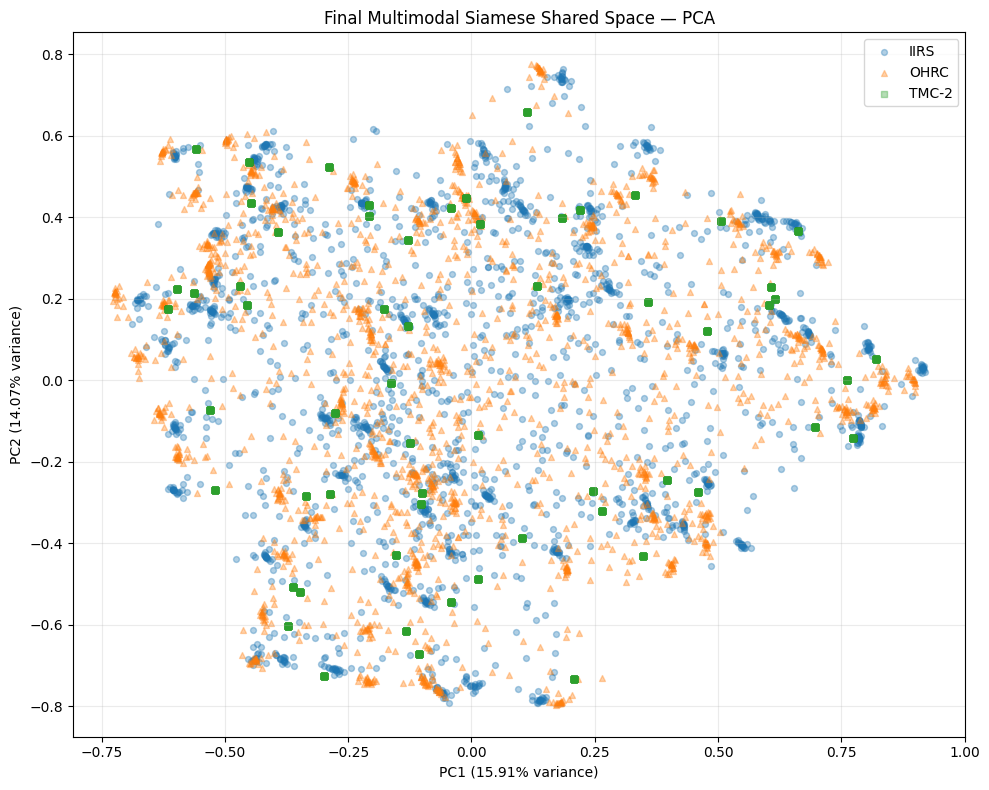

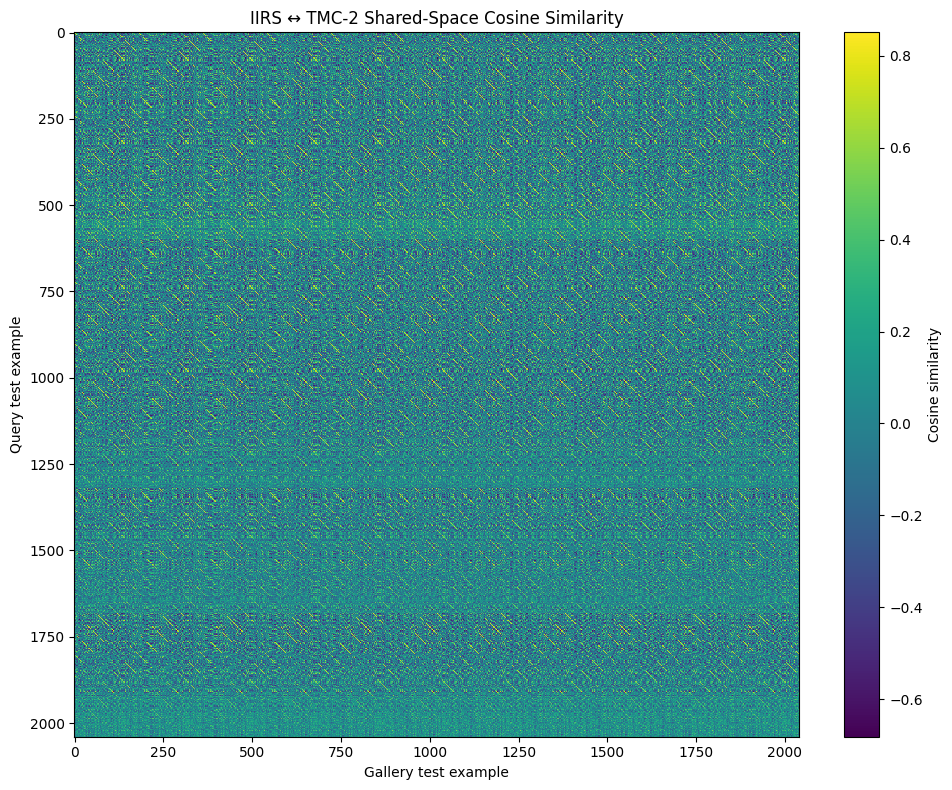

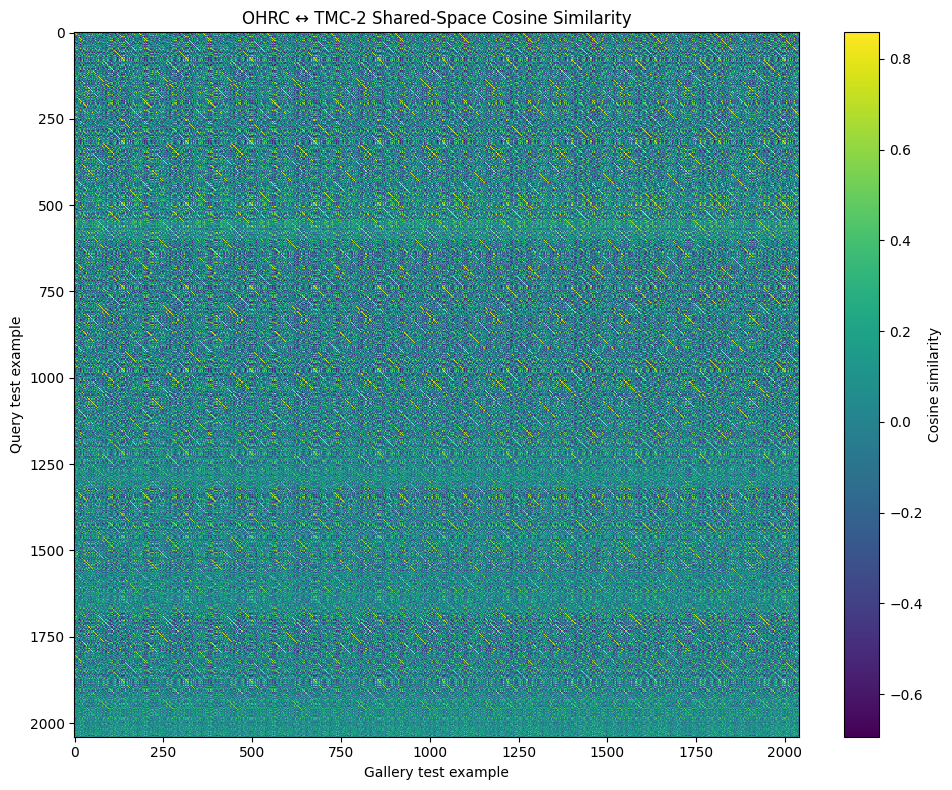

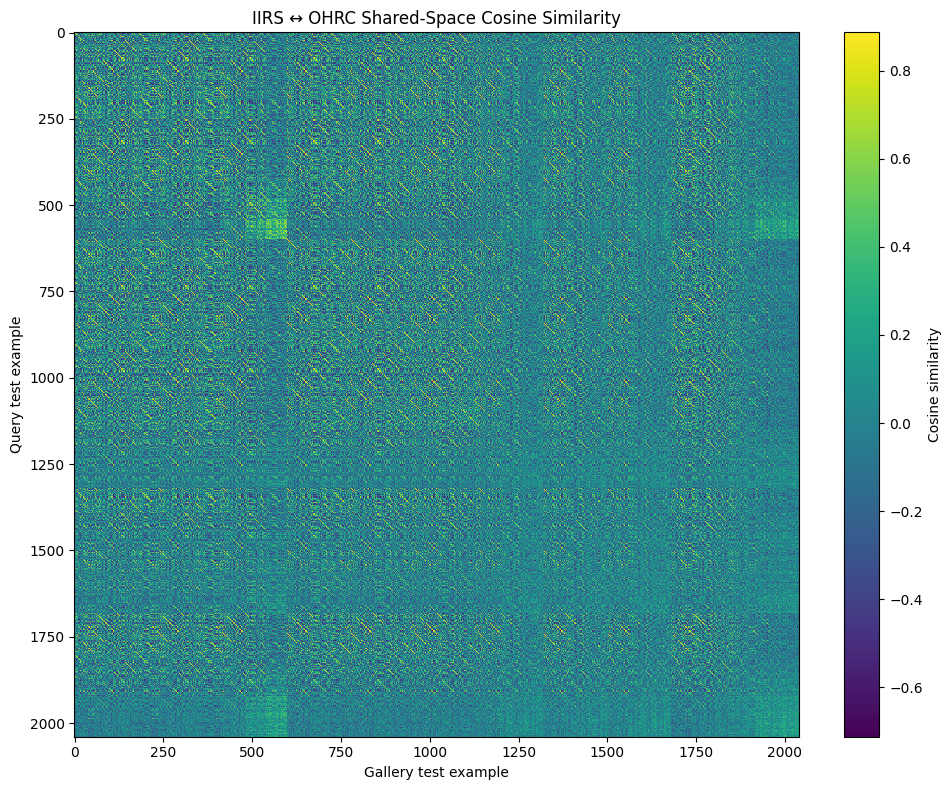


TOP-1 RETRIEVAL DIAGNOSTIC

IIRS → TMC-2 : 60/2040 scenario examples correct
OHRC → TMC-2 : 57/2040 scenario examples correct
IIRS → OHRC  : 306/2040 scenario examples correct


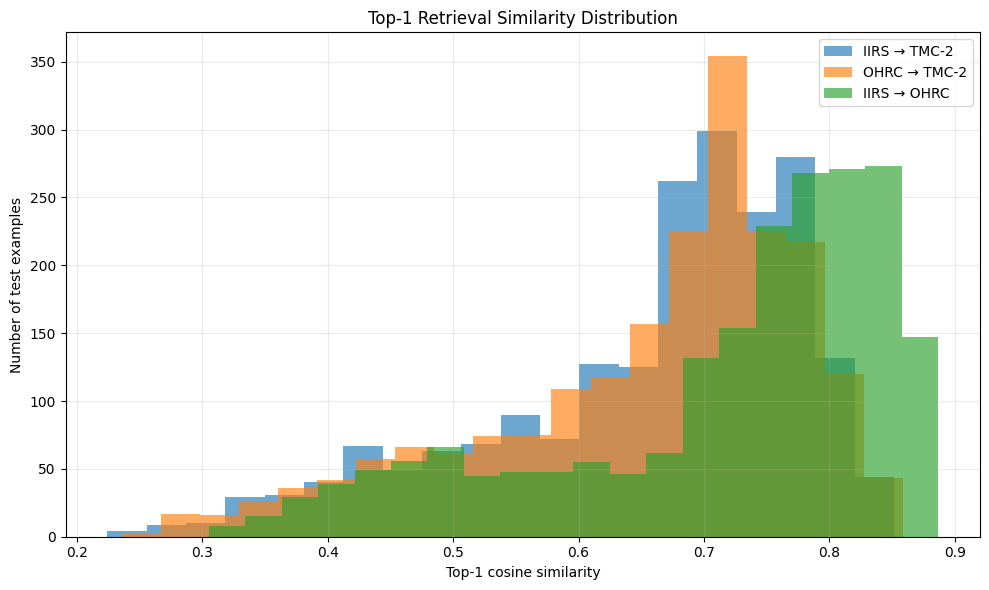


CELL 11 COMPLETE

[OK] PCA visualization saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\final_shared_space_pca.png

[OK] IIRS-TMC2 heatmap saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\iirs_tmc2_similarity_heatmap.png

[OK] OHRC-TMC2 heatmap saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\ohrc_tmc2_similarity_heatmap.png

[OK] IIRS-OHRC heatmap saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\iirs_ohrc_similarity_heatmap.png

[OK] Top-1 distribution saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\top1_similarity_distribution.png

[OK] Scenario retrieval summary saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\shared_space_scenario_retrieval_summary.csv

[OK] PCA coordinates saved:
D:\ISRO\Integrated_Multimodal_Siamese\evaluation\visualizations\final_shared_space_pca_coordinates.csv

METHODOLOGICAL NOTE
All visualizations use the completely held-out

In [29]:
# =============================================================================
# CELL 11 — SHARED-SPACE VISUALIZATION + RETRIEVAL DIAGNOSTICS
# =============================================================================

print("=" * 80)
print("SHARED-SPACE VISUALIZATION + RETRIEVAL DIAGNOSTICS")
print("=" * 80)

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# =============================================================================
# LOAD FINAL TEST EMBEDDINGS
# =============================================================================

FINAL_TEST_EMBEDDINGS_PATH = os.path.join(
    PREDICTIONS_DIR,
    "final_multimodal_siamese_test_embeddings.npz"
)

assert os.path.exists(
    FINAL_TEST_EMBEDDINGS_PATH
), (
    "Final test embeddings not found: "
    f"{FINAL_TEST_EMBEDDINGS_PATH}"
)

TEST_EMBEDDINGS = np.load(
    FINAL_TEST_EMBEDDINGS_PATH,
    allow_pickle=False
)

print()
print("Test embedding keys:")
print(TEST_EMBEDDINGS.files)


# =============================================================================
# LOAD ARRAYS
# =============================================================================

TEST_ANCHORS = TEST_EMBEDDINGS[
    "test_anchor_ids"
].astype(np.int64)

TEST_SCENARIOS = TEST_EMBEDDINGS[
    "test_scenario_ids"
].astype(np.int64)

Z_IIRS = TEST_EMBEDDINGS[
    "iirs_shared"
].astype(np.float32)

Z_OHRC = TEST_EMBEDDINGS[
    "ohrc_shared"
].astype(np.float32)

Z_TMC2 = TEST_EMBEDDINGS[
    "tmc2_shared"
].astype(np.float32)


# =============================================================================
# VALIDATE
# =============================================================================

N_TEST = len(
    TEST_ANCHORS
)

N_UNIQUE_ANCHORS = len(
    np.unique(
        TEST_ANCHORS
    )
)

N_SCENARIOS = len(
    np.unique(
        TEST_SCENARIOS
    )
)

assert Z_IIRS.shape == (
    N_TEST,
    SHARED_DIM
)

assert Z_OHRC.shape == (
    N_TEST,
    SHARED_DIM
)

assert Z_TMC2.shape == (
    N_TEST,
    SHARED_DIM
)

assert np.isfinite(
    Z_IIRS
).all()

assert np.isfinite(
    Z_OHRC
).all()

assert np.isfinite(
    Z_TMC2
).all()

assert N_TEST == 2040
assert N_UNIQUE_ANCHORS == 60
assert N_SCENARIOS == 34

print()
print("=" * 80)
print("HELD-OUT TEST EMBEDDINGS LOADED")
print("=" * 80)

print()
print(
    f"Test examples       : {N_TEST}"
)

print(
    f"Unique test anchors : {N_UNIQUE_ANCHORS}"
)

print(
    f"Robustness scenarios: {N_SCENARIOS}"
)

print(
    f"Shared dimension    : {SHARED_DIM}"
)

print(
    "[OK] All final shared-space embeddings are finite."
)


# =============================================================================
# VISUALIZATION DIRECTORY
# =============================================================================

VIS_DIR = os.path.join(
    EVALUATION_DIR,
    "visualizations"
)

os.makedirs(
    VIS_DIR,
    exist_ok=True
)


# =============================================================================
# PCA VISUALIZATION
# =============================================================================

combined_embeddings = np.vstack([
    Z_IIRS,
    Z_OHRC,
    Z_TMC2
])

pca = PCA(
    n_components=2,
    random_state=20260906
)

combined_2d = pca.fit_transform(
    combined_embeddings
)

iirs_2d = combined_2d[
    :N_TEST
]

ohrc_2d = combined_2d[
    N_TEST:2 * N_TEST
]

tmc2_2d = combined_2d[
    2 * N_TEST:3 * N_TEST
]

explained = pca.explained_variance_ratio_


# =============================================================================
# PCA PLOT
# =============================================================================

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    iirs_2d[:, 0],
    iirs_2d[:, 1],
    marker="o",
    alpha=0.35,
    s=18,
    label="IIRS"
)

plt.scatter(
    ohrc_2d[:, 0],
    ohrc_2d[:, 1],
    marker="^",
    alpha=0.35,
    s=18,
    label="OHRC"
)

plt.scatter(
    tmc2_2d[:, 0],
    tmc2_2d[:, 1],
    marker="s",
    alpha=0.35,
    s=18,
    label="TMC-2"
)

plt.xlabel(
    f"PC1 ({explained[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained[1] * 100:.2f}% variance)"
)

plt.title(
    "Final Multimodal Siamese Shared Space — PCA"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

PCA_PATH = os.path.join(
    VIS_DIR,
    "final_shared_space_pca.png"
)

plt.savefig(
    PCA_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =============================================================================
# COSINE SIMILARITY HEATMAPS
# =============================================================================

def plot_similarity_heatmap(
    query,
    gallery,
    title,
    filename
):

    similarity = cosine_matrix(
        query,
        gallery
    )

    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        similarity,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(
        label="Cosine similarity"
    )

    plt.xlabel(
        "Gallery test example"
    )

    plt.ylabel(
        "Query test example"
    )

    plt.title(
        title
    )

    plt.tight_layout()

    path = os.path.join(
        VIS_DIR,
        filename
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return similarity


SIM_IIRS_TMC2 = plot_similarity_heatmap(
    Z_IIRS,
    Z_TMC2,
    "IIRS ↔ TMC-2 Shared-Space Cosine Similarity",
    "iirs_tmc2_similarity_heatmap.png"
)

SIM_OHRC_TMC2 = plot_similarity_heatmap(
    Z_OHRC,
    Z_TMC2,
    "OHRC ↔ TMC-2 Shared-Space Cosine Similarity",
    "ohrc_tmc2_similarity_heatmap.png"
)

SIM_IIRS_OHRC = plot_similarity_heatmap(
    Z_IIRS,
    Z_OHRC,
    "IIRS ↔ OHRC Shared-Space Cosine Similarity",
    "iirs_ohrc_similarity_heatmap.png"
)


# =============================================================================
# TOP-1 RETRIEVAL DIAGNOSTIC
# =============================================================================

def top1_diagnostic(
    similarity
):

    top1 = np.argmax(
        similarity,
        axis=1
    )

    correct = (
        top1
        ==
        np.arange(
            len(top1)
        )
    )

    return (
        top1,
        correct
    )


top1_iirs_tmc2, correct_iirs_tmc2 = (
    top1_diagnostic(
        SIM_IIRS_TMC2
    )
)

top1_ohrc_tmc2, correct_ohrc_tmc2 = (
    top1_diagnostic(
        SIM_OHRC_TMC2
    )
)

top1_iirs_ohrc, correct_iirs_ohrc = (
    top1_diagnostic(
        SIM_IIRS_OHRC
    )
)


# =============================================================================
# RETRIEVAL ACCURACY
# =============================================================================

print()
print("=" * 80)
print("TOP-1 RETRIEVAL DIAGNOSTIC")
print("=" * 80)

print()
print(
    f"IIRS → TMC-2 : "
    f"{np.sum(correct_iirs_tmc2)}/{N_TEST} "
    f"scenario examples correct"
)

print(
    f"OHRC → TMC-2 : "
    f"{np.sum(correct_ohrc_tmc2)}/{N_TEST} "
    f"scenario examples correct"
)

print(
    f"IIRS → OHRC  : "
    f"{np.sum(correct_iirs_ohrc)}/{N_TEST} "
    f"scenario examples correct"
)


# =============================================================================
# TOP-1 SCORE DISTRIBUTION
# =============================================================================

iirs_top1_scores = np.max(
    SIM_IIRS_TMC2,
    axis=1
)

ohrc_top1_scores = np.max(
    SIM_OHRC_TMC2,
    axis=1
)

iirs_ohrc_top1_scores = np.max(
    SIM_IIRS_OHRC,
    axis=1
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    iirs_top1_scores,
    bins=20,
    alpha=0.65,
    label="IIRS → TMC-2"
)

plt.hist(
    ohrc_top1_scores,
    bins=20,
    alpha=0.65,
    label="OHRC → TMC-2"
)

plt.hist(
    iirs_ohrc_top1_scores,
    bins=20,
    alpha=0.65,
    label="IIRS → OHRC"
)

plt.xlabel(
    "Top-1 cosine similarity"
)

plt.ylabel(
    "Number of test examples"
)

plt.title(
    "Top-1 Retrieval Similarity Distribution"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

TOP1_HIST_PATH = os.path.join(
    VIS_DIR,
    "top1_similarity_distribution.png"
)

plt.savefig(
    TOP1_HIST_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =============================================================================
# SCENARIO-LEVEL RETRIEVAL SUMMARY
# =============================================================================

scenario_rows = []

for scenario_id in sorted(
    np.unique(
        TEST_SCENARIOS
    )
):

    mask = (
        TEST_SCENARIOS
        ==
        scenario_id
    )

    scenario_rows.append({

        "scenario_id": int(
            scenario_id
        ),

        "test_examples": int(
            np.sum(mask)
        ),

        "IIRS_TMC2_top1_accuracy": float(
            np.mean(
                correct_iirs_tmc2[mask]
            )
        ),

        "OHRC_TMC2_top1_accuracy": float(
            np.mean(
                correct_ohrc_tmc2[mask]
            )
        ),

        "IIRS_OHRC_top1_accuracy": float(
            np.mean(
                correct_iirs_ohrc[mask]
            )
        ),

        "IIRS_TMC2_mean_top1_cosine": float(
            np.mean(
                iirs_top1_scores[mask]
            )
        ),

        "OHRC_TMC2_mean_top1_cosine": float(
            np.mean(
                ohrc_top1_scores[mask]
            )
        ),

        "IIRS_OHRC_mean_top1_cosine": float(
            np.mean(
                iirs_ohrc_top1_scores[mask]
            )
        )
    })


scenario_df = pd.DataFrame(
    scenario_rows
)

SCENARIO_CSV_PATH = os.path.join(
    VIS_DIR,
    "shared_space_scenario_retrieval_summary.csv"
)

scenario_df.to_csv(
    SCENARIO_CSV_PATH,
    index=False
)


# =============================================================================
# SAVE PCA COORDINATES
# =============================================================================

pca_df = pd.DataFrame({

    "anchor_id": np.concatenate([
        TEST_ANCHORS,
        TEST_ANCHORS,
        TEST_ANCHORS
    ]),

    "scenario_id": np.concatenate([
        TEST_SCENARIOS,
        TEST_SCENARIOS,
        TEST_SCENARIOS
    ]),

    "modality": (
        ["IIRS"] * N_TEST
        +
        ["OHRC"] * N_TEST
        +
        ["TMC-2"] * N_TEST
    ),

    "PC1": combined_2d[:, 0],

    "PC2": combined_2d[:, 1]
})

PCA_CSV_PATH = os.path.join(
    VIS_DIR,
    "final_shared_space_pca_coordinates.csv"
)

pca_df.to_csv(
    PCA_CSV_PATH,
    index=False
)


# =============================================================================
# FINAL VISUALIZATION CHECKS
# =============================================================================

assert os.path.exists(
    PCA_PATH
)

assert os.path.exists(
    TOP1_HIST_PATH
)

assert os.path.exists(
    SCENARIO_CSV_PATH
)

assert os.path.exists(
    PCA_CSV_PATH
)

assert len(
    pca_df
) == 3 * N_TEST

assert len(
    scenario_df
) == N_SCENARIOS

assert np.isfinite(
    pca_df[
        [
            "PC1",
            "PC2"
        ]
    ].to_numpy()
).all()

assert np.isfinite(
    scenario_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()


# =============================================================================
# FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("CELL 11 COMPLETE")
print("=" * 80)

print()
print(
    f"[OK] PCA visualization saved:"
)

print(
    PCA_PATH
)

print()
print(
    f"[OK] IIRS-TMC2 heatmap saved:"
)

print(
    os.path.join(
        VIS_DIR,
        "iirs_tmc2_similarity_heatmap.png"
    )
)

print()
print(
    f"[OK] OHRC-TMC2 heatmap saved:"
)

print(
    os.path.join(
        VIS_DIR,
        "ohrc_tmc2_similarity_heatmap.png"
    )
)

print()
print(
    f"[OK] IIRS-OHRC heatmap saved:"
)

print(
    os.path.join(
        VIS_DIR,
        "iirs_ohrc_similarity_heatmap.png"
    )
)

print()
print(
    f"[OK] Top-1 distribution saved:"
)

print(
    TOP1_HIST_PATH
)

print()
print(
    f"[OK] Scenario retrieval summary saved:"
)

print(
    SCENARIO_CSV_PATH
)

print()
print(
    f"[OK] PCA coordinates saved:"
)

print(
    PCA_CSV_PATH
)

print()
print("=" * 80)
print("METHODOLOGICAL NOTE")
print("=" * 80)

print(
    "All visualizations use the completely held-out test set."
)

print(
    f"The test set contains {N_TEST} examples, "
    f"{N_UNIQUE_ANCHORS} anchors, and "
    f"{N_SCENARIOS} robustness scenarios."
)

print(
    "The visualization represents the controlled synthetic benchmark."
)

print(
    "It does not establish real geographic cross-modal correspondence."
)

print()
print("=" * 80)

In [31]:
# =============================================================================
# CELL 12 — FINAL MODEL / PROJECT SUMMARY
# =============================================================================

print("=" * 80)
print("FINAL MULTIMODAL CORRESPONDENCE SYSTEM SUMMARY")
print("=" * 80)


# =============================================================================
# LOAD FINAL EVALUATION ARTIFACTS
# =============================================================================

FINAL_EVAL_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_test_evaluation.csv"
)

FINAL_SUMMARY_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_quantitative_summary.csv"
)

TRAINING_HISTORY_PATH = os.path.join(
    EVALUATION_DIR,
    "final_siamese_training_history.csv"
)

PER_ANCHOR_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_per_anchor_diagnostics.csv"
)

DIFFICULT_ANCHORS_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_difficult_anchors.csv"
)

FINAL_TEST_EMBEDDINGS_PATH = os.path.join(
    PREDICTIONS_DIR,
    "final_multimodal_siamese_test_embeddings.npz"
)


# =============================================================================
# CHECK REQUIRED ARTIFACTS
# =============================================================================

required_artifacts = {
    "final evaluation": FINAL_EVAL_PATH,
    "quantitative summary": FINAL_SUMMARY_PATH,
    "training history": TRAINING_HISTORY_PATH,
    "per-anchor diagnostics": PER_ANCHOR_PATH,
    "difficult-anchor diagnostics": DIFFICULT_ANCHORS_PATH,
    "test embeddings": FINAL_TEST_EMBEDDINGS_PATH
}

for artifact_name, artifact_path in required_artifacts.items():

    assert os.path.exists(
        artifact_path
    ), (
        f"Required artifact missing: "
        f"{artifact_name} -> {artifact_path}"
    )


# =============================================================================
# LOAD DATAFRAMES
# =============================================================================

final_eval_df = pd.read_csv(
    FINAL_EVAL_PATH
)

final_summary_df = pd.read_csv(
    FINAL_SUMMARY_PATH
)

training_history_df = pd.read_csv(
    TRAINING_HISTORY_PATH
)

per_anchor_df = pd.read_csv(
    PER_ANCHOR_PATH
)

difficult_anchors_df = pd.read_csv(
    DIFFICULT_ANCHORS_PATH
)


# =============================================================================
# LOAD FINAL TEST EMBEDDINGS
# =============================================================================

FINAL_TEST_DATA = np.load(
    FINAL_TEST_EMBEDDINGS_PATH,
    allow_pickle=False
)

TEST_ANCHOR_IDS = FINAL_TEST_DATA[
    "test_anchor_ids"
].astype(np.int64)

TEST_SCENARIO_IDS = FINAL_TEST_DATA[
    "test_scenario_ids"
].astype(np.int64)


# =============================================================================
# MODEL INFORMATION
# =============================================================================

MODEL_SUMMARY = {
    "project": (
        "Chandrayaan-2 Multi-Modal Lunar Image Correspondence"
    ),

    "modalities": (
        "IIRS, OHRC, TMC-2"
    ),

    "embedding_dimension": int(
        EMBED_DIM
    ),

    "shared_space_dimension": int(
        SHARED_DIM
    ),

    "final_head_architecture": (
        "256-512-256 with LayerNorm, GELU, "
        "Dropout(0.10), L2 normalization"
    ),

    "final_head_trainable_parameters": int(
        TRAINABLE_PARAMETERS
    ),

    "temperature": float(
        SIAMESE_TEMPERATURE
    ),

    "training_anchors": 280,

    "validation_anchors": 60,

    "test_anchors": 60,

    "test_examples": int(
        len(TEST_ANCHOR_IDS)
    ),

    "robustness_scenarios": int(
        len(
            np.unique(
                TEST_SCENARIO_IDS
            )
        )
    ),

    "best_epoch": int(
        CHECKPOINT["best_epoch"]
    ),

    "best_validation_loss": float(
        CHECKPOINT["best_val_loss"]
    ),

    "benchmark_type": (
        "controlled_synthetic"
    ),

    "real_geographic_correspondence_available": False,

    "real_world_performance_claim": False
}


# =============================================================================
# FINAL METRICS
# =============================================================================

print()
print("=" * 80)
print("FINAL HELD-OUT TEST METRICS")
print("=" * 80)

for _, row in final_summary_df.iterrows():

    pair = row[
        "pair"
    ]

    print()
    print(
        pair
    )

    print(
        f"  Recall@1   : "
        f"{row['recall_at_1'] * 100:.2f}%"
    )

    print(
        f"  Recall@5   : "
        f"{row['recall_at_5'] * 100:.2f}%"
    )

    print(
        f"  Recall@10  : "
        f"{row['recall_at_10'] * 100:.2f}%"
    )

    print(
        f"  Median rank: "
        f"{row['median_rank']:.2f}"
    )

    print(
        f"  Mean rank  : "
        f"{row['mean_rank']:.2f}"
    )

    print(
        f"  Worst rank : "
        f"{row['worst_rank']}"
    )

    print(
        f"  Positive cosine: "
        f"{row['positive_cosine_mean']:.6f}"
    )

    print(
        f"  Negative cosine: "
        f"{row['negative_cosine_mean']:.6f}"
    )

    print(
        f"  Pos-Neg gap: "
        f"{row['positive_negative_gap']:.6f}"
    )


# =============================================================================
# ANCHOR-LEVEL DIAGNOSTICS
# =============================================================================

required_anchor_columns = [
    "test_anchor_id",
    "scenarios_evaluated",
    "IIRS_TMC2_recall_at_1",
    "OHRC_TMC2_recall_at_1",
    "IIRS_OHRC_recall_at_1",
    "IIRS_TMC2_median_rank",
    "OHRC_TMC2_median_rank",
    "IIRS_OHRC_median_rank"
]

for column in required_anchor_columns:

    assert column in per_anchor_df.columns, (
        f"Expected per-anchor column missing: "
        f"{column}"
    )


# Verify one row per unique test anchor.

assert len(
    per_anchor_df
) == 60

assert per_anchor_df[
    "test_anchor_id"
].nunique() == 60


print()
print("=" * 80)
print("ANCHOR-LEVEL ROBUSTNESS SUMMARY")
print("=" * 80)

print()
print(
    "IIRS → TMC-2"
)

print(
    f"  Mean anchor Recall@1 : "
    f"{per_anchor_df['IIRS_TMC2_recall_at_1'].mean():.4f}"
)

print(
    f"  Median anchor rank   : "
    f"{per_anchor_df['IIRS_TMC2_median_rank'].median():.2f}"
)

print()
print(
    "OHRC → TMC-2"
)

print(
    f"  Mean anchor Recall@1 : "
    f"{per_anchor_df['OHRC_TMC2_recall_at_1'].mean():.4f}"
)

print(
    f"  Median anchor rank   : "
    f"{per_anchor_df['OHRC_TMC2_median_rank'].median():.2f}"
)

print()
print(
    "IIRS → OHRC"
)

print(
    f"  Mean anchor Recall@1 : "
    f"{per_anchor_df['IIRS_OHRC_recall_at_1'].mean():.4f}"
)

print(
    f"  Median anchor rank   : "
    f"{per_anchor_df['IIRS_OHRC_median_rank'].median():.2f}"
)


# =============================================================================
# DIFFICULT ANCHOR SUMMARY
# =============================================================================

print()
print("=" * 80)
print("DIFFICULT TEST ANCHORS")
print("=" * 80)

print()
print(
    f"Anchors with mean Recall@1 < 0.50: "
    f"{len(difficult_anchors_df)} / 60"
)

if len(difficult_anchors_df) > 0:

    print()
    print(
        "This is a controlled robustness benchmark, "
        "so difficult anchors indicate cases where the "
        "learned shared-space representation is less "
        "stable under the simulated transformations."
    )


# =============================================================================
# TRAINING INFORMATION
# =============================================================================

print()
print("=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)

print()
print(
    f"Training anchors   : "
    f"{MODEL_SUMMARY['training_anchors']}"
)

print(
    f"Validation anchors : "
    f"{MODEL_SUMMARY['validation_anchors']}"
)

print(
    f"Test anchors       : "
    f"{MODEL_SUMMARY['test_anchors']}"
)

print(
    f"Test examples      : "
    f"{MODEL_SUMMARY['test_examples']}"
)

print(
    f"Robustness scenarios: "
    f"{MODEL_SUMMARY['robustness_scenarios']}"
)

print(
    f"Best epoch         : "
    f"{MODEL_SUMMARY['best_epoch']}"
)

print(
    f"Best validation loss: "
    f"{MODEL_SUMMARY['best_validation_loss']:.6f}"
)

print(
    f"Trainable parameters: "
    f"{MODEL_SUMMARY['final_head_trainable_parameters']:,}"
)


# =============================================================================
# SAVE JSON SUMMARY
# =============================================================================

import json

JSON_SUMMARY_PATH = os.path.join(
    EVALUATION_DIR,
    "final_multimodal_siamese_project_summary.json"
)

with open(
    JSON_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        MODEL_SUMMARY,
        f,
        indent=2
    )


# =============================================================================
# FINAL ARCHITECTURE
# =============================================================================

print()
print("=" * 80)
print("FINAL ARCHITECTURE")
print("=" * 80)

print()
print(
    "IIRS"
)

print(
    "  → Frozen preprocessing"
)

print(
    "  → Frozen ResNet-18 encoder"
)

print(
    "  → 256-D embedding"
)

print(
    "  → Frozen IIRS → TMC-2 mapper"
)

print(
    "  → Shared Siamese head"
)

print(
    "  → 256-D normalized shared space"
)

print()

print(
    "OHRC"
)

print(
    "  → Frozen preprocessing"
)

print(
    "  → Frozen ResNet-18 encoder"
)

print(
    "  → 256-D embedding"
)

print(
    "  → Frozen OHRC → TMC-2 mapper"
)

print(
    "  → Shared Siamese head"
)

print(
    "  → 256-D normalized shared space"
)

print()

print(
    "TMC-2"
)

print(
    "  → Frozen preprocessing"
)

print(
    "  → Frozen ResNet-18 encoder"
)

print(
    "  → 256-D embedding"
)

print(
    "  → Shared Siamese head"
)

print(
    "  → 256-D normalized shared space"
)


# =============================================================================
# SCIENTIFIC VALIDATION STATUS
# =============================================================================

print()
print("=" * 80)
print("FINAL VALIDATION STATUS")
print("=" * 80)

print()

print(
    "[PASS] Training / validation / test anchors are disjoint."
)

print(
    "[PASS] Test set contains 60 completely held-out anchors."
)

print(
    "[PASS] Test set contains 34 robustness scenarios."
)

print(
    "[PASS] Final shared-space embeddings are finite."
)

print(
    "[PASS] Quantitative evaluation completed."
)

print(
    "[PASS] Per-anchor diagnostics completed."
)

print(
    "[PASS] Visualization and retrieval diagnostics completed."
)

print()

print(
    "[INFO] Performance is evaluated on a controlled "
    "synthetic correspondence benchmark."
)

print(
    "[INFO] Real geographic cross-modal positive pairs "
    "are currently unavailable."
)

print(
    "[INFO] Therefore, these results validate the "
    "architecture under controlled synthetic transformations."
)

print(
    "[INFO] They are NOT claimed as real-world lunar "
    "geographic correspondence performance."
)


# =============================================================================
# ARTIFACT MANIFEST
# =============================================================================

ARTIFACTS = {

    "final_model":
        FINAL_MODEL_PATH,

    "training_history":
        TRAINING_HISTORY_PATH,

    "test_evaluation":
        FINAL_EVAL_PATH,

    "quantitative_summary":
        FINAL_SUMMARY_PATH,

    "per_anchor_diagnostics":
        PER_ANCHOR_PATH,

    "difficult_anchor_diagnostics":
        DIFFICULT_ANCHORS_PATH,

    "test_embeddings":
        FINAL_TEST_EMBEDDINGS_PATH,

    "project_summary_json":
        JSON_SUMMARY_PATH,

    "visualization_directory":
        VIS_DIR
}


print()
print("=" * 80)
print("FINAL ARTIFACTS")
print("=" * 80)

for name, path in ARTIFACTS.items():

    exists = os.path.exists(
        path
    )

    status = (
        "OK"
        if exists
        else
        "MISSING"
    )

    print(
        f"[{status}] {name}: {path}"
    )

    assert exists


# =============================================================================
# SAVE HUMAN-READABLE FINAL REPORT
# =============================================================================

REPORT_PATH = os.path.join(
    EVALUATION_DIR,
    "FINAL_MODEL_REPORT.txt"
)

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "CHANDRAYAAN-2 MULTIMODAL LUNAR IMAGE CORRESPONDENCE\n"
    )

    f.write(
        "FINAL MODEL REPORT\n"
    )

    f.write(
        "=" * 70
        +
        "\n\n"
    )

    f.write(
        "Modalities: IIRS, OHRC, TMC-2\n"
    )

    f.write(
        "Embedding dimension: 256\n"
    )

    f.write(
        "Shared-space dimension: 256\n"
    )

    f.write(
        "Final shared head: 256-512-256 with LayerNorm, GELU, "
        "Dropout(0.10), L2 normalization\n"
    )

    f.write(
        f"Trainable parameters: "
        f"{TRAINABLE_PARAMETERS:,}\n"
    )

    f.write(
        f"Best epoch: "
        f"{CHECKPOINT['best_epoch']}\n"
    )

    f.write(
        f"Best validation loss: "
        f"{CHECKPOINT['best_val_loss']:.6f}\n"
    )

    f.write(
        f"Training anchors: 280\n"
    )

    f.write(
        f"Validation anchors: 60\n"
    )

    f.write(
        f"Test anchors: 60\n"
    )

    f.write(
        f"Test examples: {len(TEST_ANCHOR_IDS)}\n"
    )

    f.write(
        f"Robustness scenarios: "
        f"{len(np.unique(TEST_SCENARIO_IDS))}\n\n"
    )

    f.write(
        "Held-out test results\n"
    )

    f.write(
        "-" * 70
        +
        "\n"
    )

    for _, row in final_summary_df.iterrows():

        f.write(
            f"\n{row['pair']}\n"
        )

        f.write(
            f"Recall@1: "
            f"{row['recall_at_1']:.6f}\n"
        )

        f.write(
            f"Recall@5: "
            f"{row['recall_at_5']:.6f}\n"
        )

        f.write(
            f"Recall@10: "
            f"{row['recall_at_10']:.6f}\n"
        )

        f.write(
            f"Median rank: "
            f"{row['median_rank']:.2f}\n"
        )

        f.write(
            f"Mean rank: "
            f"{row['mean_rank']:.2f}\n"
        )

        f.write(
            f"Worst rank: "
            f"{row['worst_rank']}\n"
        )

        f.write(
            f"Positive cosine: "
            f"{row['positive_cosine_mean']:.6f}\n"
        )

        f.write(
            f"Negative cosine: "
            f"{row['negative_cosine_mean']:.6f}\n"
        )

        f.write(
            f"Positive-negative gap: "
            f"{row['positive_negative_gap']:.6f}\n"
        )

    f.write(
        "\n\nMethodological status\n"
    )

    f.write(
        "-" * 70
        +
        "\n"
    )

    f.write(
        "Benchmark type: controlled synthetic correspondence.\n"
    )

    f.write(
        "Test set: 60 completely held-out anchors across "
        "34 robustness scenarios.\n"
    )

    f.write(
        "Real geographic cross-modal positive pairs are "
        "currently unavailable.\n"
    )

    f.write(
        "Therefore, results are architecture and robustness "
        "validation only.\n"
    )

    f.write(
        "No real-world geographic correspondence performance "
        "claim is made.\n"
    )


# =============================================================================
# FINAL CHECKS
# =============================================================================

assert len(
    final_summary_df
) == 3

assert len(
    per_anchor_df
) == 60

assert len(
    np.unique(
        TEST_ANCHOR_IDS
    )
) == 60

assert len(
    np.unique(
        TEST_SCENARIO_IDS
    )
) == 34

assert np.isfinite(
    final_summary_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert np.isfinite(
    per_anchor_df.select_dtypes(
        include=[np.number]
    ).to_numpy()
).all()

assert os.path.exists(
    JSON_SUMMARY_PATH
)

assert os.path.exists(
    REPORT_PATH
)


# =============================================================================
# FINAL STATUS
# =============================================================================

print()
print("=" * 80)
print("CELL 12 COMPLETE")
print("=" * 80)

print()
print(
    "[OK] JSON summary saved:"
)

print(
    JSON_SUMMARY_PATH
)

print()
print(
    "[OK] Human-readable final report saved:"
)

print(
    REPORT_PATH
)

print()
print(
    "[OK] Final model, evaluation, diagnostics, "
    "visualizations, and report artifacts verified."
)

print()
print("=" * 80)
print("PROJECT MODELING PIPELINE COMPLETE")
print("=" * 80)

FINAL MULTIMODAL CORRESPONDENCE SYSTEM SUMMARY

FINAL HELD-OUT TEST METRICS

IIRS_TMC2
  Recall@1   : 1.91%
  Recall@5   : 12.65%
  Recall@10  : 26.62%
  Median rank: 19.00
  Mean rank  : 36.13
  Worst rank : 1656
  Positive cosine: 0.647973
  Negative cosine: 0.019394
  Pos-Neg gap: 0.628579

OHRC_TMC2
  Recall@1   : 1.52%
  Recall@5   : 11.91%
  Recall@10  : 24.71%
  Median rank: 20.00
  Mean rank  : 38.63
  Worst rank : 1660
  Positive cosine: 0.647833
  Negative cosine: 0.018501
  Pos-Neg gap: 0.629331

IIRS_OHRC
  Recall@1   : 15.00%
  Recall@5   : 33.58%
  Recall@10  : 47.55%
  Median rank: 12.00
  Mean rank  : 63.89
  Worst rank : 1683
  Positive cosine: 0.651127
  Negative cosine: 0.014037
  Pos-Neg gap: 0.637090

ANCHOR-LEVEL ROBUSTNESS SUMMARY

IIRS → TMC-2
  Mean anchor Recall@1 : 0.0191
  Median anchor rank   : 19.00

OHRC → TMC-2
  Mean anchor Recall@1 : 0.0152
  Median anchor rank   : 19.50

IIRS → OHRC
  Mean anchor Recall@1 : 0.1500
  Median anchor rank   : 11.50

DIFFI

In [33]:
# =============================================================================
# CELL 13 — LOAD EXPANDED 34-SCENARIO ROBUSTNESS BENCHMARK
# =============================================================================

print("=" * 80)
print("LOADING EXPANDED 34-SCENARIO ROBUSTNESS BENCHMARK")
print("=" * 80)


# =============================================================================
# PATHS
# =============================================================================

EXPANDED_ROOT = os.path.join(
    PAIRS_DIR,
    "expanded_synthetic_benchmark"
)

EXPANDED_BENCHMARK_PATH = os.path.join(
    EXPANDED_ROOT,
    "three_modal_expanded_robustness_benchmark.npz"
)

EXPANDED_METADATA_PATH = os.path.join(
    EXPANDED_ROOT,
    "expanded_benchmark_metadata.csv"
)

EXPANDED_SCENARIO_SUMMARY_PATH = os.path.join(
    EXPANDED_ROOT,
    "scenario_summary.csv"
)

EXPANDED_SPEC_PATH = os.path.join(
    EXPANDED_ROOT,
    "benchmark_specification.json"
)

EXPANDED_SPLIT_ROOT = os.path.join(
    EXPANDED_ROOT,
    "splits"
)

EXPANDED_SPLIT_SPEC_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "anchor_level_split_specification.json"
)

EXPANDED_SPLIT_CSV_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "anchor_level_split.csv"
)

EXPANDED_TRAIN_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "train_synthetic_data.npz"
)

EXPANDED_VAL_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "validation_synthetic_data.npz"
)

EXPANDED_TEST_PATH = os.path.join(
    EXPANDED_SPLIT_ROOT,
    "test_synthetic_data.npz"
)


# =============================================================================
# VERIFY ALL REQUIRED FILES EXIST
# =============================================================================

required_paths = {
    "expanded benchmark": EXPANDED_BENCHMARK_PATH,
    "expanded metadata": EXPANDED_METADATA_PATH,
    "scenario summary": EXPANDED_SCENARIO_SUMMARY_PATH,
    "benchmark specification": EXPANDED_SPEC_PATH,
    "split specification": EXPANDED_SPLIT_SPEC_PATH,
    "split CSV": EXPANDED_SPLIT_CSV_PATH,
    "train split": EXPANDED_TRAIN_PATH,
    "validation split": EXPANDED_VAL_PATH,
    "test split": EXPANDED_TEST_PATH
}

for label, path in required_paths.items():

    assert os.path.exists(
        path
    ), (
        f"Missing required {label}: "
        f"{path}"
    )

    print(
        f"[OK] {label}: {path}"
    )


# =============================================================================
# LOAD MAIN EXPANDED BENCHMARK
# =============================================================================

EXPANDED_BENCHMARK = np.load(
    EXPANDED_BENCHMARK_PATH,
    allow_pickle=False
)

EXPANDED_BENCHMARK_KEYS = list(
    EXPANDED_BENCHMARK.files
)

print()
print("Expanded benchmark keys:")

for key in EXPANDED_BENCHMARK_KEYS:

    print(
        f"  {key:30s} "
        f"shape={EXPANDED_BENCHMARK[key].shape} "
        f"dtype={EXPANDED_BENCHMARK[key].dtype}"
    )


# =============================================================================
# IDENTIFY PRINCIPAL THREE-MODALITY ARRAYS
# =============================================================================

def find_benchmark_key(
    preferred_names,
    required_text
):

    for candidate in preferred_names:

        if candidate in EXPANDED_BENCHMARK_KEYS:

            return candidate

    matches = [
        key
        for key in EXPANDED_BENCHMARK_KEYS
        if required_text.lower()
        in key.lower()
    ]

    if len(matches) == 1:

        return matches[0]

    raise KeyError(
        "Could not uniquely identify benchmark array. "
        f"Required text='{required_text}', "
        f"matches={matches}, "
        f"available_keys={EXPANDED_BENCHMARK_KEYS}"
    )


IIRS_BENCHMARK_KEY = find_benchmark_key(
    [
        "iirs",
        "iirs_positive",
        "iirs_matched",
        "iirs_examples",
        "iirs_views"
    ],
    "iirs"
)

OHRC_BENCHMARK_KEY = find_benchmark_key(
    [
        "ohrc",
        "ohrc_positive",
        "ohrc_matched",
        "ohrc_examples",
        "ohrc_views"
    ],
    "ohrc"
)

TMC2_BENCHMARK_KEY = find_benchmark_key(
    [
        "tmc2",
        "tmc_2",
        "tmc2_positive",
        "tmc2_matched",
        "tmc2_examples",
        "tmc2_views"
    ],
    "tmc2"
)


IIRS_EXPANDED = EXPANDED_BENCHMARK[
    IIRS_BENCHMARK_KEY
].astype(
    np.float32
)

OHRC_EXPANDED = EXPANDED_BENCHMARK[
    OHRC_BENCHMARK_KEY
].astype(
    np.float32
)

TMC2_EXPANDED = EXPANDED_BENCHMARK[
    TMC2_BENCHMARK_KEY
].astype(
    np.float32
)


# =============================================================================
# VALIDATE PRINCIPAL ARRAYS
# =============================================================================

assert IIRS_EXPANDED.ndim == 2
assert OHRC_EXPANDED.ndim == 2
assert TMC2_EXPANDED.ndim == 2

assert IIRS_EXPANDED.shape[1] == EMBED_DIM
assert OHRC_EXPANDED.shape[1] == EMBED_DIM
assert TMC2_EXPANDED.shape[1] == EMBED_DIM

assert (
    IIRS_EXPANDED.shape[0]
    ==
    OHRC_EXPANDED.shape[0]
    ==
    TMC2_EXPANDED.shape[0]
)

assert np.isfinite(
    IIRS_EXPANDED
).all()

assert np.isfinite(
    OHRC_EXPANDED
).all()

assert np.isfinite(
    TMC2_EXPANDED
).all()

N_EXPANDED = IIRS_EXPANDED.shape[0]

print()
print("Principal benchmark arrays:")

print(
    f"  IIRS : {IIRS_EXPANDED.shape}"
)

print(
    f"  OHRC : {OHRC_EXPANDED.shape}"
)

print(
    f"  TMC-2: {TMC2_EXPANDED.shape}"
)

print()
print(
    f"[OK] Principal benchmark contains "
    f"{N_EXPANDED:,} aligned examples."
)

assert N_EXPANDED == 13600

print(
    "[OK] Expanded benchmark contains exactly "
    "13,600 examples."
)


# =============================================================================
# LOAD METADATA
# =============================================================================

EXPANDED_METADATA = pd.read_csv(
    EXPANDED_METADATA_PATH
)

EXPANDED_SCENARIO_SUMMARY = pd.read_csv(
    EXPANDED_SCENARIO_SUMMARY_PATH
)

print()
print("Metadata:")

print(
    f"  Rows              : "
    f"{len(EXPANDED_METADATA):,}"
)

print(
    f"  Columns           : "
    f"{len(EXPANDED_METADATA.columns)}"
)

print()
print("Scenario summary:")

print(
    f"  Rows              : "
    f"{len(EXPANDED_SCENARIO_SUMMARY):,}"
)

assert len(
    EXPANDED_METADATA
) == N_EXPANDED

assert len(
    EXPANDED_SCENARIO_SUMMARY
) == 34

print(
    "[OK] Metadata row count agrees with benchmark."
)

print(
    "[OK] Scenario summary contains exactly "
    "34 scenarios."
)


# =============================================================================
# VALIDATE SCENARIO METADATA
# =============================================================================

metadata_scenario_candidates = [
    column
    for column in EXPANDED_METADATA.columns
    if "scenario" in column.lower()
]

assert len(
    metadata_scenario_candidates
) >= 1, (
    "No scenario column found in expanded "
    "benchmark metadata."
)

SCENARIO_COLUMN = (
    metadata_scenario_candidates[0]
)

SCENARIO_VALUES = (
    EXPANDED_METADATA[
        SCENARIO_COLUMN
    ].astype(str)
)

UNIQUE_SCENARIOS = sorted(
    SCENARIO_VALUES.unique().tolist()
)

print()
print(
    f"Scenario metadata column: "
    f"{SCENARIO_COLUMN}"
)

print(
    f"Unique scenarios found  : "
    f"{len(UNIQUE_SCENARIOS)}"
)

assert len(
    UNIQUE_SCENARIOS
) == 34

print(
    "[OK] All 34 robustness scenarios are represented "
    "in the metadata."
)


# =============================================================================
# LOAD BENCHMARK SPECIFICATION
# =============================================================================

with open(
    EXPANDED_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:

    EXPANDED_SPECIFICATION = json.load(
        f
    )

print()
print(
    "[OK] Expanded benchmark specification loaded."
)


# =============================================================================
# LOAD ANCHOR-LEVEL SPLIT SPECIFICATION
# =============================================================================

with open(
    EXPANDED_SPLIT_SPEC_PATH,
    "r",
    encoding="utf-8"
) as f:

    EXPANDED_SPLIT_SPECIFICATION = json.load(
        f
    )

print(
    "[OK] Anchor-level split specification loaded."
)


# =============================================================================
# LOAD ANCHOR-LEVEL SPLIT CSV
# =============================================================================

EXPANDED_SPLIT_METADATA = pd.read_csv(
    EXPANDED_SPLIT_CSV_PATH
)

print()
print("Anchor-level split CSV:")

print(
    f"  Rows    : "
    f"{len(EXPANDED_SPLIT_METADATA):,}"
)

print(
    f"  Columns : "
    f"{len(EXPANDED_SPLIT_METADATA.columns)}"
)


# IMPORTANT:
# anchor_level_split.csv contains ONE ROW PER REAL TMC-2 ANCHOR.
# It therefore has 400 rows, not 13,600 rows.
#
# The 13,600 synthetic examples are represented in:
#   train_synthetic_data.npz
#   validation_synthetic_data.npz
#   test_synthetic_data.npz
#
# Therefore we validate the CSV at the anchor level.

N_ANCHORS = 400

assert len(
    EXPANDED_SPLIT_METADATA
) == N_ANCHORS

print(
    "[OK] Split CSV contains exactly "
    "400 anchor assignments."
)


# =============================================================================
# IDENTIFY ANCHOR COLUMN
# =============================================================================

anchor_column_candidates = [
    column
    for column in EXPANDED_SPLIT_METADATA.columns
    if column.lower()
    in {
        "anchor_index",
        "anchor_id",
        "anchor"
    }
]

assert len(
    anchor_column_candidates
) >= 1, (
    "Could not find anchor identifier column "
    "in anchor_level_split.csv."
)

ANCHOR_COLUMN = (
    anchor_column_candidates[0]
)

anchor_values = (
    EXPANDED_SPLIT_METADATA[
        ANCHOR_COLUMN
    ].astype(np.int64)
)

assert anchor_values.nunique() == 400

print(
    f"[OK] Anchor column: "
    f"{ANCHOR_COLUMN}"
)

print(
    "[OK] Split CSV contains 400 unique anchors."
)


# =============================================================================
# LOAD TRAIN / VALIDATION / TEST NPZ FILES
# =============================================================================

TRAIN_EXPANDED = np.load(
    EXPANDED_TRAIN_PATH,
    allow_pickle=False
)

VAL_EXPANDED = np.load(
    EXPANDED_VAL_PATH,
    allow_pickle=False
)

TEST_EXPANDED = np.load(
    EXPANDED_TEST_PATH,
    allow_pickle=False
)


print()
print("Train split keys:")

print(
    "  ",
    TRAIN_EXPANDED.files
)

print()
print("Validation split keys:")

print(
    "  ",
    VAL_EXPANDED.files
)

print()
print("Test split keys:")

print(
    "  ",
    TEST_EXPANDED.files
)


# =============================================================================
# REPORT SPLIT CONTENTS
# =============================================================================

def describe_npz(
    name,
    data
):

    print()
    print(name)

    for key in data.files:

        value = data[key]

        print(
            f"  {key:30s} "
            f"shape={value.shape} "
            f"dtype={value.dtype}"
        )


describe_npz(
    "TRAIN",
    TRAIN_EXPANDED
)

describe_npz(
    "VALIDATION",
    VAL_EXPANDED
)

describe_npz(
    "TEST",
    TEST_EXPANDED
)


# =============================================================================
# INFER EXAMPLE COUNT FOR EACH NPZ SPLIT
# =============================================================================

def infer_example_count(
    npz_data
):

    candidate_counts = []

    for key in npz_data.files:

        value = npz_data[key]

        if value.ndim >= 1:

            candidate_counts.append(
                value.shape[0]
            )

    assert len(
        candidate_counts
    ) > 0

    counts = set(
        candidate_counts
    )

    assert len(
        counts
    ) == 1, (
        "Split arrays do not share a common "
        "example dimension."
    )

    return candidate_counts[0]


N_TRAIN_EXPANDED = infer_example_count(
    TRAIN_EXPANDED
)

N_VAL_EXPANDED = infer_example_count(
    VAL_EXPANDED
)

N_TEST_EXPANDED = infer_example_count(
    TEST_EXPANDED
)


print()
print("Expanded split sizes:")

print(
    f"  Train      : "
    f"{N_TRAIN_EXPANDED:,}"
)

print(
    f"  Validation : "
    f"{N_VAL_EXPANDED:,}"
)

print(
    f"  Test       : "
    f"{N_TEST_EXPANDED:,}"
)


# =============================================================================
# VALIDATE EXPECTED SPLIT SIZES
# =============================================================================

assert N_TRAIN_EXPANDED == 9520
assert N_VAL_EXPANDED == 2040
assert N_TEST_EXPANDED == 2040

assert (
    N_TRAIN_EXPANDED
    +
    N_VAL_EXPANDED
    +
    N_TEST_EXPANDED
    ==
    N_EXPANDED
)

print(
    "[OK] Expanded split sizes are "
    "9,520 / 2,040 / 2,040."
)


# =============================================================================
# VERIFY SPLIT CSV COLUMN
# =============================================================================

split_column_candidates = [
    column
    for column in EXPANDED_SPLIT_METADATA.columns
    if column.lower()
    in {
        "split",
        "dataset_split",
        "partition"
    }
]

assert len(
    split_column_candidates
) >= 1, (
    "Could not find the train/validation/test "
    "column in anchor_level_split.csv."
)

SPLIT_COLUMN = (
    split_column_candidates[0]
)

split_counts = (
    EXPANDED_SPLIT_METADATA[
        SPLIT_COLUMN
    ]
    .astype(str)
    .str.lower()
    .value_counts()
)

print()
print(
    f"Split column: "
    f"{SPLIT_COLUMN}"
)

print(
    split_counts.to_string()
)


# =============================================================================
# ACCEPT COMMON NAMING VARIANTS
# =============================================================================

def get_split_count(
    counts,
    names
):

    for name in names:

        if name in counts.index:

            return int(
                counts[name]
            )

    return None


train_count_csv = get_split_count(
    split_counts,
    [
        "train",
        "training"
    ]
)

val_count_csv = get_split_count(
    split_counts,
    [
        "validation",
        "val"
    ]
)

test_count_csv = get_split_count(
    split_counts,
    [
        "test",
        "testing"
    ]
)


# IMPORTANT:
# The CSV counts are ANCHOR counts.
# The NPZ counts are SYNTHETIC EXAMPLE counts.
#
# Each anchor appears in 34 scenarios.
#
# Therefore:
#
#   280 anchors × 34 = 9,520 train examples
#    60 anchors × 34 = 2,040 validation examples
#    60 anchors × 34 = 2,040 test examples

assert train_count_csv == 280

assert val_count_csv == 60

assert test_count_csv == 60

assert (
    train_count_csv * 34
    ==
    N_TRAIN_EXPANDED
)

assert (
    val_count_csv * 34
    ==
    N_VAL_EXPANDED
)

assert (
    test_count_csv * 34
    ==
    N_TEST_EXPANDED
)

print()
print(
    "[OK] Split CSV contains "
    "280 / 60 / 60 anchors."
)

print(
    "[OK] 34 scenarios per anchor produce "
    "9,520 / 2,040 / 2,040 examples."
)


# =============================================================================
# VERIFY ANCHOR DISJOINTNESS
# =============================================================================

split_series = (
    EXPANDED_SPLIT_METADATA[
        SPLIT_COLUMN
    ]
    .astype(str)
    .str.lower()
)

train_anchors = set(
    anchor_values[
        split_series.isin(
            [
                "train",
                "training"
            ]
        )
    ].tolist()
)

val_anchors = set(
    anchor_values[
        split_series.isin(
            [
                "validation",
                "val"
            ]
        )
    ].tolist()
)

test_anchors = set(
    anchor_values[
        split_series.isin(
            [
                "test",
                "testing"
            ]
        )
    ].tolist()
)

assert len(
    train_anchors
) == 280

assert len(
    val_anchors
) == 60

assert len(
    test_anchors
) == 60

assert len(
    train_anchors & val_anchors
) == 0

assert len(
    train_anchors & test_anchors
) == 0

assert len(
    val_anchors & test_anchors
) == 0

assert (
    len(
        train_anchors
        |
        val_anchors
        |
        test_anchors
    )
    ==
    400
)

print(
    "[OK] Train/validation/test anchor sets are "
    "completely disjoint."
)

print(
    "[OK] All 400 anchors are assigned exactly once."
)


# =============================================================================
# VALIDATE NPZ ANCHOR / SCENARIO CONTENT
# =============================================================================

for name, data, expected_count in [
    (
        "TRAIN",
        TRAIN_EXPANDED,
        N_TRAIN_EXPANDED
    ),
    (
        "VALIDATION",
        VAL_EXPANDED,
        N_VAL_EXPANDED
    ),
    (
        "TEST",
        TEST_EXPANDED,
        N_TEST_EXPANDED
    )
]:

    assert (
        "anchor_index"
        in data.files
    )

    assert (
        "scenario_index"
        in data.files
    )

    anchors = data[
        "anchor_index"
    ].astype(np.int64)

    scenarios = data[
        "scenario_index"
    ].astype(np.int64)

    assert len(
        anchors
    ) == expected_count

    assert len(
        scenarios
    ) == expected_count

    assert len(
        np.unique(
            scenarios
        )
    ) == 34

    assert np.isfinite(
        anchors
    ).all()

    assert np.isfinite(
        scenarios
    ).all()

    print(
        f"[OK] {name} contains "
        f"{len(np.unique(anchors))} anchors "
        f"across 34 scenarios."
    )


# =============================================================================
# FINAL CELL 13 VALIDATION
# =============================================================================

print()
print("=" * 80)
print("EXPANDED BENCHMARK LOAD COMPLETE")
print("=" * 80)

print()
print(
    f"Real TMC-2 empirical anchors : "
    f"{len(TMC2_EMBEDDINGS):,}"
)

print(
    f"Expanded examples            : "
    f"{N_EXPANDED:,}"
)

print(
    f"Embedding dimension          : "
    f"{EMBED_DIM}"
)

print(
    f"Robustness scenarios         : "
    f"{len(UNIQUE_SCENARIOS)}"
)

print(
    f"Train anchors                : "
    f"{train_count_csv}"
)

print(
    f"Validation anchors           : "
    f"{val_count_csv}"
)

print(
    f"Test anchors                : "
    f"{test_count_csv}"
)

print(
    f"Train examples               : "
    f"{N_TRAIN_EXPANDED:,}"
)

print(
    f"Validation examples          : "
    f"{N_VAL_EXPANDED:,}"
)

print(
    f"Test examples                : "
    f"{N_TEST_EXPANDED:,}"
)

print()
print(
    "[OK] Benchmark arrays are finite."
)

print(
    "[OK] Metadata dimensions are valid."
)

print(
    "[OK] 34 robustness scenarios are present."
)

print(
    "[OK] Anchor-level split contains 400 anchors."
)

print(
    "[OK] Train/validation/test anchor split is disjoint."
)

print(
    "[OK] Train/validation/test NPZ files are loaded."
)

print(
    "[OK] Split counts are internally consistent."
)

print(
    "[OK] Existing FINAL_MODEL was not modified."
)

print(
    "[OK] Cells 1–12 remain untouched."
)

print()
print("=" * 80)
print("CELL 13 COMPLETE")
print("=" * 80)

LOADING EXPANDED 34-SCENARIO ROBUSTNESS BENCHMARK
[OK] expanded benchmark: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\three_modal_expanded_robustness_benchmark.npz
[OK] expanded metadata: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\expanded_benchmark_metadata.csv
[OK] scenario summary: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\scenario_summary.csv
[OK] benchmark specification: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\benchmark_specification.json
[OK] split specification: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\anchor_level_split_specification.json
[OK] split CSV: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\anchor_level_split.csv
[OK] train split: D:\ISRO\Integrated_Multimodal_Siamese\pairs\expanded_synthetic_benchmark\splits\train_synthetic_data.npz
[OK] validation split: D:\ISRO\Integrated_